# Plot Results

# Coarse Labels

## Box Plot Overview

### ML

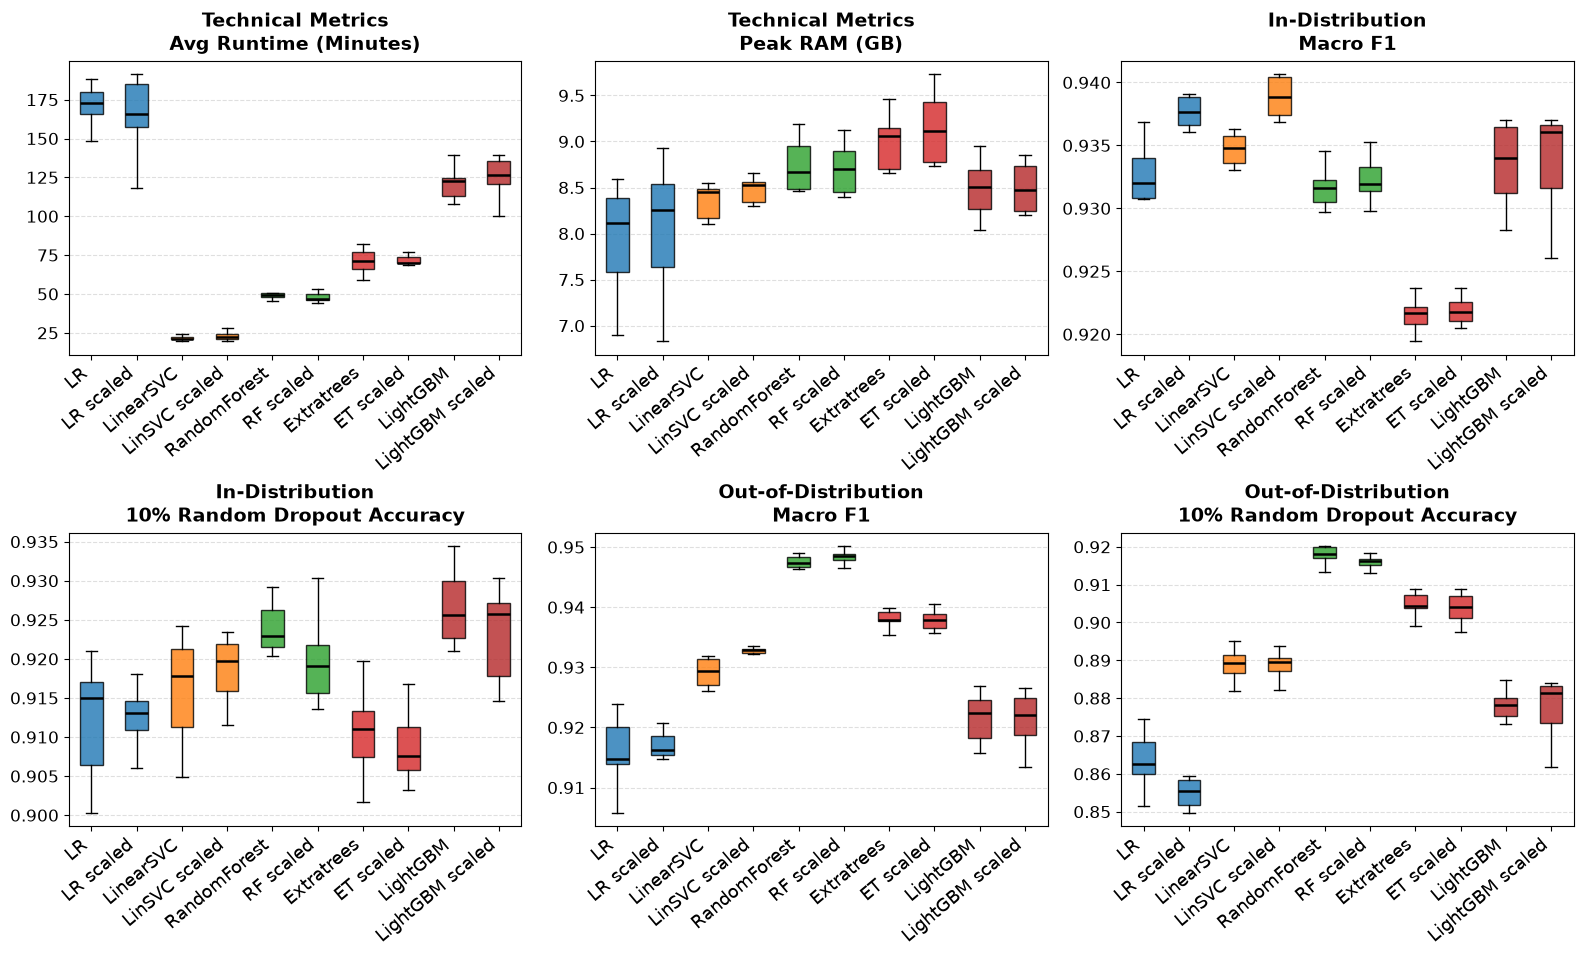

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs).
    Gemittelt werden die Werte der 4 OOD-Datensätze pro Run.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9)
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    
    # 1 & 2: Technical Metrics
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 3 & 4: In-Distribution Metrics
    values = df_runs[('In-Distribution', 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('In-Distribution', 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 5 & 6: OOD Metrics (Mittelwert über die 4 OOD-Datensätze pro Run)
    ood_distributions = [
        'OOD_HIHA_Pediatric', 
        'OOD_HIHA_Young_Adult', 
        'OOD_HIHA_Older_Adult', 
        'OOD_AIDA'
    ]
    
    ood_f1_list = []
    ood_dropout_list = []
    
    for distribution in ood_distributions:
        f1_vals = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).values
        dropout_vals = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).values
        ood_f1_list.append(f1_vals)
        ood_dropout_list.append(dropout_vals)
        
    # Mittelwert über die 4 OOD-Datensätze pro Run berechnen
    avg_ood_f1 = np.mean(ood_f1_list, axis=0).tolist()
    avg_ood_dropout = np.mean(ood_dropout_list, axis=0).tolist()
    
    data_for_boxplot.append(avg_ood_f1)
    data_for_boxplot.append(avg_ood_dropout)
    
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
logisticregression_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/logisticregression/combined_results.csv'
linearsvc_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/linearsvc/combined_result.csv'
randomforest_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/randomforest/combined_result.csv'
extratrees_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/extratrees/combined_result.csv'
lightgbm_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/lightgbm/combined_results.csv'

logisticregression_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/logisticregression_scaled/combined_results.csv'
linearsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/linearsvc_scaled/combined_result.csv'
randomforest_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/randomforest_scaled/combined_result.csv'
extratrees_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/extratrees_scaled/combined_result.csv'
lightgbm_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/lightgbm_scaled/combined_results.csv'

runs_model1 = extract_table_metrics_from_csv(logisticregression_csv_file)
runs_model2 = extract_table_metrics_from_csv(linearsvc_csv_file)
runs_model3 = extract_table_metrics_from_csv(randomforest_csv_file)
runs_model4 = extract_table_metrics_from_csv(extratrees_csv_file)
runs_model5 = extract_table_metrics_from_csv(lightgbm_csv_file)

runs_model11 = extract_table_metrics_from_csv(logisticregression_scaled_csv_file)
runs_model21 = extract_table_metrics_from_csv(linearsvc_scaled_csv_file)
runs_model31 = extract_table_metrics_from_csv(randomforest_scaled_csv_file)
runs_model41 = extract_table_metrics_from_csv(extratrees_scaled_csv_file)
runs_model51 = extract_table_metrics_from_csv(lightgbm_scaled_csv_file)

# Konfiguration der 6 Subplots (2 Zeilen x 3 Spalten)
plot_configs = [
    {'dataset': 'Technical Metrics', 'title': 'Avg Runtime (Minutes)'},
    {'dataset': 'Technical Metrics', 'title': 'Peak RAM (GB)'},
    {'dataset': 'In-Distribution', 'title': 'Macro F1'},
    {'dataset': 'In-Distribution', 'title': '10% Random Dropout Accuracy'},
    {'dataset': 'Out-of-Distribution', 'title': 'Macro F1'},
    {'dataset': 'Out-of-Distribution', 'title': '10% Random Dropout Accuracy'}
]

models = ['LR', 'LR scaled', 'LinearSVC', 'LinSVC scaled', 'RandomForest', 'RF scaled', 'Extratrees', 'ET scaled', 'LightGBM', 'LightGBM scaled']
colors = ['#1f77b4', '#1e77b4', '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728', '#b62728', '#b42728']

# --- 2. BOXPLOT ZEICHNEN (2 ZEILEN x 3 SPALTEN) ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharey=False)

for idx, config in enumerate(plot_configs):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Daten für genau diesen Subplot zusammenstellen
    metric_data = [
        runs_model1[idx],
        runs_model11[idx],
        runs_model2[idx],
        runs_model21[idx],
        runs_model3[idx],
        runs_model31[idx],
        runs_model4[idx],
        runs_model41[idx],
        runs_model5[idx],
        runs_model51[idx]
    ]
    
    # Boxplot zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        #patch.set_linewidth(1.0)
        
    # Mediane markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.8)
        
    # Titel mit Datensatz & Metrik (Poster-optimiert)
    ax.set_title(f"{config['dataset']}\n{config['title']}", fontsize=14, weight='bold', pad=8)
    
    # X-Achse
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=13)
    
    # Y-Achse dynamisch anpassen (Untergrenze automatisch, Obergrenze maximal 1.05 für F1/Accuracy)
    if idx >= 2:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
        
    # Styling-Details für Poster-Optik
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='y', labelsize=12)
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

# Hohe Auflösung für Posterdruck
#plt.savefig('figures/ml_comparison_table_metrics_box_plot.png', dpi=600, bbox_inches='tight')
plt.show()

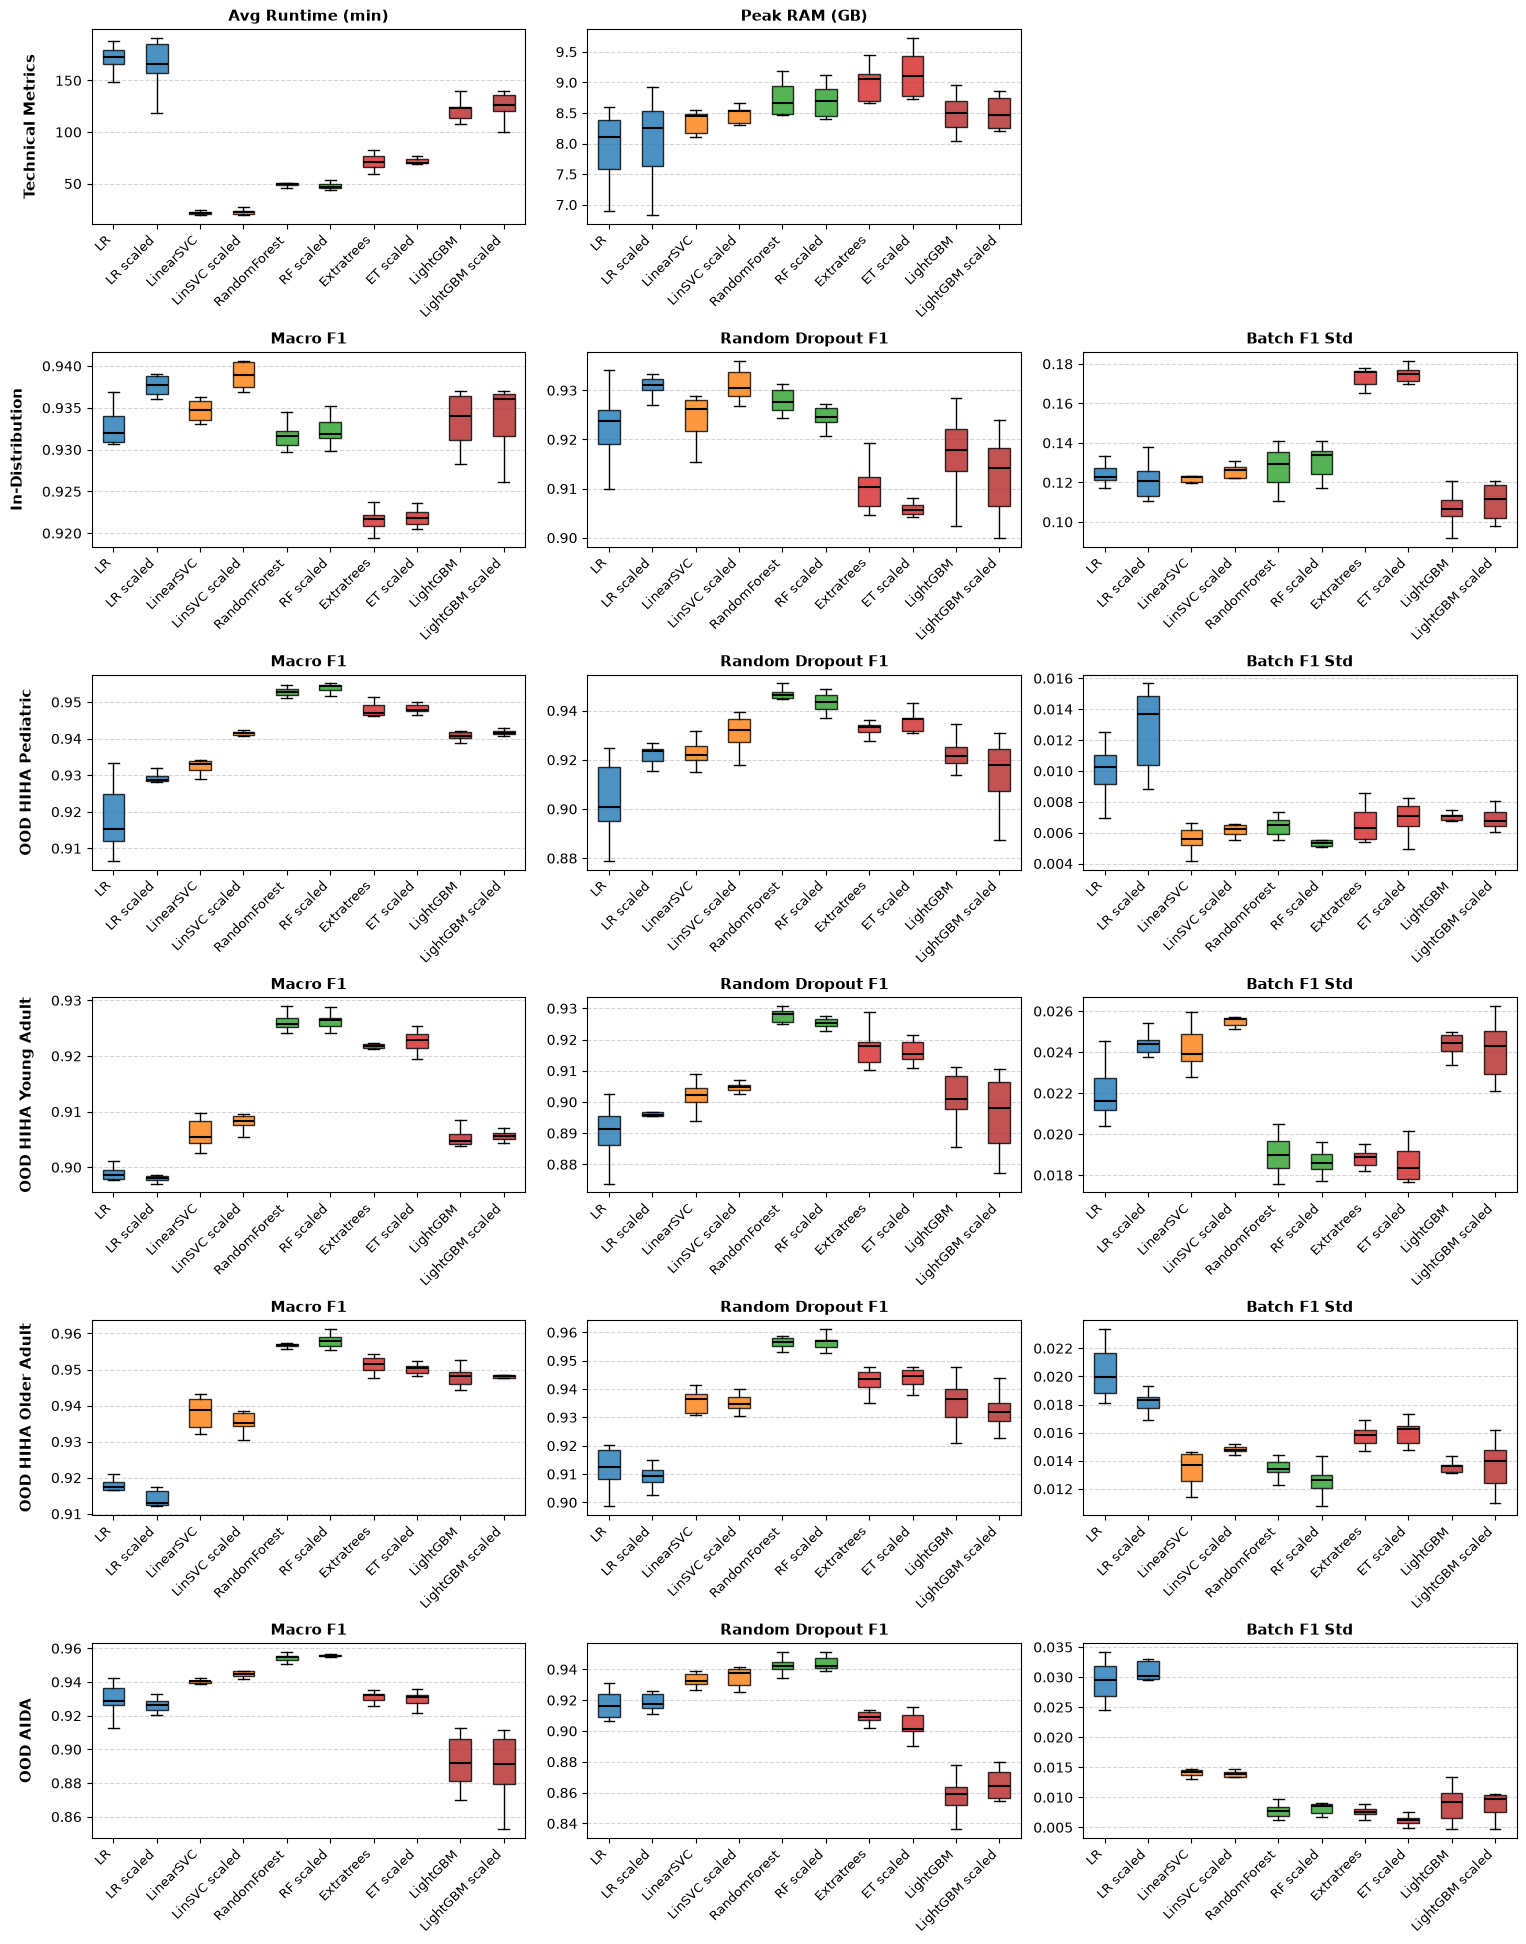

In [4]:
# temporary only with rf, linsvc and extratrees; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'OOD_HIHA_Pediatric', 'OOD_HIHA_Young_Adult', 'OOD_HIHA_Older_Adult', 'OOD_AIDA']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
        # batch_f1_std
        values = df_runs[(distribution, 'Baseline', 'Batch Effect', 'Macro_F1_Std')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
logisticregression_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/logisticregression/combined_results.csv'
linearsvc_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/linearsvc/combined_result.csv'
randomforest_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/randomforest/combined_result.csv'
extratrees_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/extratrees/combined_result.csv'
lightgbm_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/lightgbm/combined_results.csv'

logisticregression_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/logisticregression_scaled/combined_results.csv'
linearsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/linearsvc_scaled/combined_result.csv'
randomforest_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/randomforest_scaled/combined_result.csv'
extratrees_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/extratrees_scaled/combined_result.csv'
lightgbm_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/lightgbm_scaled/combined_results.csv'

subplot_titles = [
    'Avg Runtime (min)', 'Peak RAM (GB)',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1'
]

# Datensatz-Beschriftungen für den linken Rand jeder Zeile
row_labels = [
    'Technical Metrics',
    'In-Distribution',
    'OOD HIHA Pediatric',
    'OOD HIHA Young Adult',
    'OOD HIHA Older Adult',
    'OOD AIDA'
]

runs_model1 = extract_table_metrics_from_csv(logisticregression_csv_file)
runs_model2 = extract_table_metrics_from_csv(linearsvc_csv_file)
runs_model3 = extract_table_metrics_from_csv(randomforest_csv_file)
runs_model4 = extract_table_metrics_from_csv(extratrees_csv_file)
runs_model5 = extract_table_metrics_from_csv(lightgbm_csv_file)

runs_model11 = extract_table_metrics_from_csv(logisticregression_scaled_csv_file)
runs_model21 = extract_table_metrics_from_csv(linearsvc_scaled_csv_file)
runs_model31 = extract_table_metrics_from_csv(randomforest_scaled_csv_file)
runs_model41 = extract_table_metrics_from_csv(extratrees_scaled_csv_file)
runs_model51 = extract_table_metrics_from_csv(lightgbm_scaled_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['LR', 'LR scaled', 'LinearSVC', 'LinSVC scaled', 'RandomForest', 'RF scaled', 'Extratrees', 'ET scaled', 'LightGBM', 'LightGBM scaled']
colors = ['#1f77b4', '#1e77b4', '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728', '#b62728', '#b42728']

# Grid mit 6 Zeilen und 3 Spalten
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20), sharey=False)

# Entferne das leere 3. Feld in der ersten Zeile (Zeile 0, Spalte 2)
fig.delaxes(axes[0, 2])

data_idx = 0  # Fortlaufender Index für die 17 Metriken in data_for_boxplot

for row in range(6):
    # Zeile 0 hat nur 2 Subplots, Zeilen 1-5 haben jeweils 3 Subplots
    num_cols = 2 if row == 0 else 3
    
    for col in range(num_cols):
        ax = axes[row, col]
        
        # Titel je nach Spalte und Zeile festlegen
        if row == 0:
            metric_title = 'Avg Runtime (min)' if col == 0 else 'Peak RAM (GB)'
        else:
            titles_per_row = ['Macro F1', 'Random Dropout F1', 'Batch F1 Std']
            metric_title = titles_per_row[col]
            
        # Daten für genau diesen Plot zusammenstellen
        metric_data = [
            runs_model1[data_idx],
            runs_model11[data_idx],
            runs_model2[data_idx],
            runs_model21[data_idx],
            runs_model3[data_idx],
            runs_model31[data_idx],
            runs_model4[data_idx],
            runs_model41[data_idx],
            runs_model5[data_idx],
            runs_model51[data_idx]
        ]
        
        # Boxplot zeichnen
        bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
        
        # Farben anwenden
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            
        # Mediane schwarz markieren
        for median in bplot['medians']:
            median.set(color='black', linewidth=1.5)
            
        # Subplot-Titel setzen
        ax.set_title(metric_title, fontsize=11, weight='bold')
        
        # Zeilenbeschriftung ganz links am Rand
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, weight='bold', labelpad=12)
            
        # X-Achsen Beschriftung
        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        
        # Y-Achsen-Begrenzung für F1/Dropout-Werte in den Testdatensätzen
        if row > 0:
            bottom, top = ax.get_ylim()
            ax.set_ylim(bottom, min(1.05, top))
            
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        data_idx += 1

# Layout anpassen
plt.tight_layout()
fig.subplots_adjust(top=0.96, left=0.10)

#plt.savefig('figures/ml_scaled_comparison_table_metrics_box_plot.png')
plt.show()

### AE, CAE, CE

#### Only CEs

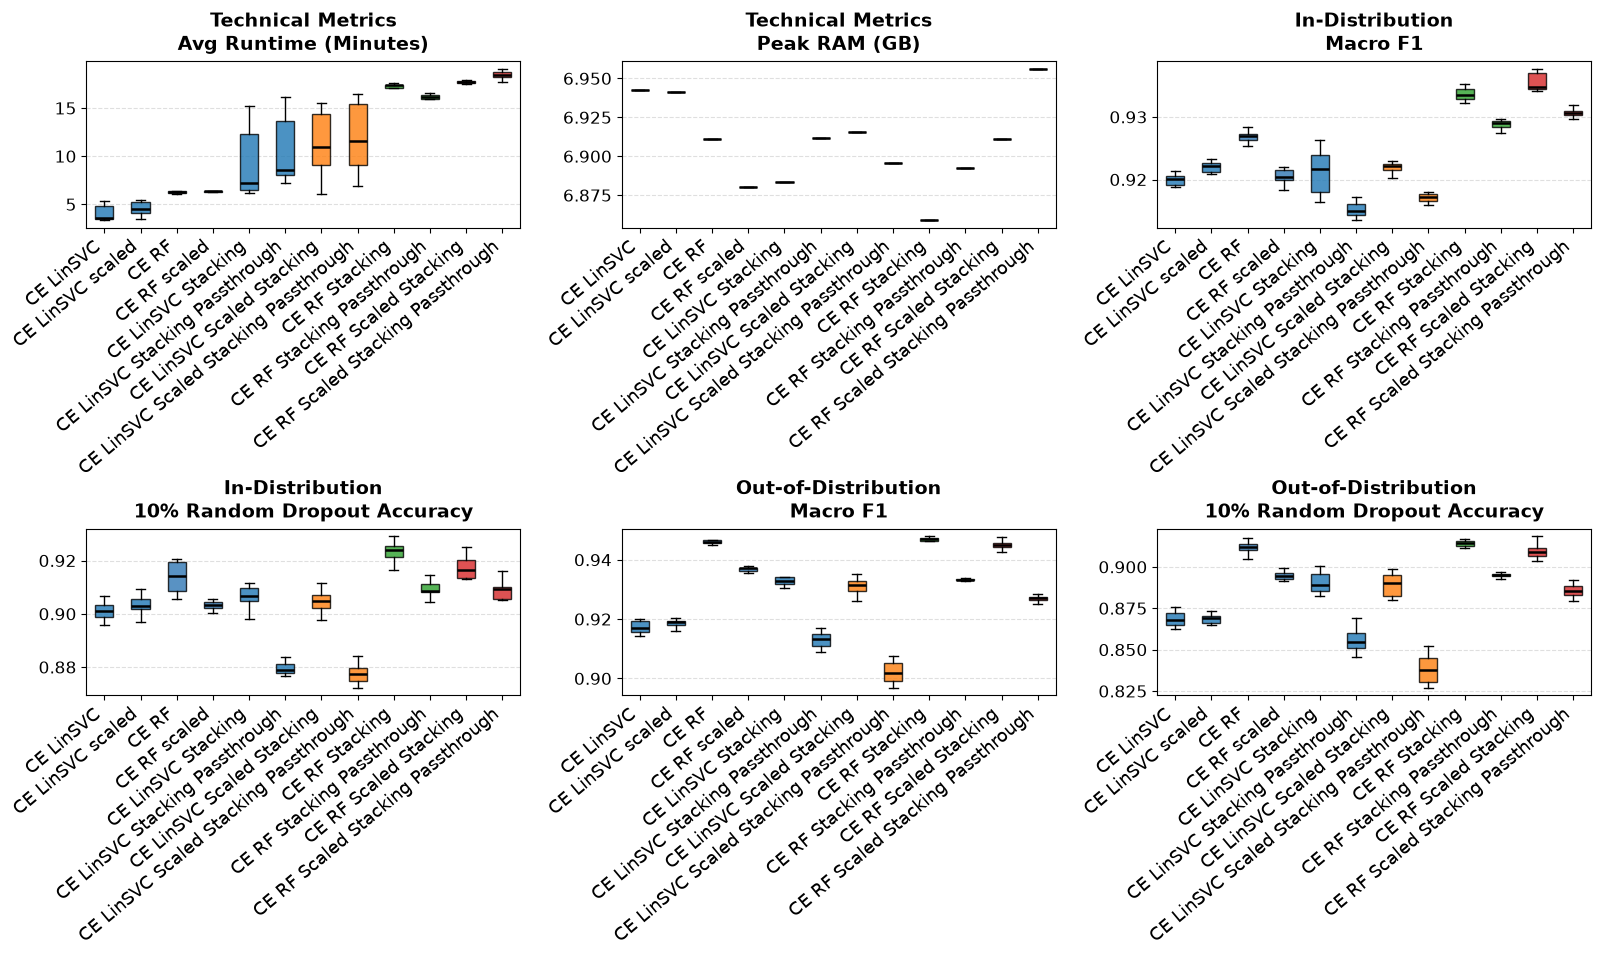

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs).
    Gemittelt werden die Werte der 4 OOD-Datensätze pro Run.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9)
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    
    # 1 & 2: Technical Metrics
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 3 & 4: In-Distribution Metrics
    values = df_runs[('In-Distribution', 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('In-Distribution', 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 5 & 6: OOD Metrics (Mittelwert über die 4 OOD-Datensätze pro Run)
    ood_distributions = [
        'OOD_HIHA_Pediatric', 
        'OOD_HIHA_Young_Adult', 
        'OOD_HIHA_Older_Adult', 
        'OOD_AIDA'
    ]
    
    ood_f1_list = []
    ood_dropout_list = []
    
    for distribution in ood_distributions:
        f1_vals = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).values
        dropout_vals = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).values
        ood_f1_list.append(f1_vals)
        ood_dropout_list.append(dropout_vals)
        
    # Mittelwert über die 4 OOD-Datensätze pro Run berechnen
    avg_ood_f1 = np.mean(ood_f1_list, axis=0).tolist()
    avg_ood_dropout = np.mean(ood_dropout_list, axis=0).tolist()
    
    data_for_boxplot.append(avg_ood_f1)
    data_for_boxplot.append(avg_ood_dropout)
    
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc/combined_result.csv'
ce_linsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_scaled/combined_result.csv'
ce_linsvc_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_stacking/combined_result.csv'
ce_linsvc_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_stacking_passthrough/combined_result.csv'
ce_linsvc_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_scaled_stacking/combined_result.csv'
ce_linsvc_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_scaled_stacking_passthrough/combined_result.csv'
ce_rf_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf/combined_result.csv'
ce_rf_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_scaled/combined_result.csv'
ce_rf_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_stacking/combined_result.csv'
ce_rf_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_stacking_passthrough/combined_result.csv'
ce_rf_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_scaled_stacking/combined_result.csv'
ce_rf_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_scaled_stacking_passthrough/combined_result.csv'

runs_model1 = extract_table_metrics_from_csv(ce_linsvc_csv_file)
runs_model2 = extract_table_metrics_from_csv(ce_linsvc_scaled_csv_file)
runs_model3 = extract_table_metrics_from_csv(ce_rf_csv_file)
runs_model4 = extract_table_metrics_from_csv(ce_rf_scaled_csv_file)
runs_model11 = extract_table_metrics_from_csv(ce_linsvc_stacking_csv_file)
runs_model21 = extract_table_metrics_from_csv(ce_linsvc_stacking_passthrough_csv_file)
runs_model5 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_csv_file)
runs_model6 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_passthrough_csv_file)
runs_model7 = extract_table_metrics_from_csv(ce_rf_stacking_csv_file)
runs_model8 = extract_table_metrics_from_csv(ce_rf_stacking_passthrough_csv_file)
runs_model9 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_csv_file)
runs_model10 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_passthrough_csv_file)

# Konfiguration der 6 Subplots (2 Zeilen x 3 Spalten)
plot_configs = [
    {'dataset': 'Technical Metrics', 'title': 'Avg Runtime (Minutes)'},
    {'dataset': 'Technical Metrics', 'title': 'Peak RAM (GB)'},
    {'dataset': 'In-Distribution', 'title': 'Macro F1'},
    {'dataset': 'In-Distribution', 'title': '10% Random Dropout Accuracy'},
    {'dataset': 'Out-of-Distribution', 'title': 'Macro F1'},
    {'dataset': 'Out-of-Distribution', 'title': '10% Random Dropout Accuracy'}
]

models = ['CE LinSVC', 'CE LinSVC scaled', 'CE RF', 'CE RF scaled', 'CE LinSVC Stacking', 'CE LinSVC Stacking Passthrough', 
          'CE LinSVC Scaled Stacking', 'CE LinSVC Scaled Stacking Passthrough', 
          'CE RF Stacking', 'CE RF Stacking Passthrough', 'CE RF Scaled Stacking', 'CE RF Scaled Stacking Passthrough']
colors = ['#1f77b4', '#1e77b4', '#2f77b4', '#2e77b4', '#1f77b4', '#1e77b4', 
          '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728']

# --- 2. BOXPLOT ZEICHNEN (2 ZEILEN x 3 SPALTEN) ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharey=False)

for idx, config in enumerate(plot_configs):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Daten für genau diesen Subplot zusammenstellen
    metric_data = [
        runs_model1[idx],
        runs_model2[idx],
        runs_model3[idx],
        runs_model4[idx],
        runs_model11[idx],
        runs_model21[idx],
        runs_model5[idx],
        runs_model6[idx],
        runs_model7[idx],
        runs_model8[idx],
        runs_model9[idx],
        runs_model10[idx]
    ]
    
    # Boxplot zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        #patch.set_linewidth(1.0)
        
    # Mediane markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.8)
        
    # Titel mit Datensatz & Metrik (Poster-optimiert)
    ax.set_title(f"{config['dataset']}\n{config['title']}", fontsize=14, weight='bold', pad=8)
    
    # X-Achse
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=13)
    
    # Y-Achse dynamisch anpassen (Untergrenze automatisch, Obergrenze maximal 1.05 für F1/Accuracy)
    if idx >= 2:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
        
    # Styling-Details für Poster-Optik
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='y', labelsize=12)
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

# Hohe Auflösung für Posterdruck
#plt.savefig('figures/ce_cae_comparison_table_metrics_box_plot.png', dpi=600, bbox_inches='tight')
plt.show()

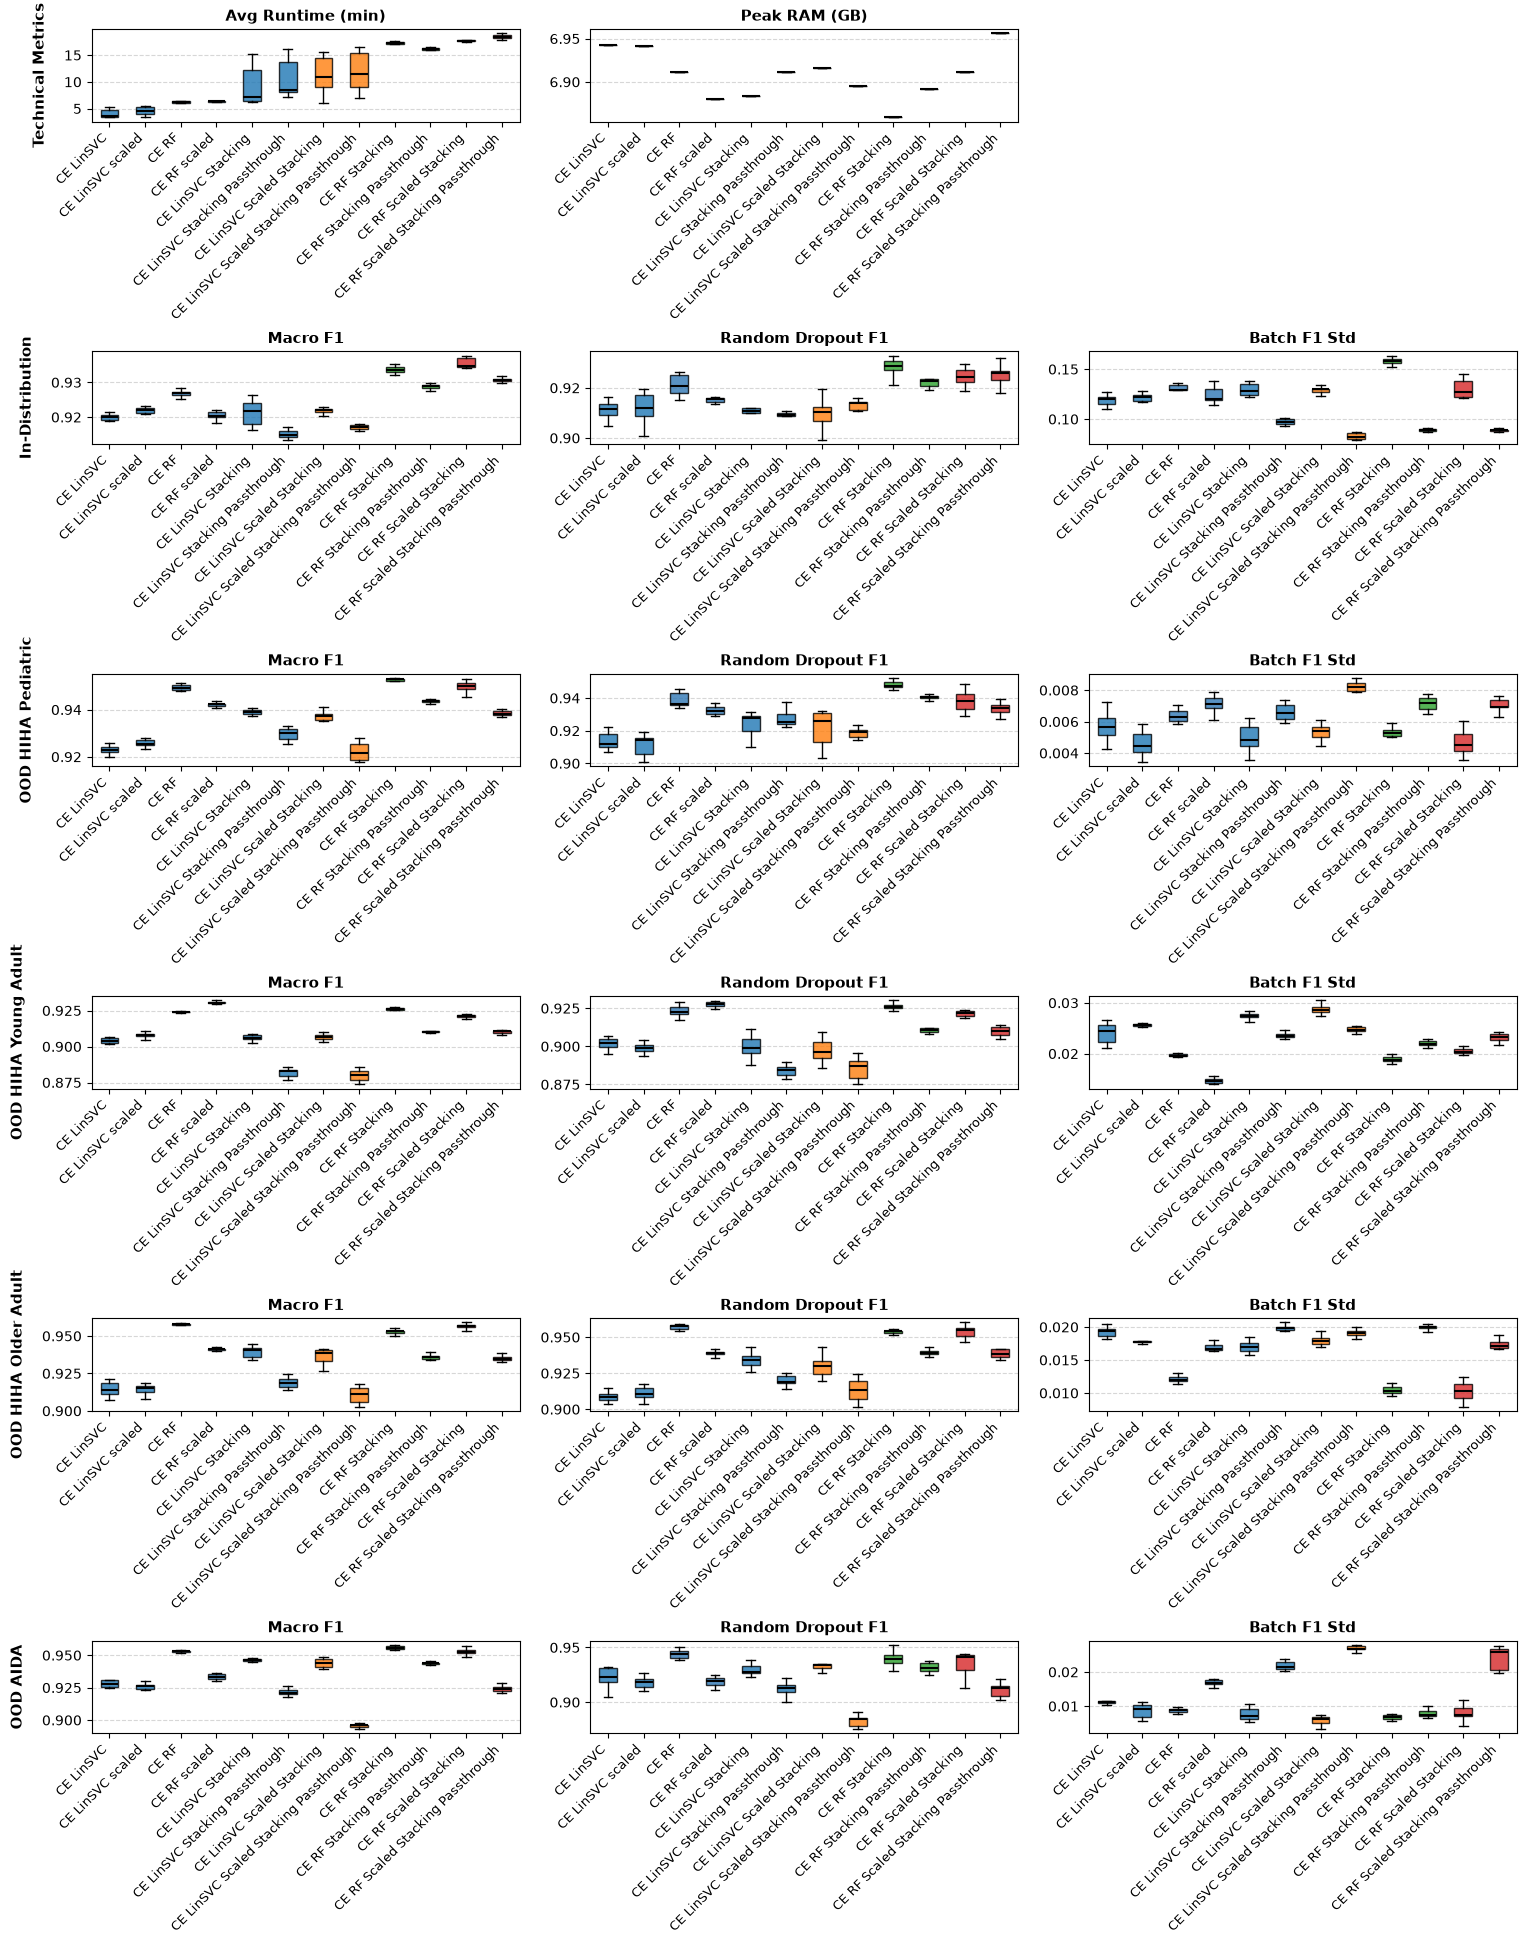

In [6]:
# temporary only with custom ensemble; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'OOD_HIHA_Pediatric', 'OOD_HIHA_Young_Adult', 'OOD_HIHA_Older_Adult', 'OOD_AIDA']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
        # batch_f1_std
        values = df_runs[(distribution, 'Baseline', 'Batch Effect', 'Macro_F1_Std')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc/combined_result.csv'
ce_linsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_scaled/combined_result.csv'
ce_linsvc_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_stacking/combined_result.csv'
ce_linsvc_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_stacking_passthrough/combined_result.csv'
ce_linsvc_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_scaled_stacking/combined_result.csv'
ce_linsvc_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_linsvc_scaled_stacking_passthrough/combined_result.csv'
ce_rf_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf/combined_result.csv'
ce_rf_scaled_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_scaled/combined_result.csv'
ce_rf_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_stacking/combined_result.csv'
ce_rf_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_stacking_passthrough/combined_result.csv'
ce_rf_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_scaled_stacking/combined_result.csv'
ce_rf_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_scaled_stacking_passthrough/combined_result.csv'

clacell_csv_file = '../training/results/mutlitple_ood_datasets/clacell_complete_pipeline/combined_result.csv'
# Offen: combination of cae and ce, clacell complete pipeline

subplot_titles = [
    'Avg Runtime (min)', 'Peak RAM (GB)',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1'
]

# Datensatz-Beschriftungen für den linken Rand jeder Zeile
row_labels = [
    'Technical Metrics',
    'In-Distribution',
    'OOD HIHA Pediatric',
    'OOD HIHA Young Adult',
    'OOD HIHA Older Adult',
    'OOD AIDA'
]

runs_model1 = extract_table_metrics_from_csv(ce_linsvc_csv_file)
runs_model2 = extract_table_metrics_from_csv(ce_linsvc_scaled_csv_file)
runs_model3 = extract_table_metrics_from_csv(ce_rf_csv_file)
runs_model4 = extract_table_metrics_from_csv(ce_rf_scaled_csv_file)
runs_model11 = extract_table_metrics_from_csv(ce_linsvc_stacking_csv_file)
runs_model21 = extract_table_metrics_from_csv(ce_linsvc_stacking_passthrough_csv_file)
runs_model5 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_csv_file)
runs_model6 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_passthrough_csv_file)
runs_model7 = extract_table_metrics_from_csv(ce_rf_stacking_csv_file)
runs_model8 = extract_table_metrics_from_csv(ce_rf_stacking_passthrough_csv_file)
runs_model9 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_csv_file)
runs_model10 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_passthrough_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['CE LinSVC', 'CE LinSVC scaled', 'CE RF', 'CE RF scaled', 'CE LinSVC Stacking', 'CE LinSVC Stacking Passthrough', 
          'CE LinSVC Scaled Stacking', 'CE LinSVC Scaled Stacking Passthrough', 
          'CE RF Stacking', 'CE RF Stacking Passthrough', 'CE RF Scaled Stacking', 'CE RF Scaled Stacking Passthrough']
colors = ['#1f77b4', '#1e77b4', '#2f77b4', '#2e77b4', '#1f77b4', '#1e77b4', 
          '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728']

# Grid mit 6 Zeilen und 3 Spalten
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20), sharey=False)

# Entferne das leere 3. Feld in der ersten Zeile (Zeile 0, Spalte 2)
fig.delaxes(axes[0, 2])

data_idx = 0  # Fortlaufender Index für die 17 Metriken in data_for_boxplot

for row in range(6):
    # Zeile 0 hat nur 2 Subplots, Zeilen 1-5 haben jeweils 3 Subplots
    num_cols = 2 if row == 0 else 3
    
    for col in range(num_cols):
        ax = axes[row, col]
        
        # Titel je nach Spalte und Zeile festlegen
        if row == 0:
            metric_title = 'Avg Runtime (min)' if col == 0 else 'Peak RAM (GB)'
        else:
            titles_per_row = ['Macro F1', 'Random Dropout F1', 'Batch F1 Std']
            metric_title = titles_per_row[col]
            
        # Daten für genau diesen Plot zusammenstellen
        metric_data = [
            runs_model1[data_idx],
            runs_model2[data_idx],
            runs_model3[data_idx],
            runs_model4[data_idx],
            runs_model11[data_idx],
            runs_model21[data_idx],
            runs_model5[data_idx],
            runs_model6[data_idx],
            runs_model7[data_idx],
            runs_model8[data_idx],
            runs_model9[data_idx],
            runs_model10[data_idx]
        ]
        
        # Boxplot zeichnen
        bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
        
        # Farben anwenden
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            
        # Mediane schwarz markieren
        for median in bplot['medians']:
            median.set(color='black', linewidth=1.5)
            
        # Subplot-Titel setzen
        ax.set_title(metric_title, fontsize=11, weight='bold')
        
        # Zeilenbeschriftung ganz links am Rand
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, weight='bold', labelpad=12)
            
        # X-Achsen Beschriftung
        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        
        # Y-Achsen-Begrenzung für F1/Dropout-Werte in den Testdatensätzen
        if row > 0:
            bottom, top = ax.get_ylim()
            ax.set_ylim(bottom, min(1.05, top))
            
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        data_idx += 1

# Layout anpassen
plt.tight_layout()
fig.subplots_adjust(top=0.96, left=0.10)

#plt.savefig('figures/cae_ce_scaled_comparison_table_metrics_box_plot.png')
plt.show()

#### Best CE with AE and CAE

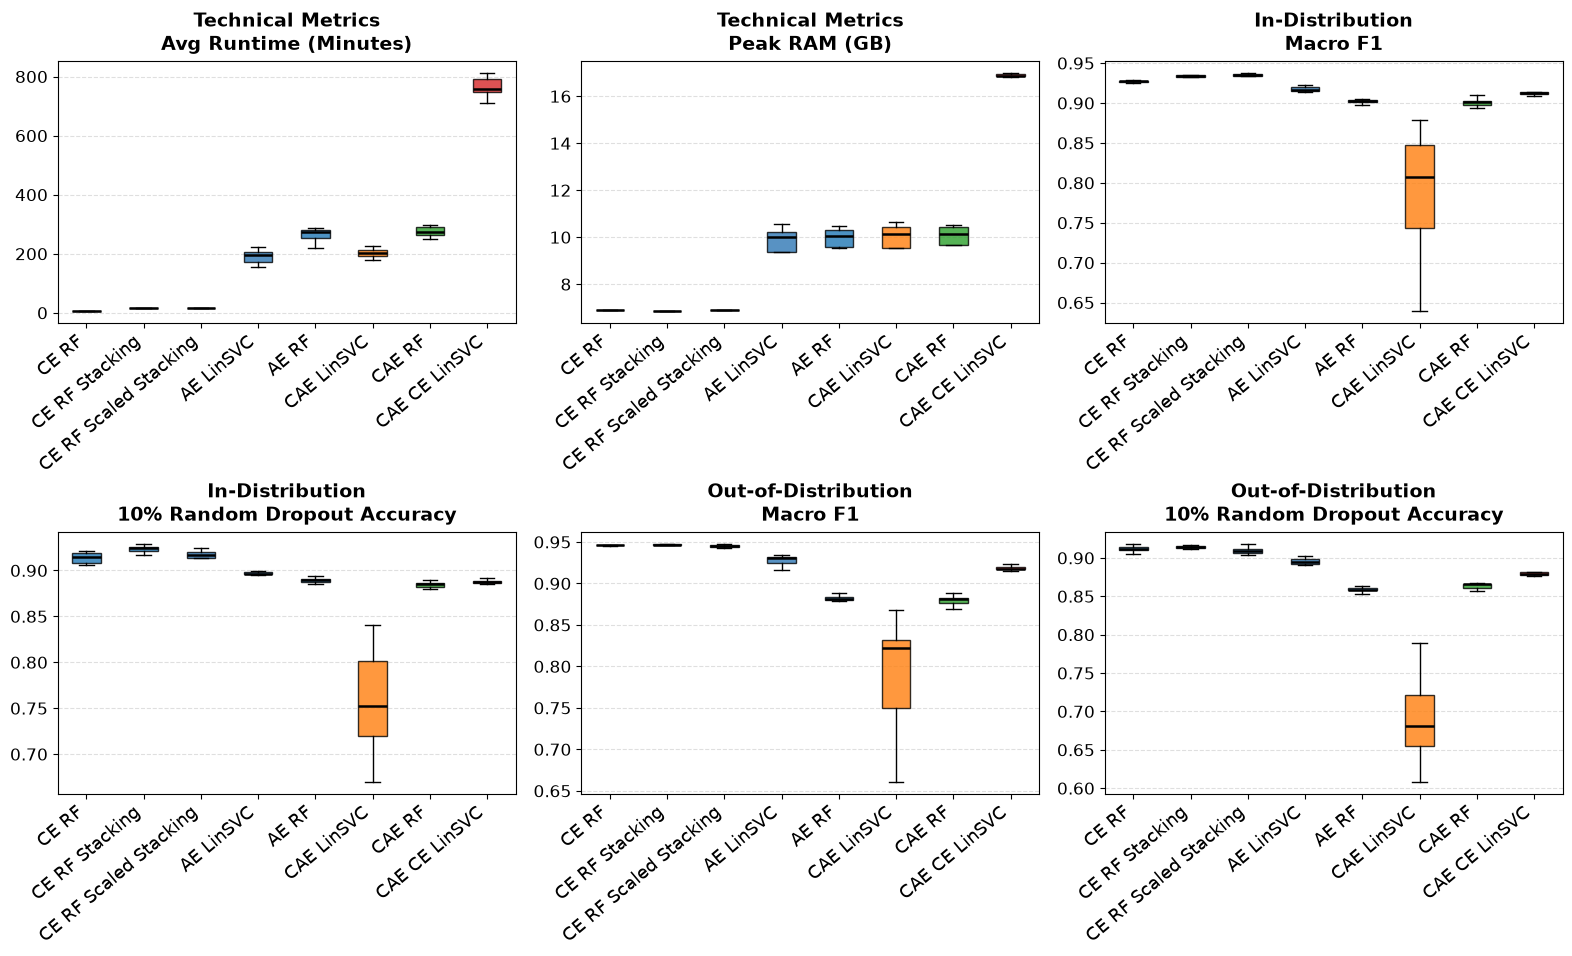

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs).
    Gemittelt werden die Werte der 4 OOD-Datensätze pro Run.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9)
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    
    # 1 & 2: Technical Metrics
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 3 & 4: In-Distribution Metrics
    values = df_runs[('In-Distribution', 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('In-Distribution', 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 5 & 6: OOD Metrics (Mittelwert über die 4 OOD-Datensätze pro Run)
    ood_distributions = [
        'OOD_HIHA_Pediatric', 
        'OOD_HIHA_Young_Adult', 
        'OOD_HIHA_Older_Adult', 
        'OOD_AIDA'
    ]
    
    ood_f1_list = []
    ood_dropout_list = []
    
    for distribution in ood_distributions:
        f1_vals = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).values
        dropout_vals = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).values
        ood_f1_list.append(f1_vals)
        ood_dropout_list.append(dropout_vals)
        
    # Mittelwert über die 4 OOD-Datensätze pro Run berechnen
    avg_ood_f1 = np.mean(ood_f1_list, axis=0).tolist()
    avg_ood_dropout = np.mean(ood_dropout_list, axis=0).tolist()
    
    data_for_boxplot.append(avg_ood_f1)
    data_for_boxplot.append(avg_ood_dropout)
    
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_rf_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf/combined_result.csv'
ce_rf_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_stacking/combined_result.csv'
ce_rf_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_scaled_stacking/combined_result.csv'

ae_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/autoencoder_linsvc/combined_results.csv'
ae_rf_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/autoencoder_rf/combined_results.csv'
cae_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/conditional_autoencoder_linsvc/combined_results.csv'
cae_rf_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/conditional_autoencoder_rf/combined_results.csv'
cae_ce_linsvc_file = '../training/results/mutlitple_ood_datasets/coarse_labels/conditional_autoencoder_custom_ensemble_linsvc_gene_drop/combined_results.csv'

runs_model1 = extract_table_metrics_from_csv(ce_rf_csv_file)
runs_model2 = extract_table_metrics_from_csv(ce_rf_stacking_csv_file)
runs_model3 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_csv_file)
runs_model4 = extract_table_metrics_from_csv(ae_linsvc_csv_file)
runs_model5 = extract_table_metrics_from_csv(ae_rf_csv_file)
runs_model6 = extract_table_metrics_from_csv(cae_linsvc_csv_file)
runs_model7 = extract_table_metrics_from_csv(cae_rf_csv_file)
runs_model8 = extract_table_metrics_from_csv(cae_ce_linsvc_file)

# Konfiguration der 6 Subplots (2 Zeilen x 3 Spalten)
plot_configs = [
    {'dataset': 'Technical Metrics', 'title': 'Avg Runtime (Minutes)'},
    {'dataset': 'Technical Metrics', 'title': 'Peak RAM (GB)'},
    {'dataset': 'In-Distribution', 'title': 'Macro F1'},
    {'dataset': 'In-Distribution', 'title': '10% Random Dropout Accuracy'},
    {'dataset': 'Out-of-Distribution', 'title': 'Macro F1'},
    {'dataset': 'Out-of-Distribution', 'title': '10% Random Dropout Accuracy'}
]

models = ['CE RF', 'CE RF Stacking', 'CE RF Scaled Stacking', 'AE LinSVC', 'AE RF', 'CAE LinSVC', 
          'CAE RF', 'CAE CE LinSVC']
colors = ['#1f77b4', '#1e77b4', '#2f77b4', '#2e77b4', '#1f77b4', 
          '#ff7f0e', '#2ca02c', '#d62728']

# --- 2. BOXPLOT ZEICHNEN (2 ZEILEN x 3 SPALTEN) ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharey=False)

for idx, config in enumerate(plot_configs):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Daten für genau diesen Subplot zusammenstellen
    metric_data = [
        runs_model1[idx],
        runs_model2[idx],
        runs_model3[idx],
        runs_model4[idx],
        runs_model5[idx],
        runs_model6[idx],
        runs_model7[idx],
        runs_model8[idx]
    ]
    
    # Boxplot zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        #patch.set_linewidth(1.0)
        
    # Mediane markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.8)
        
    # Titel mit Datensatz & Metrik (Poster-optimiert)
    ax.set_title(f"{config['dataset']}\n{config['title']}", fontsize=14, weight='bold', pad=8)
    
    # X-Achse
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=13)
    
    # Y-Achse dynamisch anpassen (Untergrenze automatisch, Obergrenze maximal 1.05 für F1/Accuracy)
    if idx >= 2:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
        
    # Styling-Details für Poster-Optik
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='y', labelsize=12)
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

# Hohe Auflösung für Posterdruck
#plt.savefig('figures/ce_cae_comparison_table_metrics_box_plot.png', dpi=600, bbox_inches='tight')
plt.show()

### Reference Models

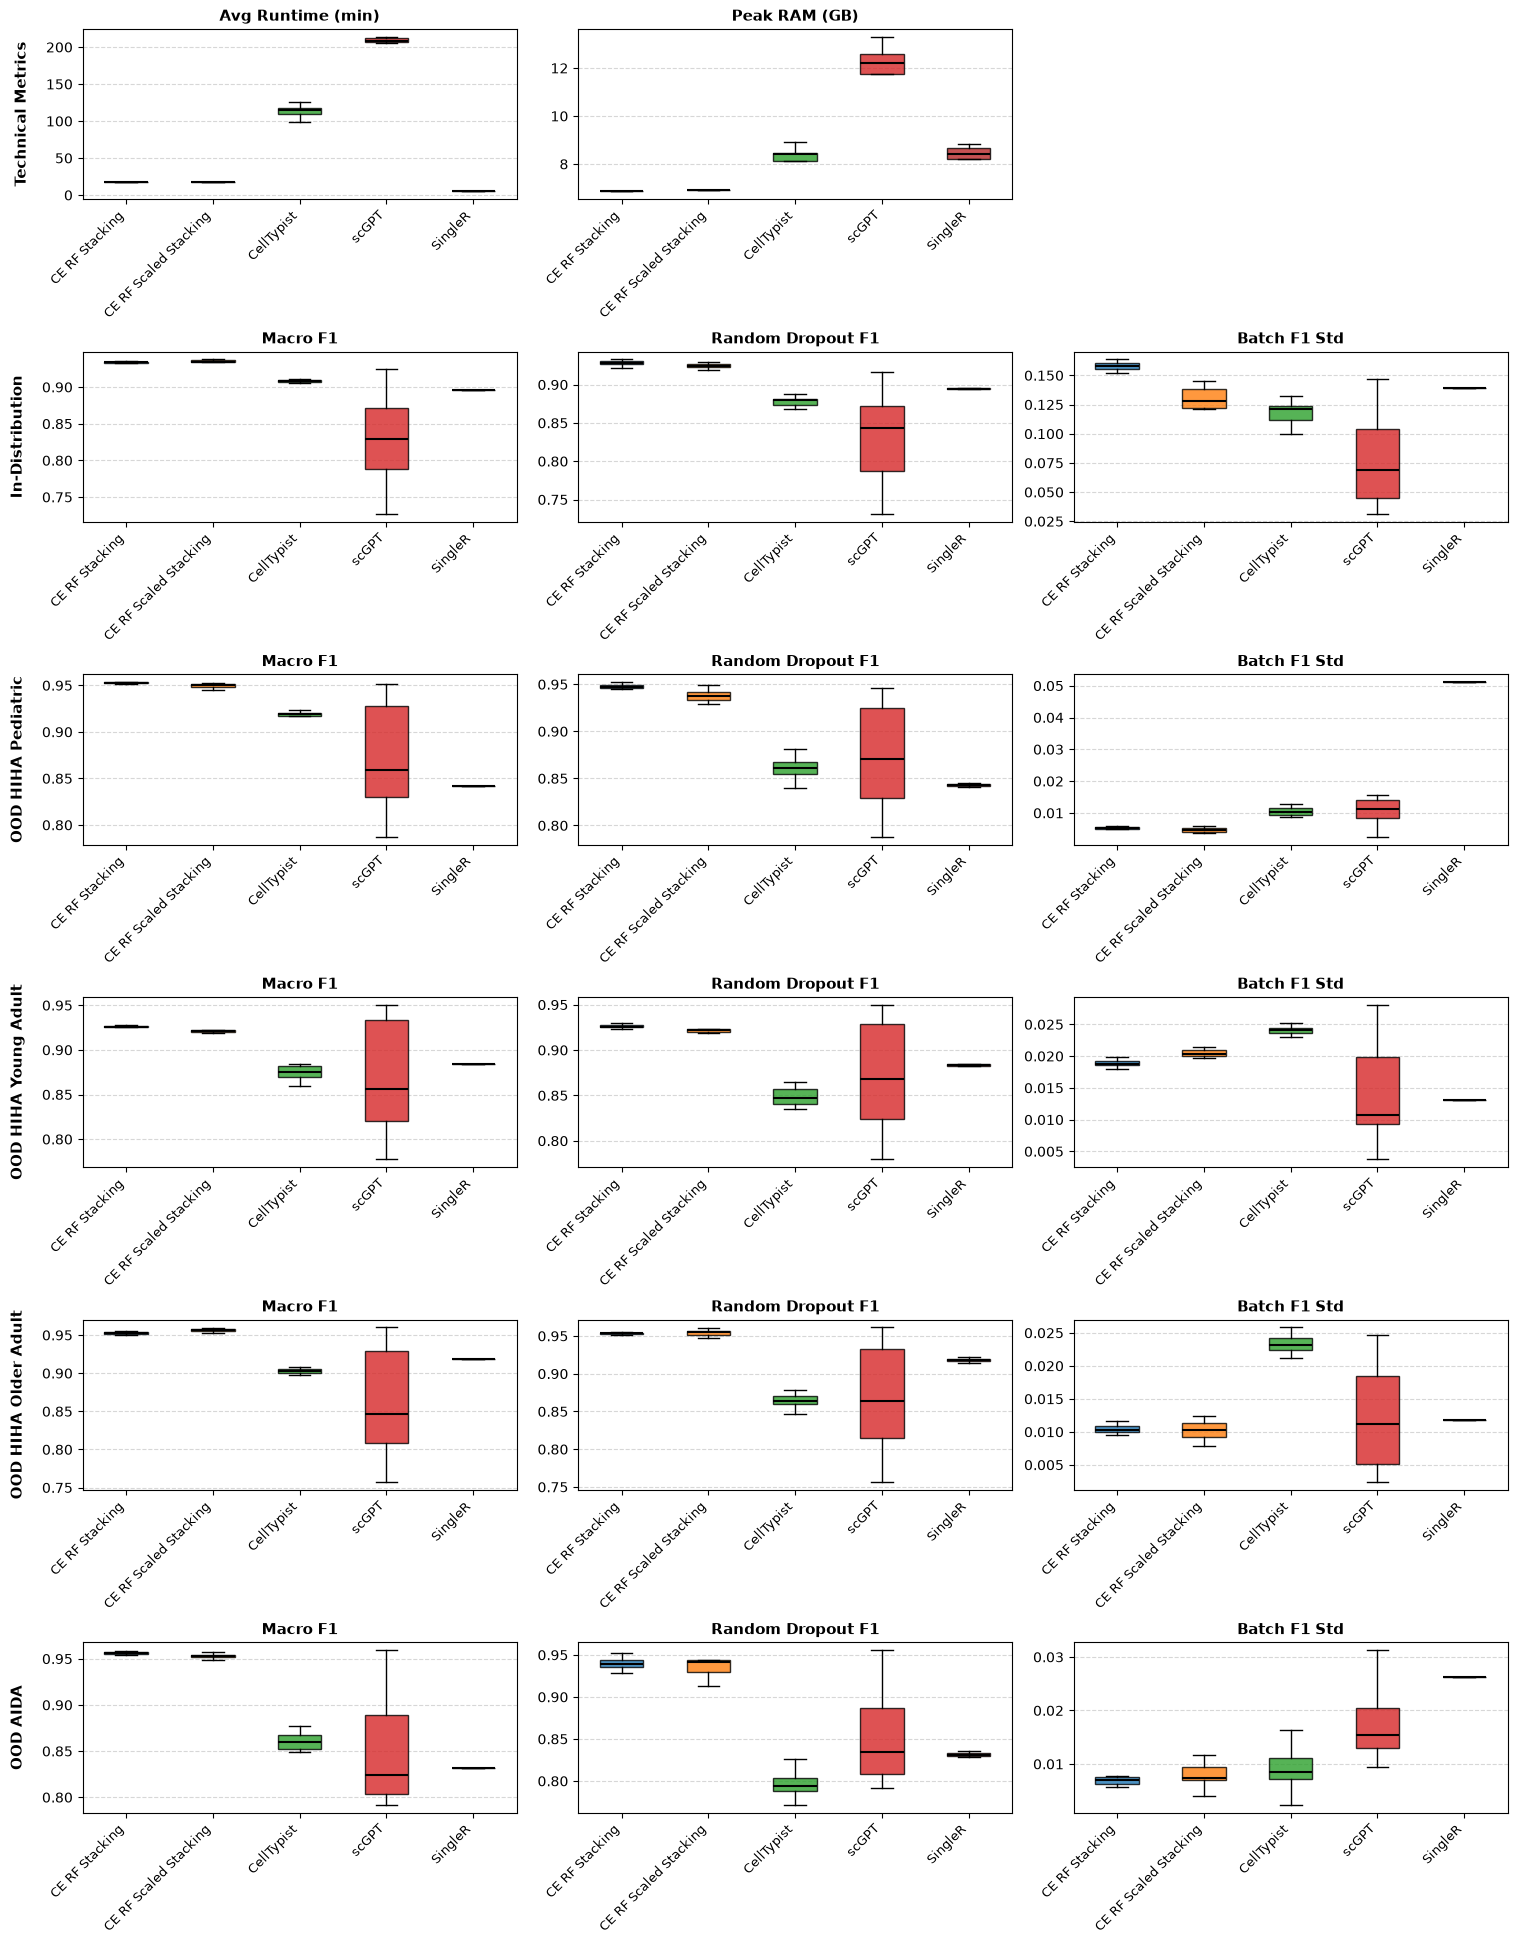

In [7]:
# temporary with ce instead of clacell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'OOD_HIHA_Pediatric', 'OOD_HIHA_Young_Adult', 'OOD_HIHA_Older_Adult', 'OOD_AIDA']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
        # batch_f1_std
        values = df_runs[(distribution, 'Baseline', 'Batch Effect', 'Macro_F1_Std')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
celltypist_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/celltypist_current_python/combined_results.csv'
scgpt_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/scgpt/combined_results.csv'
singler_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/singler/combined_result.csv'

ce_rf_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_stacking/combined_result.csv'
ce_rf_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/custom_ensemble_rf_scaled_stacking/combined_result.csv'

clacell_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/clacell_complete_pipeline/combined_result.csv'
clacell_conditional_csv_file = '../training/results/mutlitple_ood_datasets/coarse_labels/clacell_conditional_bayes_higher_dropout_new_ood/combined_results.csv'

subplot_titles = [
    'Avg Runtime (min)', 'Peak RAM (GB)',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1'
]

# Datensatz-Beschriftungen für den linken Rand jeder Zeile
row_labels = [
    'Technical Metrics',
    'In-Distribution',
    'OOD HIHA Pediatric',
    'OOD HIHA Young Adult',
    'OOD HIHA Older Adult',
    'OOD AIDA'
]

#runs_model1 = extract_table_metrics_from_csv(clacell_csv_file)
#runs_model2 = extract_table_metrics_from_csv(clacell_conditional_csv_file)

runs_model1 = extract_table_metrics_from_csv(ce_rf_stacking_csv_file)
runs_model2 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_csv_file)

runs_model3 = extract_table_metrics_from_csv(celltypist_csv_file)
runs_model4 = extract_table_metrics_from_csv(scgpt_csv_file)
runs_model5 = extract_table_metrics_from_csv(singler_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
#models = ['CLACELL', 'CLACELL CAE', 'CellTypist', 'scGPT', 'SingleR']
models = ['CE RF Stacking', 'CE RF Scaled Stacking', 'CellTypist', 'scGPT', 'SingleR']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#b62728']

# Grid mit 6 Zeilen und 3 Spalten
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20), sharey=False)

# Entferne das leere 3. Feld in der ersten Zeile (Zeile 0, Spalte 2)
fig.delaxes(axes[0, 2])

data_idx = 0  # Fortlaufender Index für die 17 Metriken in data_for_boxplot

for row in range(6):
    # Zeile 0 hat nur 2 Subplots, Zeilen 1-5 haben jeweils 3 Subplots
    num_cols = 2 if row == 0 else 3
    
    for col in range(num_cols):
        ax = axes[row, col]
        
        # Titel je nach Spalte und Zeile festlegen
        if row == 0:
            metric_title = 'Avg Runtime (min)' if col == 0 else 'Peak RAM (GB)'
        else:
            titles_per_row = ['Macro F1', 'Random Dropout F1', 'Batch F1 Std']
            metric_title = titles_per_row[col]
            
        # Daten für genau diesen Plot zusammenstellen
        metric_data = [
            runs_model1[data_idx],
            runs_model2[data_idx],
            runs_model3[data_idx],
            runs_model4[data_idx],
            runs_model5[data_idx]
        ]
        
        # Boxplot zeichnen
        bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
        
        # Farben anwenden
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            
        # Mediane schwarz markieren
        for median in bplot['medians']:
            median.set(color='black', linewidth=1.5)
            
        # Subplot-Titel setzen
        ax.set_title(metric_title, fontsize=11, weight='bold')
        
        # Zeilenbeschriftung ganz links am Rand
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, weight='bold', labelpad=12)
            
        # X-Achsen Beschriftung
        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        
        # Y-Achsen-Begrenzung für F1/Dropout-Werte in den Testdatensätzen
        if row > 0:
            bottom, top = ax.get_ylim()
            ax.set_ylim(bottom, min(1.05, top))
            
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        data_idx += 1

# Layout anpassen
plt.tight_layout()
fig.subplots_adjust(top=0.96, left=0.10)

#plt.savefig('figures/reference_comparison_table_metrics_box_plot.png')
plt.show()

# Fine Grained Labels

## Box Plot Overview

### ML

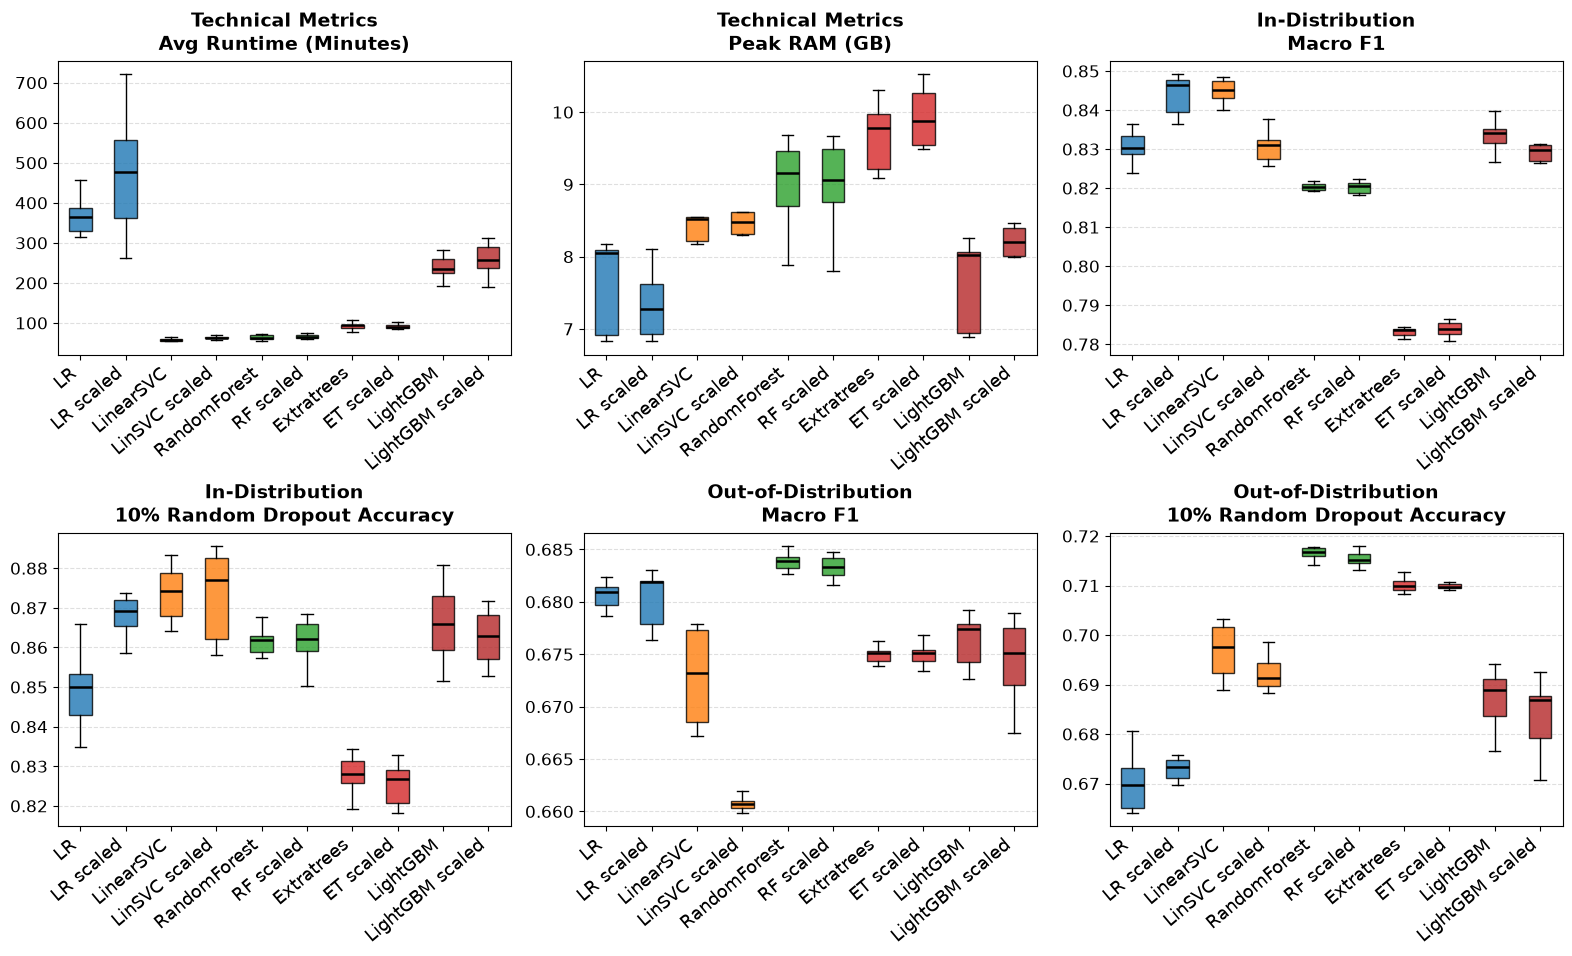

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs).
    Gemittelt werden die Werte der 4 OOD-Datensätze pro Run.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9)
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    
    # 1 & 2: Technical Metrics
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 3 & 4: In-Distribution Metrics
    values = df_runs[('In-Distribution', 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('In-Distribution', 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 5 & 6: OOD Metrics (Mittelwert über die 4 OOD-Datensätze pro Run)
    ood_distributions = [
        'OOD_HIHA_Pediatric', 
        'OOD_HIHA_Young_Adult', 
        'OOD_HIHA_Older_Adult', 
        'OOD_AIDA'
    ]
    
    ood_f1_list = []
    ood_dropout_list = []
    
    for distribution in ood_distributions:
        f1_vals = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).values
        dropout_vals = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).values
        ood_f1_list.append(f1_vals)
        ood_dropout_list.append(dropout_vals)
        
    # Mittelwert über die 4 OOD-Datensätze pro Run berechnen
    avg_ood_f1 = np.mean(ood_f1_list, axis=0).tolist()
    avg_ood_dropout = np.mean(ood_dropout_list, axis=0).tolist()
    
    data_for_boxplot.append(avg_ood_f1)
    data_for_boxplot.append(avg_ood_dropout)
    
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
logisticregression_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/logisticregression/combined_results.csv'
linearsvc_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/linearsvc/combined_result.csv'
randomforest_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/randomforest/combined_result.csv'
extratrees_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/extratrees/combined_result.csv'
lightgbm_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/lightgbm/combined_results.csv'

logisticregression_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/logisticregression_scaled/combined_results.csv'
linearsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/linearsvc_scaled/combined_result.csv'
randomforest_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/randomforest_scaled/combined_result.csv'
extratrees_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/extratrees_scaled/combined_result.csv'
lightgbm_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/lightgbm_scaled/combined_results.csv'

runs_model1 = extract_table_metrics_from_csv(logisticregression_csv_file)
runs_model2 = extract_table_metrics_from_csv(linearsvc_csv_file)
runs_model3 = extract_table_metrics_from_csv(randomforest_csv_file)
runs_model4 = extract_table_metrics_from_csv(extratrees_csv_file)
runs_model5 = extract_table_metrics_from_csv(lightgbm_csv_file)

runs_model11 = extract_table_metrics_from_csv(logisticregression_scaled_csv_file)
runs_model21 = extract_table_metrics_from_csv(linearsvc_scaled_csv_file)
runs_model31 = extract_table_metrics_from_csv(randomforest_scaled_csv_file)
runs_model41 = extract_table_metrics_from_csv(extratrees_scaled_csv_file)
runs_model51 = extract_table_metrics_from_csv(lightgbm_scaled_csv_file)

# Konfiguration der 6 Subplots (2 Zeilen x 3 Spalten)
plot_configs = [
    {'dataset': 'Technical Metrics', 'title': 'Avg Runtime (Minutes)'},
    {'dataset': 'Technical Metrics', 'title': 'Peak RAM (GB)'},
    {'dataset': 'In-Distribution', 'title': 'Macro F1'},
    {'dataset': 'In-Distribution', 'title': '10% Random Dropout Accuracy'},
    {'dataset': 'Out-of-Distribution', 'title': 'Macro F1'},
    {'dataset': 'Out-of-Distribution', 'title': '10% Random Dropout Accuracy'}
]

models = ['LR', 'LR scaled', 'LinearSVC', 'LinSVC scaled', 'RandomForest', 'RF scaled', 'Extratrees', 'ET scaled', 'LightGBM', 'LightGBM scaled']
colors = ['#1f77b4', '#1e77b4', '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728', '#b62728', '#b42728']

# --- 2. BOXPLOT ZEICHNEN (2 ZEILEN x 3 SPALTEN) ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharey=False)

for idx, config in enumerate(plot_configs):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Daten für genau diesen Subplot zusammenstellen
    metric_data = [
        runs_model1[idx],
        runs_model11[idx],
        runs_model2[idx],
        runs_model21[idx],
        runs_model3[idx],
        runs_model31[idx],
        runs_model4[idx],
        runs_model41[idx],
        runs_model5[idx],
        runs_model51[idx]
    ]
    
    # Boxplot zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        #patch.set_linewidth(1.0)
        
    # Mediane markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.8)
        
    # Titel mit Datensatz & Metrik (Poster-optimiert)
    ax.set_title(f"{config['dataset']}\n{config['title']}", fontsize=14, weight='bold', pad=8)
    
    # X-Achse
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=13)
    
    # Y-Achse dynamisch anpassen (Untergrenze automatisch, Obergrenze maximal 1.05 für F1/Accuracy)
    if idx >= 2:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
        
    # Styling-Details für Poster-Optik
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='y', labelsize=12)
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

# Hohe Auflösung für Posterdruck
#plt.savefig('figures/ml_comparison_table_metrics_box_plot.png', dpi=600, bbox_inches='tight')
plt.show()

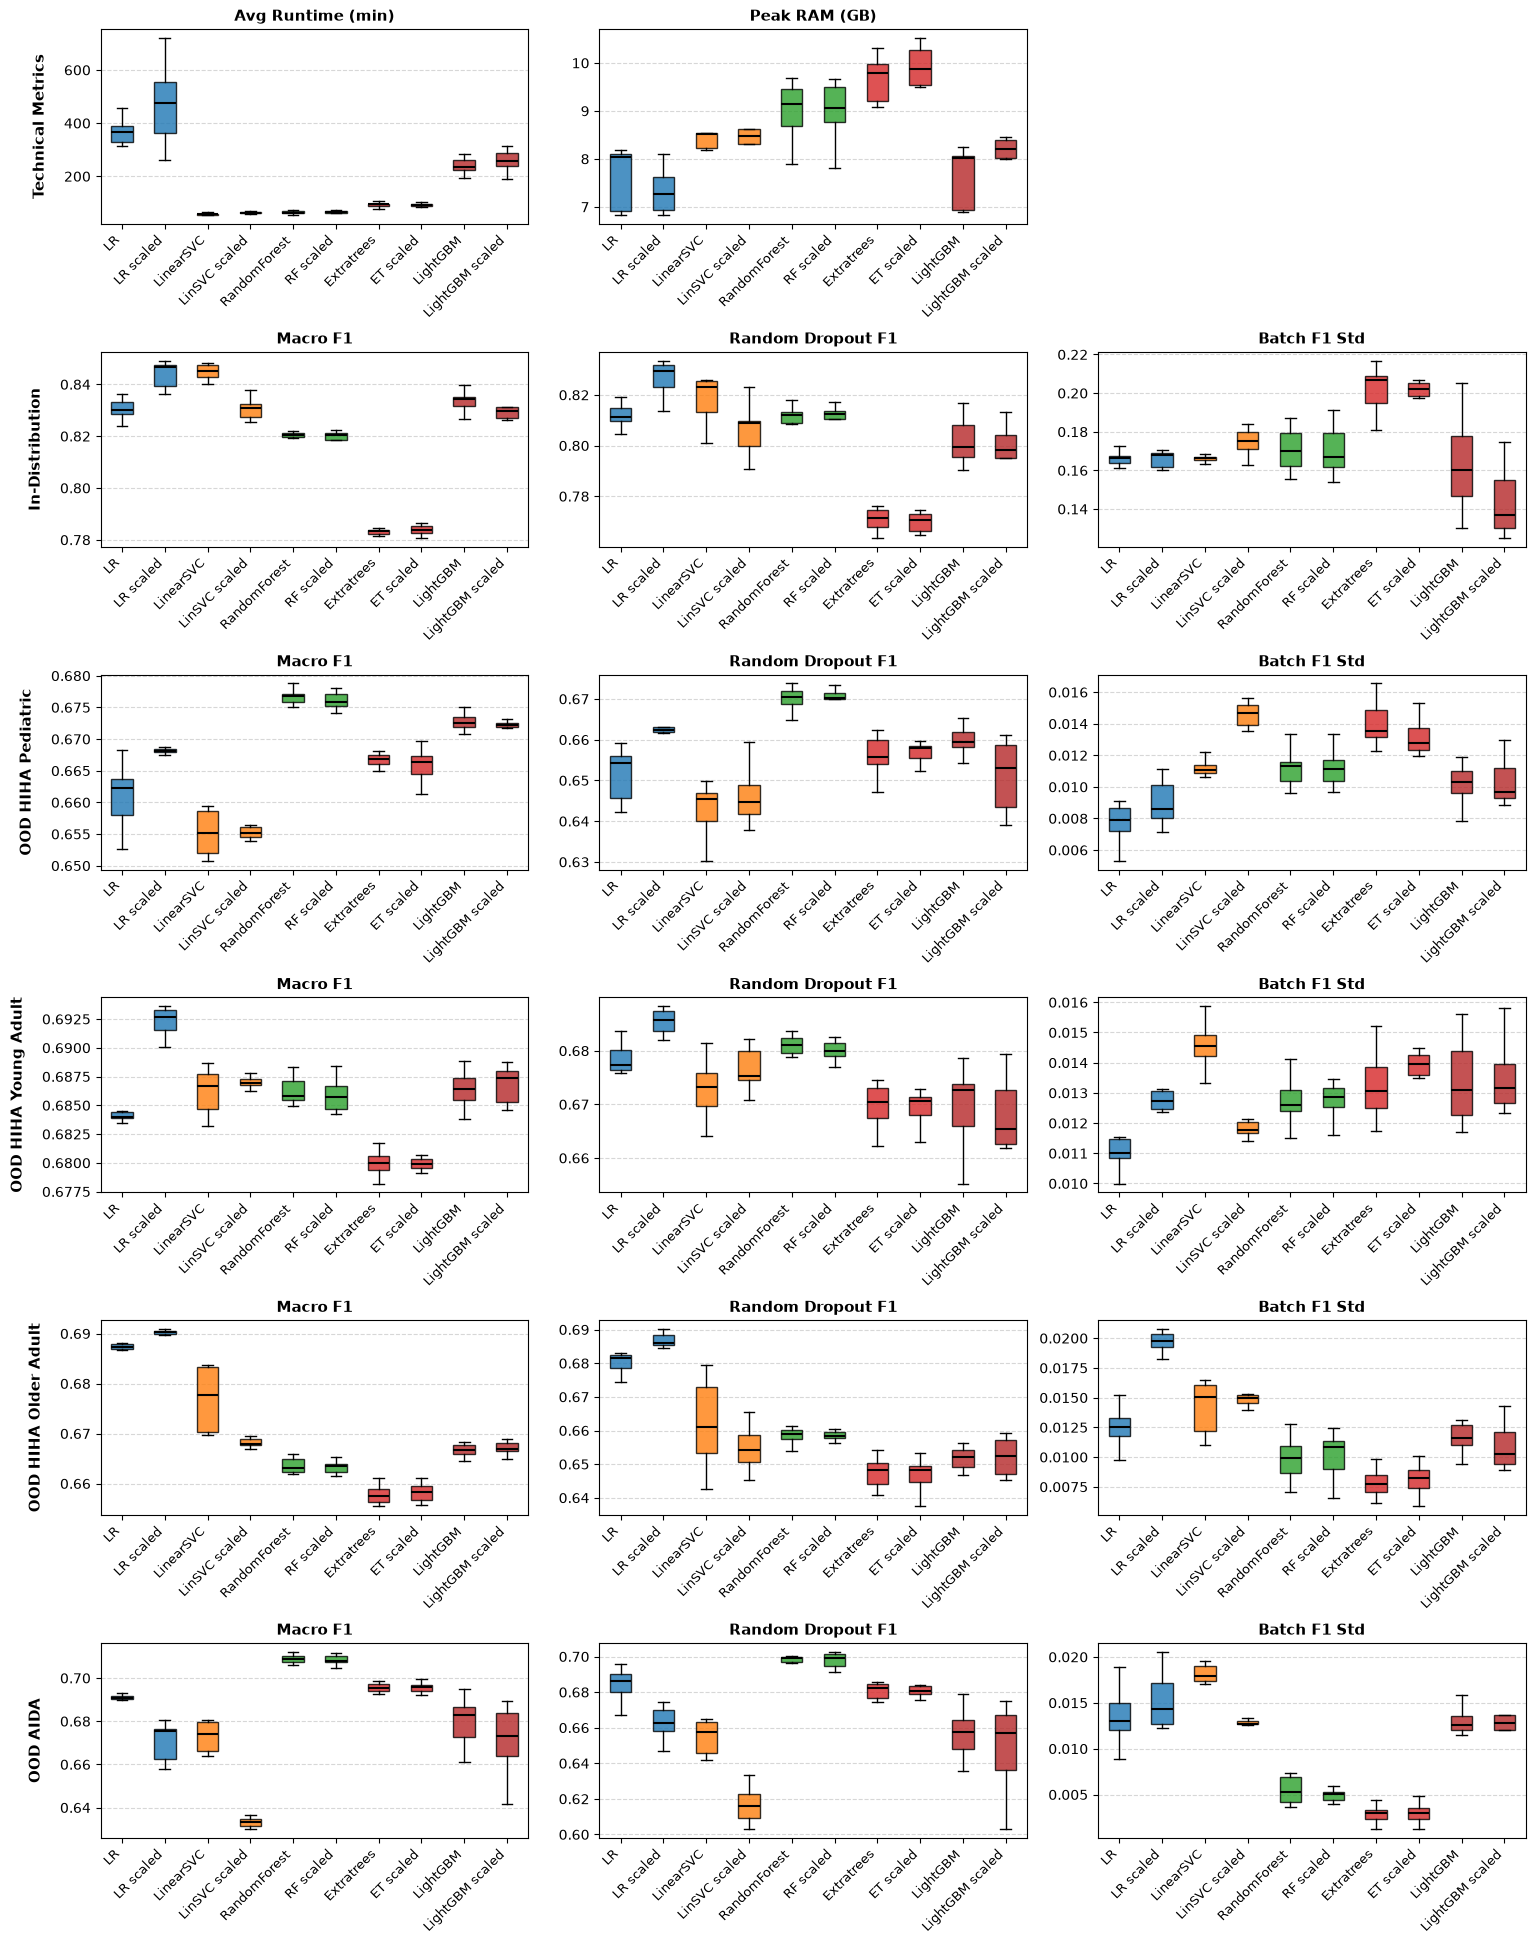

In [1]:
# temporary only with rf, linsvc and extratrees; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'OOD_HIHA_Pediatric', 'OOD_HIHA_Young_Adult', 'OOD_HIHA_Older_Adult', 'OOD_AIDA']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
        # batch_f1_std
        values = df_runs[(distribution, 'Baseline', 'Batch Effect', 'Macro_F1_Std')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
logisticregression_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/logisticregression/combined_results.csv'
linearsvc_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/linearsvc/combined_result.csv'
randomforest_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/randomforest/combined_result.csv'
extratrees_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/extratrees/combined_result.csv'
lightgbm_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/lightgbm/combined_results.csv'

logisticregression_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/logisticregression_scaled/combined_results.csv'
linearsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/linearsvc_scaled/combined_result.csv'
randomforest_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/randomforest_scaled/combined_result.csv'
extratrees_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/extratrees_scaled/combined_result.csv'
lightgbm_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/lightgbm_scaled/combined_results.csv'

subplot_titles = [
    'Avg Runtime (min)', 'Peak RAM (GB)',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1'
]

# Datensatz-Beschriftungen für den linken Rand jeder Zeile
row_labels = [
    'Technical Metrics',
    'In-Distribution',
    'OOD HIHA Pediatric',
    'OOD HIHA Young Adult',
    'OOD HIHA Older Adult',
    'OOD AIDA'
]

runs_model1 = extract_table_metrics_from_csv(logisticregression_csv_file)
runs_model2 = extract_table_metrics_from_csv(linearsvc_csv_file)
runs_model3 = extract_table_metrics_from_csv(randomforest_csv_file)
runs_model4 = extract_table_metrics_from_csv(extratrees_csv_file)
runs_model5 = extract_table_metrics_from_csv(lightgbm_csv_file)

runs_model11 = extract_table_metrics_from_csv(logisticregression_scaled_csv_file)
runs_model21 = extract_table_metrics_from_csv(linearsvc_scaled_csv_file)
runs_model31 = extract_table_metrics_from_csv(randomforest_scaled_csv_file)
runs_model41 = extract_table_metrics_from_csv(extratrees_scaled_csv_file)
runs_model51 = extract_table_metrics_from_csv(lightgbm_scaled_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['LR', 'LR scaled', 'LinearSVC', 'LinSVC scaled', 'RandomForest', 'RF scaled', 'Extratrees', 'ET scaled', 'LightGBM', 'LightGBM scaled']
colors = ['#1f77b4', '#1e77b4', '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728', '#b62728', '#b42728']

# Grid mit 6 Zeilen und 3 Spalten
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20), sharey=False)

# Entferne das leere 3. Feld in der ersten Zeile (Zeile 0, Spalte 2)
fig.delaxes(axes[0, 2])

data_idx = 0  # Fortlaufender Index für die 17 Metriken in data_for_boxplot

for row in range(6):
    # Zeile 0 hat nur 2 Subplots, Zeilen 1-5 haben jeweils 3 Subplots
    num_cols = 2 if row == 0 else 3
    
    for col in range(num_cols):
        ax = axes[row, col]
        
        # Titel je nach Spalte und Zeile festlegen
        if row == 0:
            metric_title = 'Avg Runtime (min)' if col == 0 else 'Peak RAM (GB)'
        else:
            titles_per_row = ['Macro F1', 'Random Dropout F1', 'Batch F1 Std']
            metric_title = titles_per_row[col]
            
        # Daten für genau diesen Plot zusammenstellen
        metric_data = [
            runs_model1[data_idx],
            runs_model11[data_idx],
            runs_model2[data_idx],
            runs_model21[data_idx],
            runs_model3[data_idx],
            runs_model31[data_idx],
            runs_model4[data_idx],
            runs_model41[data_idx],
            runs_model5[data_idx],
            runs_model51[data_idx]
        ]
        
        # Boxplot zeichnen
        bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
        
        # Farben anwenden
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            
        # Mediane schwarz markieren
        for median in bplot['medians']:
            median.set(color='black', linewidth=1.5)
            
        # Subplot-Titel setzen
        ax.set_title(metric_title, fontsize=11, weight='bold')
        
        # Zeilenbeschriftung ganz links am Rand
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, weight='bold', labelpad=12)
            
        # X-Achsen Beschriftung
        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        
        # Y-Achsen-Begrenzung für F1/Dropout-Werte in den Testdatensätzen
        if row > 0:
            bottom, top = ax.get_ylim()
            ax.set_ylim(bottom, min(1.05, top))
            
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        data_idx += 1

# Layout anpassen
plt.tight_layout()
fig.subplots_adjust(top=0.96, left=0.10)

#plt.savefig('figures/ml_scaled_comparison_table_metrics_box_plot.png')
plt.show()

### AE, CAE, CE

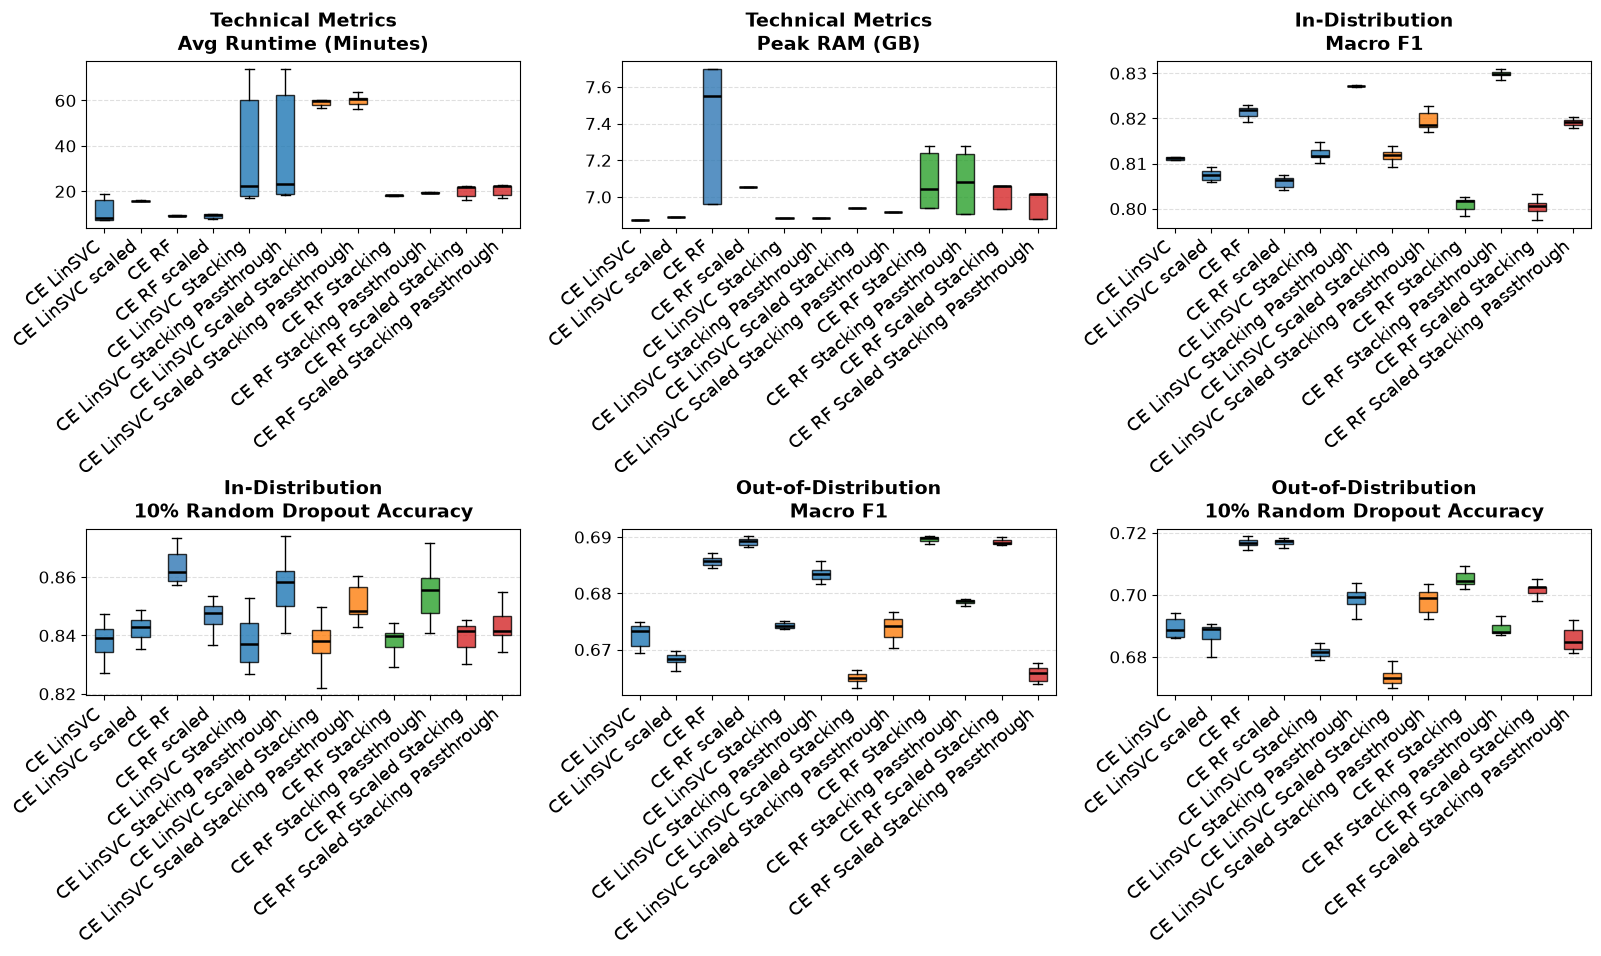

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs).
    Gemittelt werden die Werte der 4 OOD-Datensätze pro Run.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9)
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    
    # 1 & 2: Technical Metrics
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 3 & 4: In-Distribution Metrics
    values = df_runs[('In-Distribution', 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('In-Distribution', 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 5 & 6: OOD Metrics (Mittelwert über die 4 OOD-Datensätze pro Run)
    ood_distributions = [
        'OOD_HIHA_Pediatric', 
        'OOD_HIHA_Young_Adult', 
        'OOD_HIHA_Older_Adult', 
        'OOD_AIDA'
    ]
    
    ood_f1_list = []
    ood_dropout_list = []
    
    for distribution in ood_distributions:
        f1_vals = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).values
        dropout_vals = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).values
        ood_f1_list.append(f1_vals)
        ood_dropout_list.append(dropout_vals)
        
    # Mittelwert über die 4 OOD-Datensätze pro Run berechnen
    avg_ood_f1 = np.mean(ood_f1_list, axis=0).tolist()
    avg_ood_dropout = np.mean(ood_dropout_list, axis=0).tolist()
    
    data_for_boxplot.append(avg_ood_f1)
    data_for_boxplot.append(avg_ood_dropout)
    
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc/combined_result.csv'
ce_linsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled/combined_result.csv'
ce_linsvc_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_stacking/combined_result.csv'
ce_linsvc_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_stacking_passthrough/combined_result.csv'
ce_linsvc_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled_stacking/combined_result.csv'
ce_linsvc_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled_stacking_passthrough/combined_result.csv'
ce_rf_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf/combined_result.csv'
ce_rf_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled/combined_result.csv'
ce_rf_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_stacking/combined_result.csv'
ce_rf_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_stacking_passthrough/combined_result.csv'
ce_rf_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled_stacking/combined_result.csv'
ce_rf_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled_stacking_passthrough/combined_result.csv'

runs_model1 = extract_table_metrics_from_csv(ce_linsvc_csv_file)
runs_model2 = extract_table_metrics_from_csv(ce_linsvc_scaled_csv_file)
runs_model3 = extract_table_metrics_from_csv(ce_rf_csv_file)
runs_model4 = extract_table_metrics_from_csv(ce_rf_scaled_csv_file)
runs_model11 = extract_table_metrics_from_csv(ce_linsvc_stacking_csv_file)
runs_model21 = extract_table_metrics_from_csv(ce_linsvc_stacking_passthrough_csv_file)
runs_model5 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_csv_file)
runs_model6 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_passthrough_csv_file)
runs_model7 = extract_table_metrics_from_csv(ce_rf_stacking_csv_file)
runs_model8 = extract_table_metrics_from_csv(ce_rf_stacking_passthrough_csv_file)
runs_model9 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_csv_file)
runs_model10 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_passthrough_csv_file)

# Konfiguration der 6 Subplots (2 Zeilen x 3 Spalten)
plot_configs = [
    {'dataset': 'Technical Metrics', 'title': 'Avg Runtime (Minutes)'},
    {'dataset': 'Technical Metrics', 'title': 'Peak RAM (GB)'},
    {'dataset': 'In-Distribution', 'title': 'Macro F1'},
    {'dataset': 'In-Distribution', 'title': '10% Random Dropout Accuracy'},
    {'dataset': 'Out-of-Distribution', 'title': 'Macro F1'},
    {'dataset': 'Out-of-Distribution', 'title': '10% Random Dropout Accuracy'}
]

models = ['CE LinSVC', 'CE LinSVC scaled', 'CE RF', 'CE RF scaled', 'CE LinSVC Stacking', 'CE LinSVC Stacking Passthrough', 
          'CE LinSVC Scaled Stacking', 'CE LinSVC Scaled Stacking Passthrough', 
          'CE RF Stacking', 'CE RF Stacking Passthrough', 'CE RF Scaled Stacking', 'CE RF Scaled Stacking Passthrough']
colors = ['#1f77b4', '#1e77b4', '#2f77b4', '#2e77b4', '#1f77b4', '#1e77b4', 
          '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728']

# --- 2. BOXPLOT ZEICHNEN (2 ZEILEN x 3 SPALTEN) ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharey=False)

for idx, config in enumerate(plot_configs):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Daten für genau diesen Subplot zusammenstellen
    metric_data = [
        runs_model1[idx],
        runs_model2[idx],
        runs_model3[idx],
        runs_model4[idx],
        runs_model11[idx],
        runs_model21[idx],
        runs_model5[idx],
        runs_model6[idx],
        runs_model7[idx],
        runs_model8[idx],
        runs_model9[idx],
        runs_model10[idx]
    ]
    
    # Boxplot zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        #patch.set_linewidth(1.0)
        
    # Mediane markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.8)
        
    # Titel mit Datensatz & Metrik (Poster-optimiert)
    ax.set_title(f"{config['dataset']}\n{config['title']}", fontsize=14, weight='bold', pad=8)
    
    # X-Achse
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=13)
    
    # Y-Achse dynamisch anpassen (Untergrenze automatisch, Obergrenze maximal 1.05 für F1/Accuracy)
    if idx >= 2:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
        
    # Styling-Details für Poster-Optik
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='y', labelsize=12)
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

# Hohe Auflösung für Posterdruck
#plt.savefig('figures/ce_cae_comparison_table_metrics_box_plot.png', dpi=600, bbox_inches='tight')
plt.show()

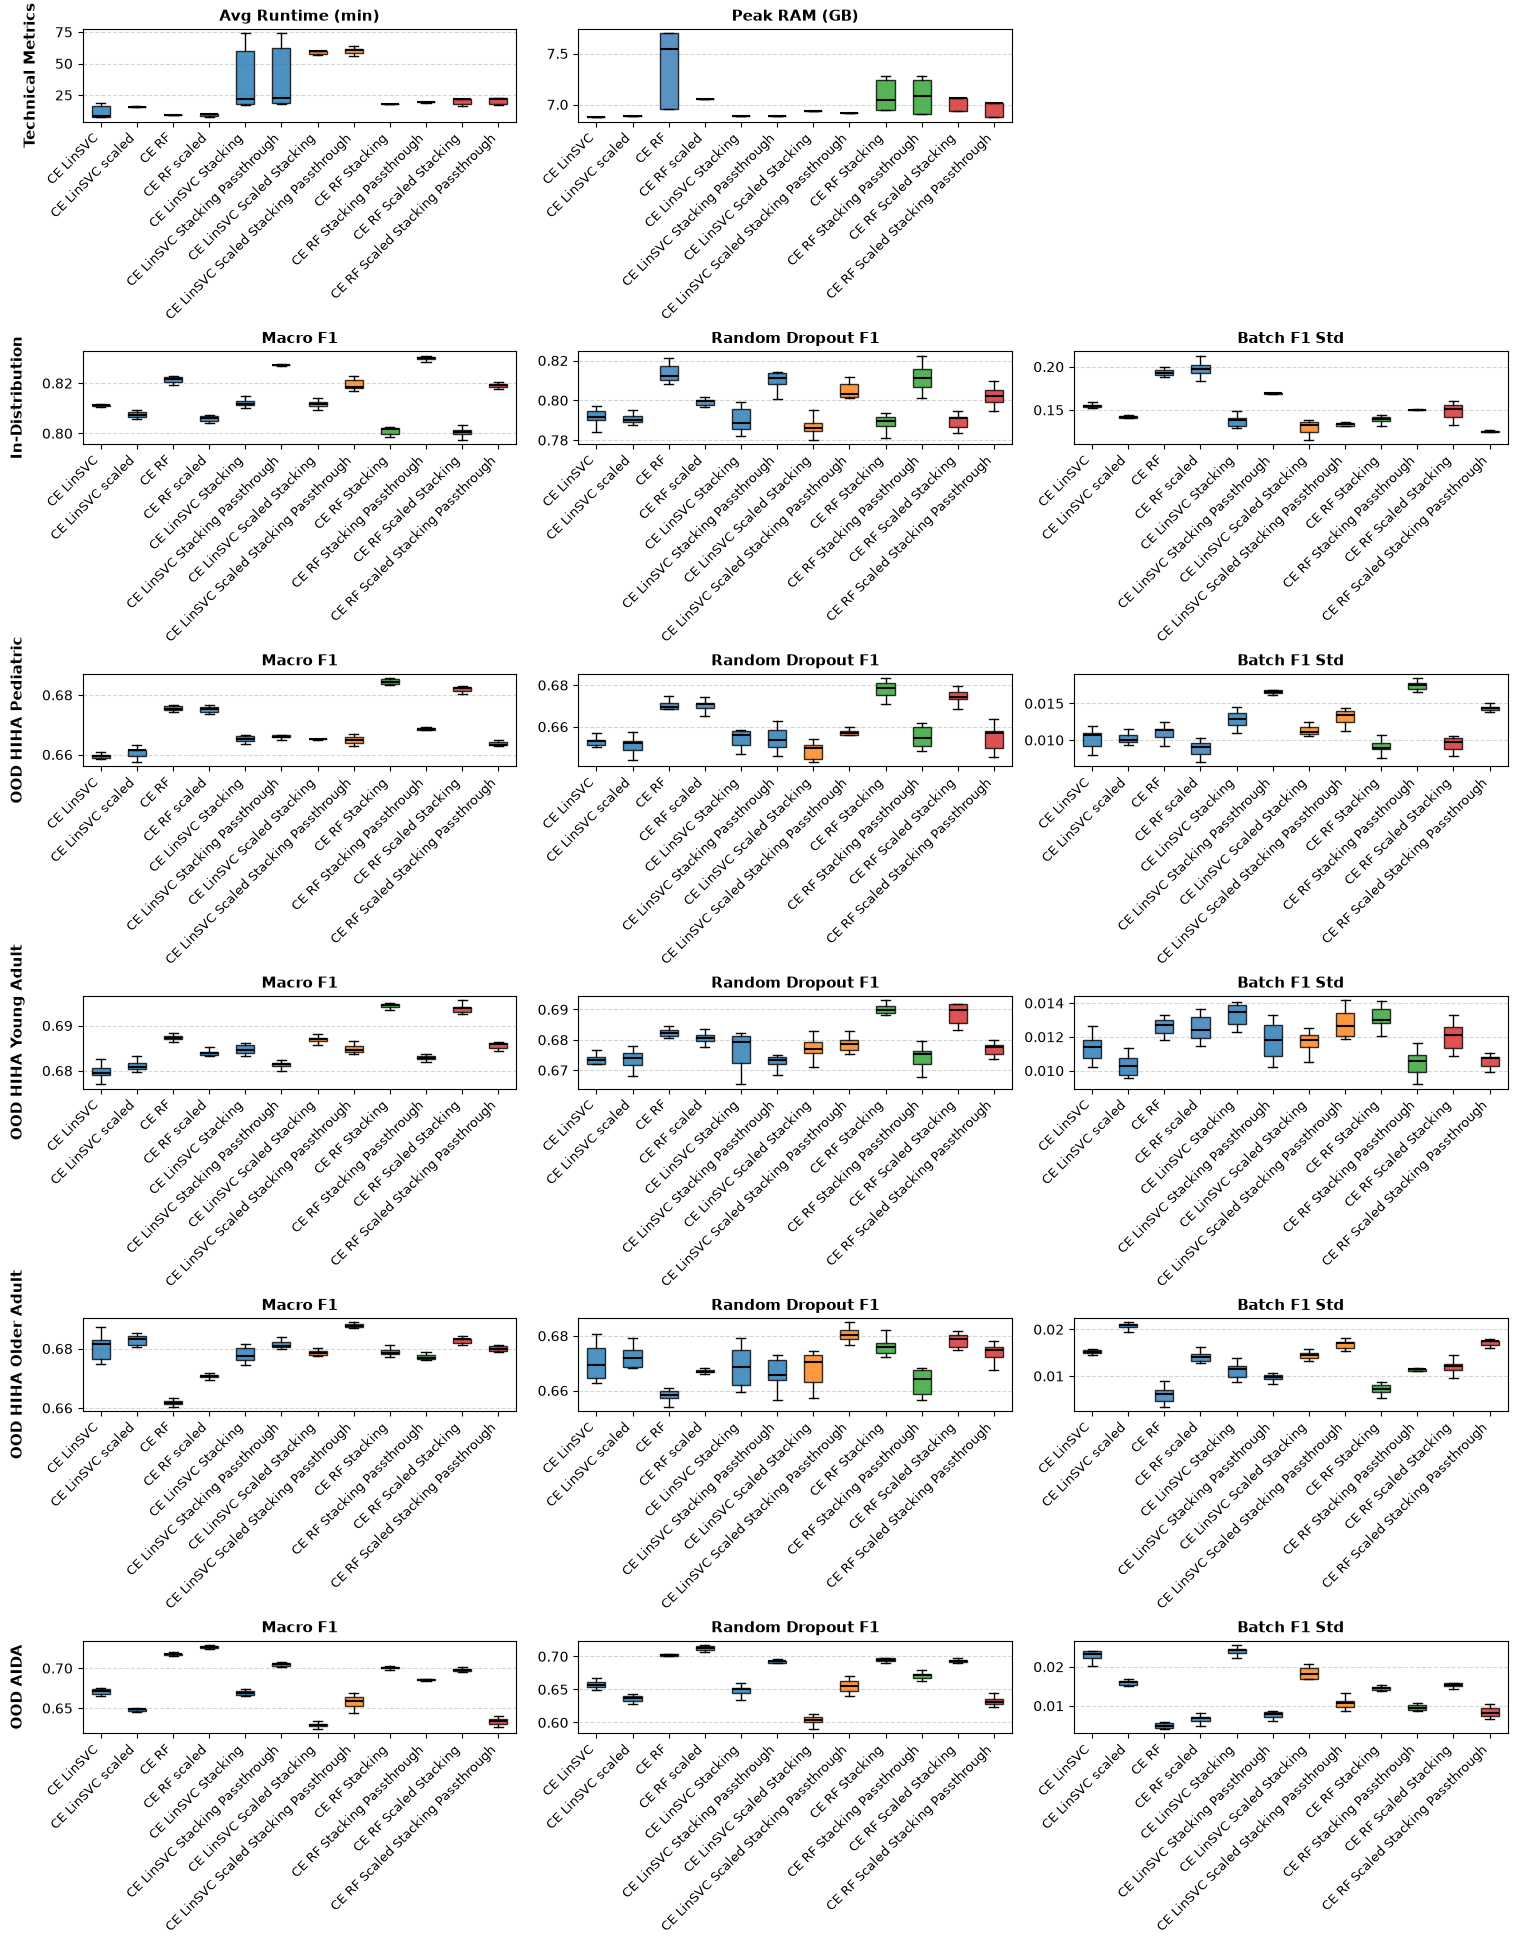

In [2]:
# temporary only with custom ensemble; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'OOD_HIHA_Pediatric', 'OOD_HIHA_Young_Adult', 'OOD_HIHA_Older_Adult', 'OOD_AIDA']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
        # batch_f1_std
        values = df_runs[(distribution, 'Baseline', 'Batch Effect', 'Macro_F1_Std')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc/combined_result.csv'
ce_linsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled/combined_result.csv'
ce_linsvc_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_stacking/combined_result.csv'
ce_linsvc_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_stacking_passthrough/combined_result.csv'
ce_linsvc_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled_stacking/combined_result.csv'
ce_linsvc_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled_stacking_passthrough/combined_result.csv'
ce_rf_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf/combined_result.csv'
ce_rf_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled/combined_result.csv'
ce_rf_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_stacking/combined_result.csv'
ce_rf_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_stacking_passthrough/combined_result.csv'
ce_rf_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled_stacking/combined_result.csv'
ce_rf_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled_stacking_passthrough/combined_result.csv'

clacell_csv_file = '../training/results/mutlitple_ood_datasets/clacell_complete_pipeline/combined_result.csv'
# Offen: combination of cae and ce, clacell complete pipeline

subplot_titles = [
    'Avg Runtime (min)', 'Peak RAM (GB)',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1'
]

# Datensatz-Beschriftungen für den linken Rand jeder Zeile
row_labels = [
    'Technical Metrics',
    'In-Distribution',
    'OOD HIHA Pediatric',
    'OOD HIHA Young Adult',
    'OOD HIHA Older Adult',
    'OOD AIDA'
]

runs_model1 = extract_table_metrics_from_csv(ce_linsvc_csv_file)
runs_model2 = extract_table_metrics_from_csv(ce_linsvc_scaled_csv_file)
runs_model3 = extract_table_metrics_from_csv(ce_rf_csv_file)
runs_model4 = extract_table_metrics_from_csv(ce_rf_scaled_csv_file)
runs_model11 = extract_table_metrics_from_csv(ce_linsvc_stacking_csv_file)
runs_model21 = extract_table_metrics_from_csv(ce_linsvc_stacking_passthrough_csv_file)
runs_model5 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_csv_file)
runs_model6 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_passthrough_csv_file)
runs_model7 = extract_table_metrics_from_csv(ce_rf_stacking_csv_file)
runs_model8 = extract_table_metrics_from_csv(ce_rf_stacking_passthrough_csv_file)
runs_model9 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_csv_file)
runs_model10 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_passthrough_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['CE LinSVC', 'CE LinSVC scaled', 'CE RF', 'CE RF scaled', 'CE LinSVC Stacking', 'CE LinSVC Stacking Passthrough', 
          'CE LinSVC Scaled Stacking', 'CE LinSVC Scaled Stacking Passthrough', 
          'CE RF Stacking', 'CE RF Stacking Passthrough', 'CE RF Scaled Stacking', 'CE RF Scaled Stacking Passthrough']
colors = ['#1f77b4', '#1e77b4', '#2f77b4', '#2e77b4', '#1f77b4', '#1e77b4', 
          '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728']

# Grid mit 6 Zeilen und 3 Spalten
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20), sharey=False)

# Entferne das leere 3. Feld in der ersten Zeile (Zeile 0, Spalte 2)
fig.delaxes(axes[0, 2])

data_idx = 0  # Fortlaufender Index für die 17 Metriken in data_for_boxplot

for row in range(6):
    # Zeile 0 hat nur 2 Subplots, Zeilen 1-5 haben jeweils 3 Subplots
    num_cols = 2 if row == 0 else 3
    
    for col in range(num_cols):
        ax = axes[row, col]
        
        # Titel je nach Spalte und Zeile festlegen
        if row == 0:
            metric_title = 'Avg Runtime (min)' if col == 0 else 'Peak RAM (GB)'
        else:
            titles_per_row = ['Macro F1', 'Random Dropout F1', 'Batch F1 Std']
            metric_title = titles_per_row[col]
            
        # Daten für genau diesen Plot zusammenstellen
        metric_data = [
            runs_model1[data_idx],
            runs_model2[data_idx],
            runs_model3[data_idx],
            runs_model4[data_idx],
            runs_model11[data_idx],
            runs_model21[data_idx],
            runs_model5[data_idx],
            runs_model6[data_idx],
            runs_model7[data_idx],
            runs_model8[data_idx],
            runs_model9[data_idx],
            runs_model10[data_idx]
        ]
        
        # Boxplot zeichnen
        bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
        
        # Farben anwenden
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            
        # Mediane schwarz markieren
        for median in bplot['medians']:
            median.set(color='black', linewidth=1.5)
            
        # Subplot-Titel setzen
        ax.set_title(metric_title, fontsize=11, weight='bold')
        
        # Zeilenbeschriftung ganz links am Rand
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, weight='bold', labelpad=12)
            
        # X-Achsen Beschriftung
        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        
        # Y-Achsen-Begrenzung für F1/Dropout-Werte in den Testdatensätzen
        if row > 0:
            bottom, top = ax.get_ylim()
            ax.set_ylim(bottom, min(1.05, top))
            
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        data_idx += 1

# Layout anpassen
plt.tight_layout()
fig.subplots_adjust(top=0.96, left=0.10)

#plt.savefig('figures/cae_ce_scaled_comparison_table_metrics_box_plot.png')
plt.show()

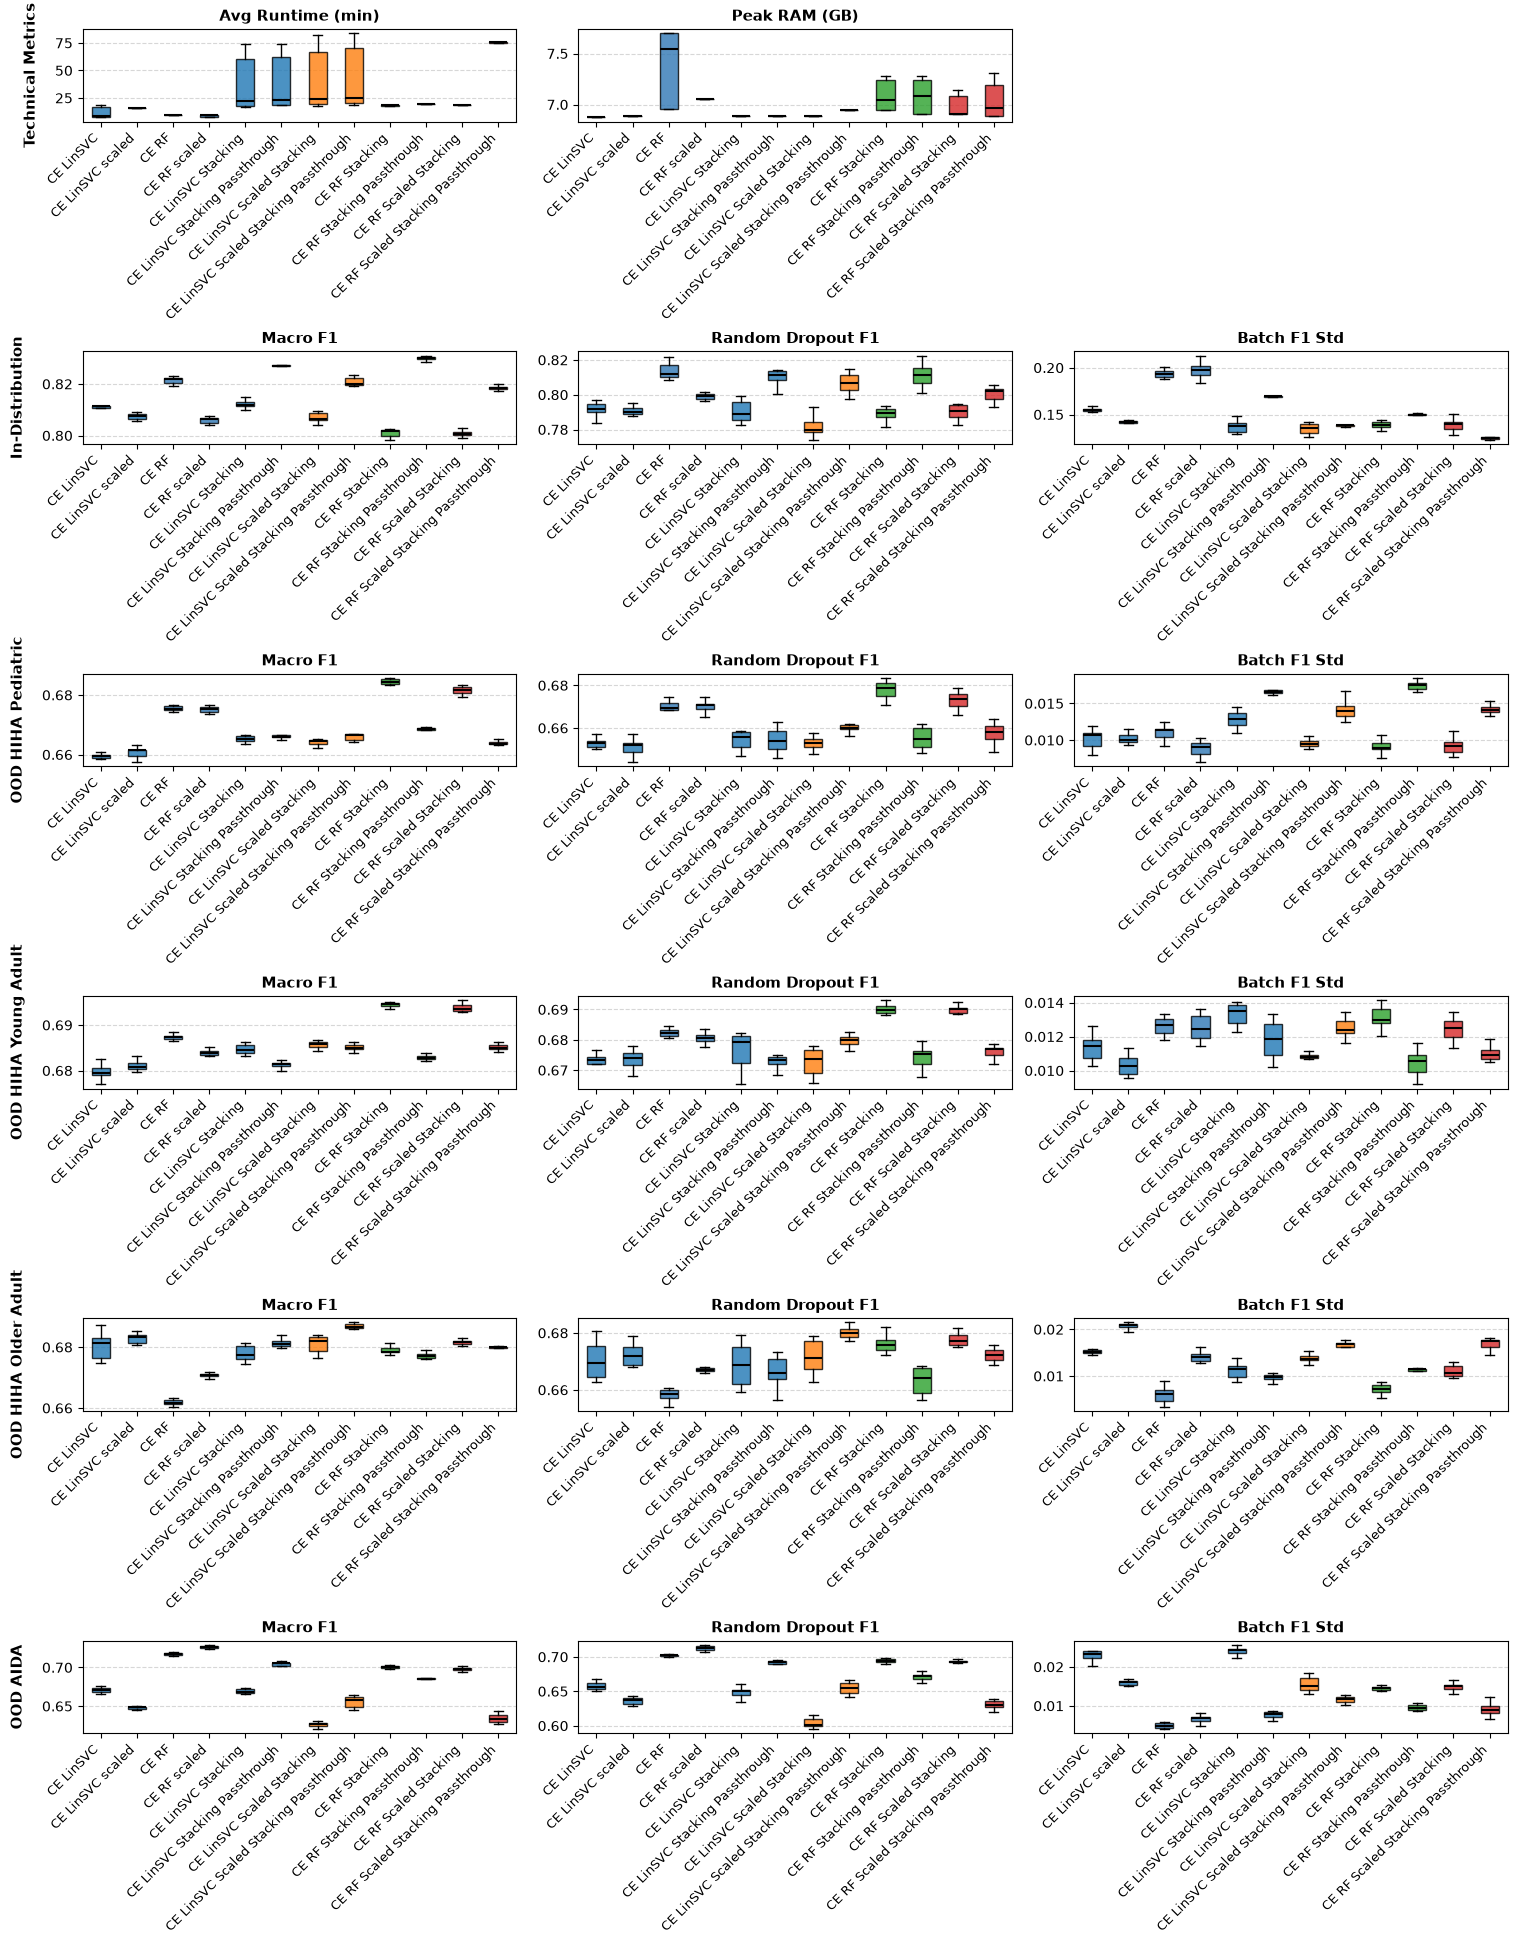

In [2]:
# temporary only with custom ensemble; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'OOD_HIHA_Pediatric', 'OOD_HIHA_Young_Adult', 'OOD_HIHA_Older_Adult', 'OOD_AIDA']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
        # batch_f1_std
        values = df_runs[(distribution, 'Baseline', 'Batch Effect', 'Macro_F1_Std')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc/combined_result.csv'
ce_linsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled/combined_result.csv'
ce_linsvc_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_stacking/combined_result.csv'
ce_linsvc_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_stacking_passthrough/combined_result.csv'
ce_linsvc_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled_stacking/combined_result.csv'
ce_linsvc_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled_stacking_passthrough/combined_result.csv'
ce_rf_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf/combined_result.csv'
ce_rf_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled/combined_result.csv'
ce_rf_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_stacking/combined_result.csv'
ce_rf_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_stacking_passthrough/combined_result.csv'
ce_rf_scaled_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled_stacking/combined_result.csv'
ce_rf_scaled_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled_stacking_passthrough/combined_result.csv'

clacell_csv_file = '../training/results/mutlitple_ood_datasets/clacell_complete_pipeline/combined_result.csv'
# Offen: combination of cae and ce, clacell complete pipeline

subplot_titles = [
    'Avg Runtime (min)', 'Peak RAM (GB)',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1'
]

# Datensatz-Beschriftungen für den linken Rand jeder Zeile
row_labels = [
    'Technical Metrics',
    'In-Distribution',
    'OOD HIHA Pediatric',
    'OOD HIHA Young Adult',
    'OOD HIHA Older Adult',
    'OOD AIDA'
]

runs_model1 = extract_table_metrics_from_csv(ce_linsvc_csv_file)
runs_model2 = extract_table_metrics_from_csv(ce_linsvc_scaled_csv_file)
runs_model3 = extract_table_metrics_from_csv(ce_rf_csv_file)
runs_model4 = extract_table_metrics_from_csv(ce_rf_scaled_csv_file)
runs_model11 = extract_table_metrics_from_csv(ce_linsvc_stacking_csv_file)
runs_model21 = extract_table_metrics_from_csv(ce_linsvc_stacking_passthrough_csv_file)
runs_model5 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_csv_file)
runs_model6 = extract_table_metrics_from_csv(ce_linsvc_scaled_stacking_passthrough_csv_file)
runs_model7 = extract_table_metrics_from_csv(ce_rf_stacking_csv_file)
runs_model8 = extract_table_metrics_from_csv(ce_rf_stacking_passthrough_csv_file)
runs_model9 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_csv_file)
runs_model10 = extract_table_metrics_from_csv(ce_rf_scaled_stacking_passthrough_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['CE LinSVC', 'CE LinSVC scaled', 'CE RF', 'CE RF scaled', 'CE LinSVC Stacking', 'CE LinSVC Stacking Passthrough', 
          'CE LinSVC Scaled Stacking', 'CE LinSVC Scaled Stacking Passthrough', 
          'CE RF Stacking', 'CE RF Stacking Passthrough', 'CE RF Scaled Stacking', 'CE RF Scaled Stacking Passthrough']
colors = ['#1f77b4', '#1e77b4', '#2f77b4', '#2e77b4', '#1f77b4', '#1e77b4', 
          '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728']

# Grid mit 6 Zeilen und 3 Spalten
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20), sharey=False)

# Entferne das leere 3. Feld in der ersten Zeile (Zeile 0, Spalte 2)
fig.delaxes(axes[0, 2])

data_idx = 0  # Fortlaufender Index für die 17 Metriken in data_for_boxplot

for row in range(6):
    # Zeile 0 hat nur 2 Subplots, Zeilen 1-5 haben jeweils 3 Subplots
    num_cols = 2 if row == 0 else 3
    
    for col in range(num_cols):
        ax = axes[row, col]
        
        # Titel je nach Spalte und Zeile festlegen
        if row == 0:
            metric_title = 'Avg Runtime (min)' if col == 0 else 'Peak RAM (GB)'
        else:
            titles_per_row = ['Macro F1', 'Random Dropout F1', 'Batch F1 Std']
            metric_title = titles_per_row[col]
            
        # Daten für genau diesen Plot zusammenstellen
        metric_data = [
            runs_model1[data_idx],
            runs_model2[data_idx],
            runs_model3[data_idx],
            runs_model4[data_idx],
            runs_model11[data_idx],
            runs_model21[data_idx],
            runs_model5[data_idx],
            runs_model6[data_idx],
            runs_model7[data_idx],
            runs_model8[data_idx],
            runs_model9[data_idx],
            runs_model10[data_idx]
        ]
        
        # Boxplot zeichnen
        bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
        
        # Farben anwenden
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            
        # Mediane schwarz markieren
        for median in bplot['medians']:
            median.set(color='black', linewidth=1.5)
            
        # Subplot-Titel setzen
        ax.set_title(metric_title, fontsize=11, weight='bold')
        
        # Zeilenbeschriftung ganz links am Rand
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, weight='bold', labelpad=12)
            
        # X-Achsen Beschriftung
        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        
        # Y-Achsen-Begrenzung für F1/Dropout-Werte in den Testdatensätzen
        if row > 0:
            bottom, top = ax.get_ylim()
            ax.set_ylim(bottom, min(1.05, top))
            
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        data_idx += 1

# Layout anpassen
plt.tight_layout()
fig.subplots_adjust(top=0.96, left=0.10)

#plt.savefig('figures/cae_ce_scaled_comparison_table_metrics_box_plot.png')
plt.show()

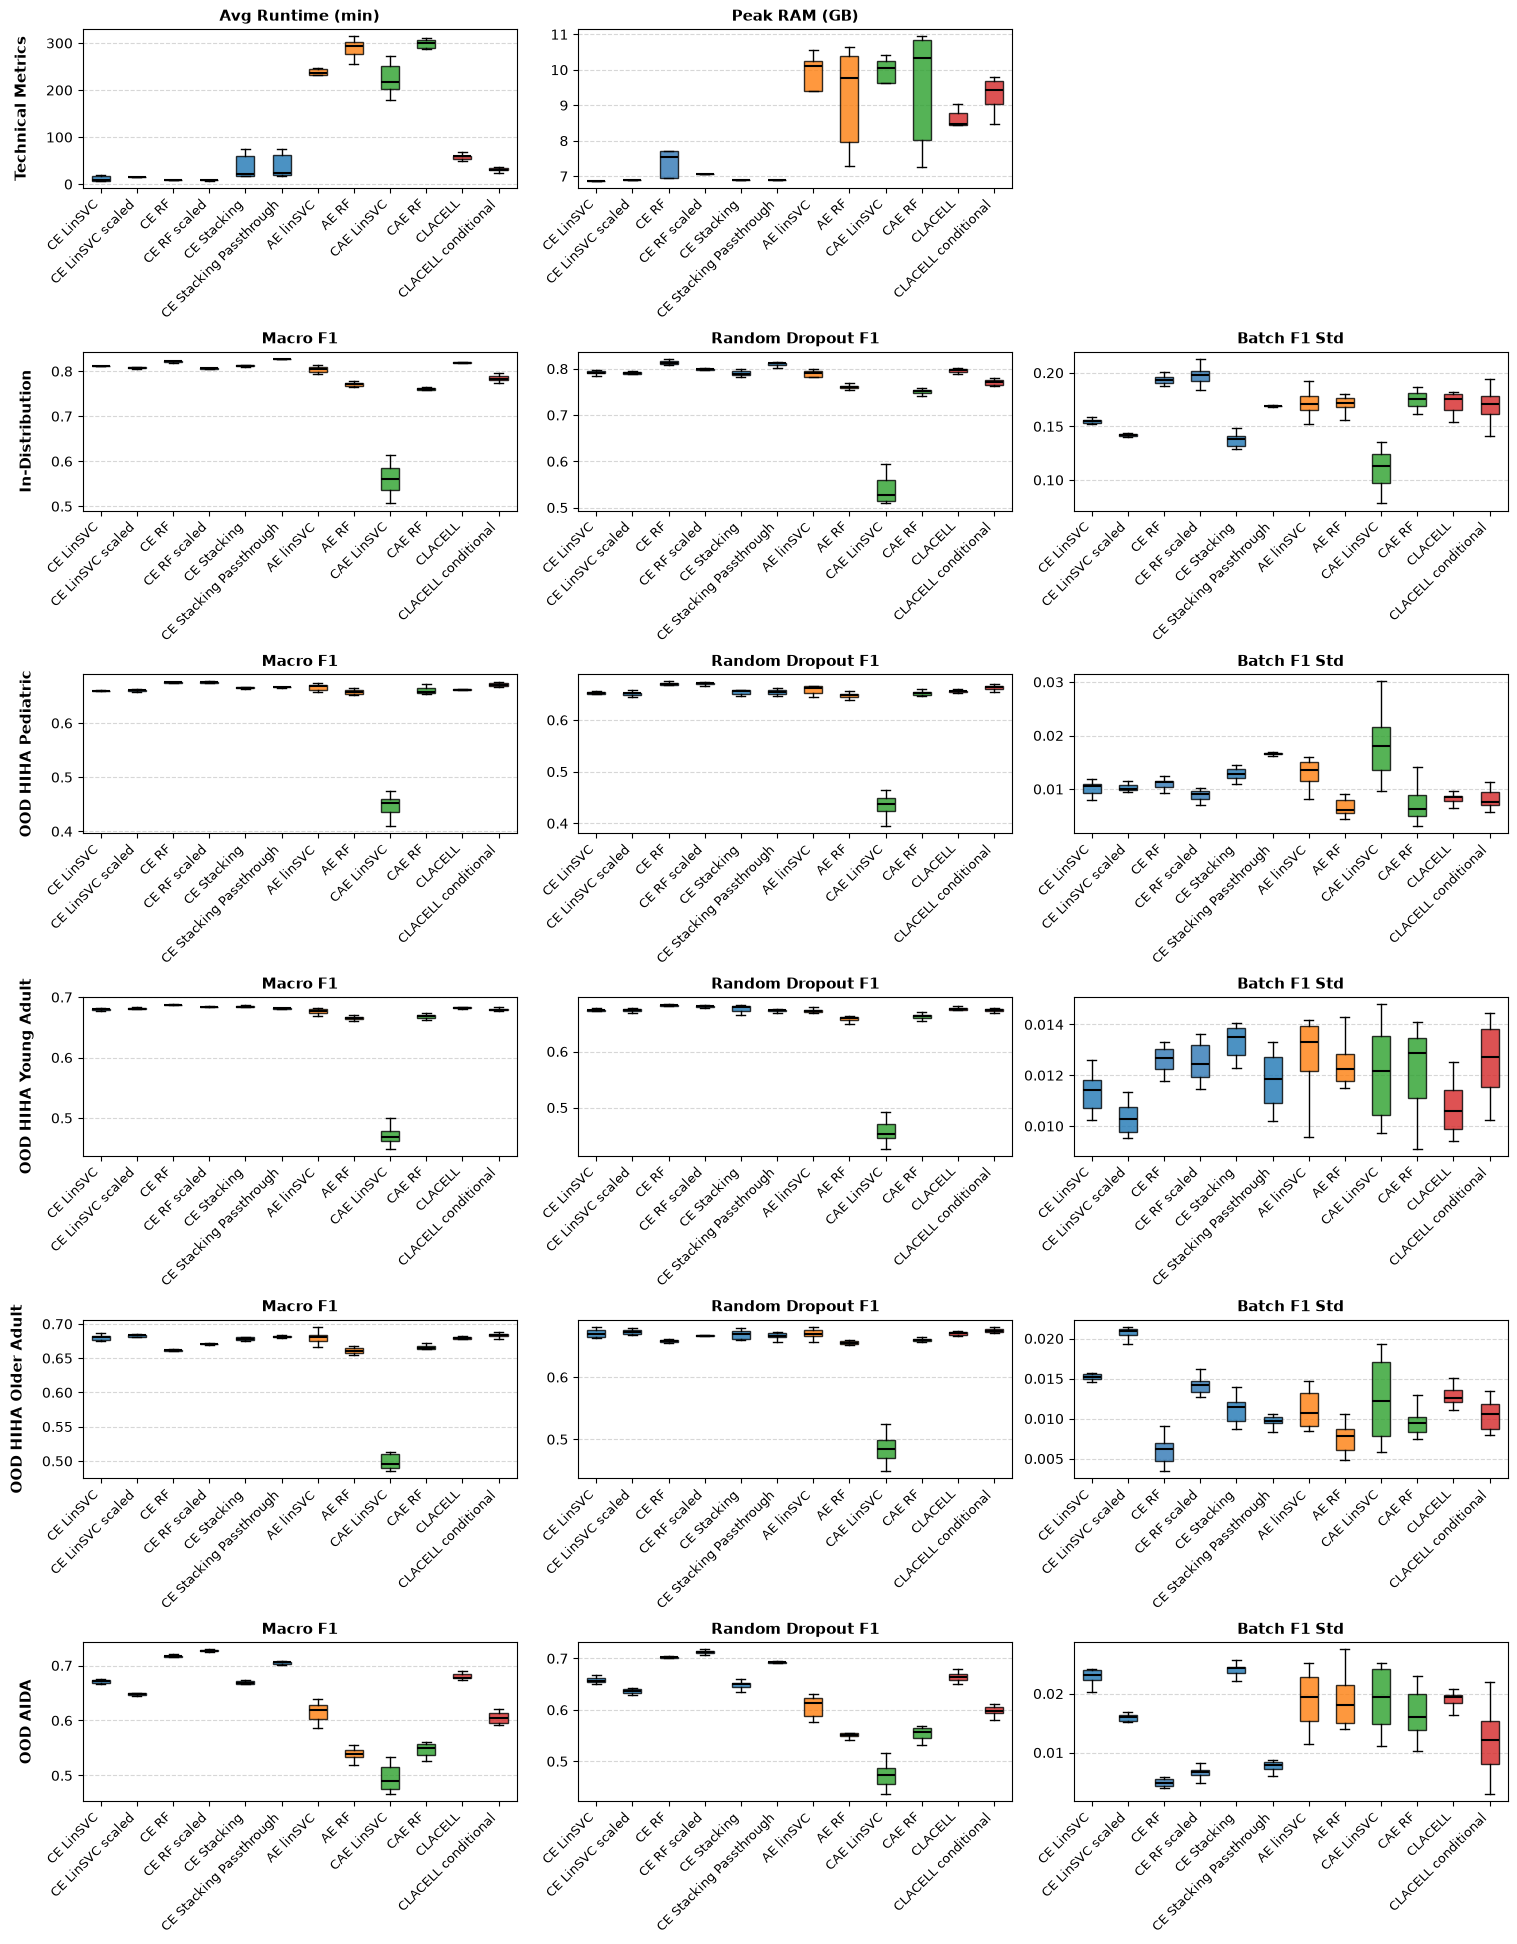

In [3]:
# temporary only with rf, linsvc and extratrees; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'OOD_HIHA_Pediatric', 'OOD_HIHA_Young_Adult', 'OOD_HIHA_Older_Adult', 'OOD_AIDA']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
        # batch_f1_std
        values = df_runs[(distribution, 'Baseline', 'Batch Effect', 'Macro_F1_Std')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc/combined_result.csv'
ce_linsvc_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_scaled/combined_result.csv'
ce_linsvc_stacking_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_stacking/combined_result.csv'
ce_linsvc_stacking_passthrough_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_linsvc_stacking_passthrough/combined_result.csv'
ce_rf_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf/combined_result.csv'
ce_rf_scaled_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/custom_ensemble_rf_scaled/combined_result.csv'
ae_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/autoencoder_linsvc/combined_results.csv'
ae_rf_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/autoencoder_rf/combined_results.csv'
cae_linsvc_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/conditional_autoencoder_linsvc/combined_results.csv'
cae_rf_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/conditional_autoencoder_rf/combined_results.csv'
clacell_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/clacell_complete_pipeline/combined_result.csv'
clacell_conditional_csv_file = '../training/results/mutlitple_ood_datasets/fine_grained_labels/clacell_conditional_bayes_higher_dropout_new_ood/combined_results.csv'
# Offen: combination of cae and ce, clacell complete pipeline

subplot_titles = [
    'Avg Runtime (min)', 'Peak RAM (GB)',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1'
]

# Datensatz-Beschriftungen für den linken Rand jeder Zeile
row_labels = [
    'Technical Metrics',
    'In-Distribution',
    'OOD HIHA Pediatric',
    'OOD HIHA Young Adult',
    'OOD HIHA Older Adult',
    'OOD AIDA'
]

runs_model1 = extract_table_metrics_from_csv(ce_linsvc_csv_file)
runs_model2 = extract_table_metrics_from_csv(ce_linsvc_scaled_csv_file)
runs_model3 = extract_table_metrics_from_csv(ce_rf_csv_file)
runs_model4 = extract_table_metrics_from_csv(ce_rf_scaled_csv_file)
runs_model11 = extract_table_metrics_from_csv(ce_linsvc_stacking_csv_file)
runs_model21 = extract_table_metrics_from_csv(ce_linsvc_stacking_passthrough_csv_file)
runs_model5 = extract_table_metrics_from_csv(ae_linsvc_csv_file)
runs_model6 = extract_table_metrics_from_csv(ae_rf_csv_file)
runs_model7 = extract_table_metrics_from_csv(cae_linsvc_csv_file)
runs_model8 = extract_table_metrics_from_csv(cae_rf_csv_file)
runs_model9 = extract_table_metrics_from_csv(clacell_csv_file)
runs_model10 = extract_table_metrics_from_csv(clacell_conditional_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['CE LinSVC', 'CE LinSVC scaled', 'CE RF', 'CE RF scaled', 'CE Stacking', 'CE Stacking Passthrough', 'AE linSVC', 'AE RF', 'CAE LinSVC', 'CAE RF', 'CLACELL', 'CLACELL conditional']
colors = ['#1f77b4', '#1e77b4', '#2f77b4', '#2e77b4', '#1f77b4', '#1e77b4', '#ff7f0e', '#fd7f0e', '#2ca02c', '#2aa02c', '#d62728', '#d42728']

# Grid mit 6 Zeilen und 3 Spalten
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20), sharey=False)

# Entferne das leere 3. Feld in der ersten Zeile (Zeile 0, Spalte 2)
fig.delaxes(axes[0, 2])

data_idx = 0  # Fortlaufender Index für die 17 Metriken in data_for_boxplot

for row in range(6):
    # Zeile 0 hat nur 2 Subplots, Zeilen 1-5 haben jeweils 3 Subplots
    num_cols = 2 if row == 0 else 3
    
    for col in range(num_cols):
        ax = axes[row, col]
        
        # Titel je nach Spalte und Zeile festlegen
        if row == 0:
            metric_title = 'Avg Runtime (min)' if col == 0 else 'Peak RAM (GB)'
        else:
            titles_per_row = ['Macro F1', 'Random Dropout F1', 'Batch F1 Std']
            metric_title = titles_per_row[col]
            
        # Daten für genau diesen Plot zusammenstellen
        metric_data = [
            runs_model1[data_idx],
            runs_model2[data_idx],
            runs_model3[data_idx],
            runs_model4[data_idx],
            runs_model11[data_idx],
            runs_model21[data_idx],
            runs_model5[data_idx],
            runs_model6[data_idx],
            runs_model7[data_idx],
            runs_model8[data_idx],
            runs_model9[data_idx],
            runs_model10[data_idx]
        ]
        
        # Boxplot zeichnen
        bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
        
        # Farben anwenden
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            
        # Mediane schwarz markieren
        for median in bplot['medians']:
            median.set(color='black', linewidth=1.5)
            
        # Subplot-Titel setzen
        ax.set_title(metric_title, fontsize=11, weight='bold')
        
        # Zeilenbeschriftung ganz links am Rand
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, weight='bold', labelpad=12)
            
        # X-Achsen Beschriftung
        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        
        # Y-Achsen-Begrenzung für F1/Dropout-Werte in den Testdatensätzen
        if row > 0:
            bottom, top = ax.get_ylim()
            ax.set_ylim(bottom, min(1.05, top))
            
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        data_idx += 1

# Layout anpassen
plt.tight_layout()
fig.subplots_adjust(top=0.96, left=0.10)

#plt.savefig('figures/cae_ce_scaled_comparison_table_metrics_box_plot.png')
plt.show()

### Reference Models

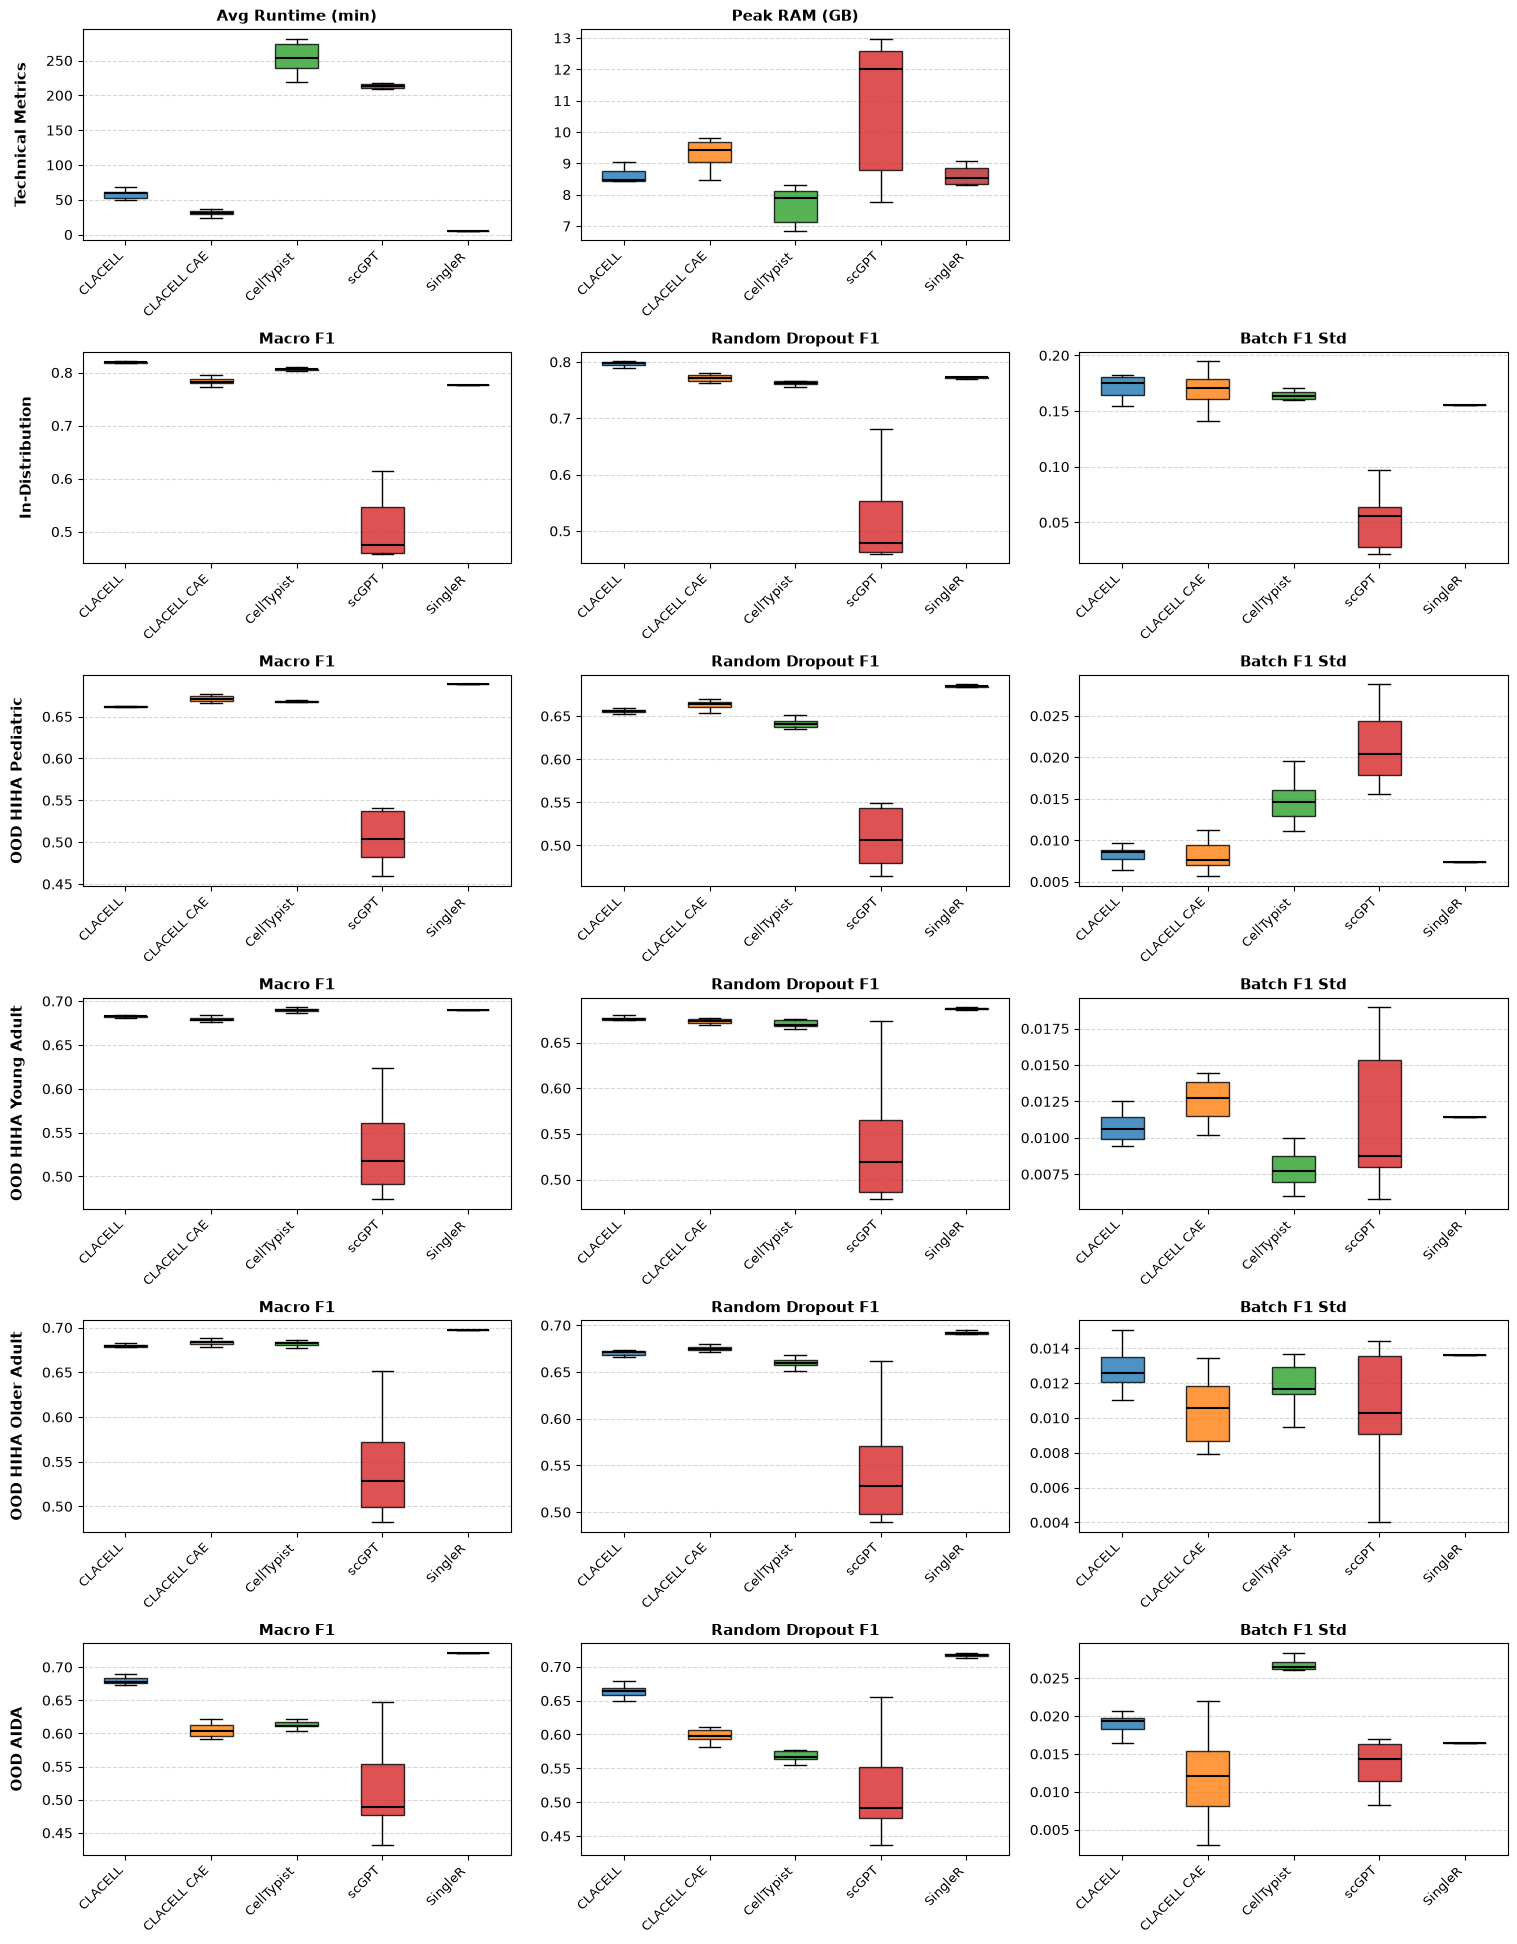

In [8]:
# temporary only with rf, linsvc and extratrees; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution', 'OOD_HIHA_Pediatric', 'OOD_HIHA_Young_Adult', 'OOD_HIHA_Older_Adult', 'OOD_AIDA']:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
        # batch_f1_std
        values = df_runs[(distribution, 'Baseline', 'Batch Effect', 'Macro_F1_Std')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
celltypist_csv_file = '../training/results/mutlitple_ood_datasets/celltypist_current_python/combined_results.csv'
scgpt_csv_file = '../training/results/mutlitple_ood_datasets/scgpt/combined_results.csv'
singler_csv_file = '../training/results/mutlitple_ood_datasets/singler/combined_result.csv'

clacell_csv_file = '../training/results/mutlitple_ood_datasets/clacell_complete_pipeline/combined_result.csv'
clacell_conditional_csv_file = '../training/results/mutlitple_ood_datasets/clacell_conditional_bayes_higher_dropout_new_ood/combined_results.csv'

subplot_titles = [
    'Avg Runtime (min)', 'Peak RAM (GB)',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1',
    'Macro F1', 'Random Dropout F1'
]

# Datensatz-Beschriftungen für den linken Rand jeder Zeile
row_labels = [
    'Technical Metrics',
    'In-Distribution',
    'OOD HIHA Pediatric',
    'OOD HIHA Young Adult',
    'OOD HIHA Older Adult',
    'OOD AIDA'
]

runs_model1 = extract_table_metrics_from_csv(clacell_csv_file)
runs_model2 = extract_table_metrics_from_csv(clacell_conditional_csv_file)

runs_model3 = extract_table_metrics_from_csv(celltypist_csv_file)
runs_model4 = extract_table_metrics_from_csv(scgpt_csv_file)
runs_model5 = extract_table_metrics_from_csv(singler_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['CLACELL', 'CLACELL CAE', 'CellTypist', 'scGPT', 'SingleR']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#b62728']

# Grid mit 6 Zeilen und 3 Spalten
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20), sharey=False)

# Entferne das leere 3. Feld in der ersten Zeile (Zeile 0, Spalte 2)
fig.delaxes(axes[0, 2])

data_idx = 0  # Fortlaufender Index für die 17 Metriken in data_for_boxplot

for row in range(6):
    # Zeile 0 hat nur 2 Subplots, Zeilen 1-5 haben jeweils 3 Subplots
    num_cols = 2 if row == 0 else 3
    
    for col in range(num_cols):
        ax = axes[row, col]
        
        # Titel je nach Spalte und Zeile festlegen
        if row == 0:
            metric_title = 'Avg Runtime (min)' if col == 0 else 'Peak RAM (GB)'
        else:
            titles_per_row = ['Macro F1', 'Random Dropout F1', 'Batch F1 Std']
            metric_title = titles_per_row[col]
            
        # Daten für genau diesen Plot zusammenstellen
        metric_data = [
            runs_model1[data_idx],
            runs_model2[data_idx],
            runs_model3[data_idx],
            runs_model4[data_idx],
            runs_model5[data_idx]
        ]
        
        # Boxplot zeichnen
        bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
        
        # Farben anwenden
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            
        # Mediane schwarz markieren
        for median in bplot['medians']:
            median.set(color='black', linewidth=1.5)
            
        # Subplot-Titel setzen
        ax.set_title(metric_title, fontsize=11, weight='bold')
        
        # Zeilenbeschriftung ganz links am Rand
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, weight='bold', labelpad=12)
            
        # X-Achsen Beschriftung
        ax.set_xticks(range(1, len(models) + 1))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        
        # Y-Achsen-Begrenzung für F1/Dropout-Werte in den Testdatensätzen
        if row > 0:
            bottom, top = ax.get_ylim()
            ax.set_ylim(bottom, min(1.05, top))
            
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        data_idx += 1

# Layout anpassen
plt.tight_layout()
fig.subplots_adjust(top=0.96, left=0.10)

plt.savefig('figures/reference_comparison_table_metrics_box_plot.png')
plt.show()

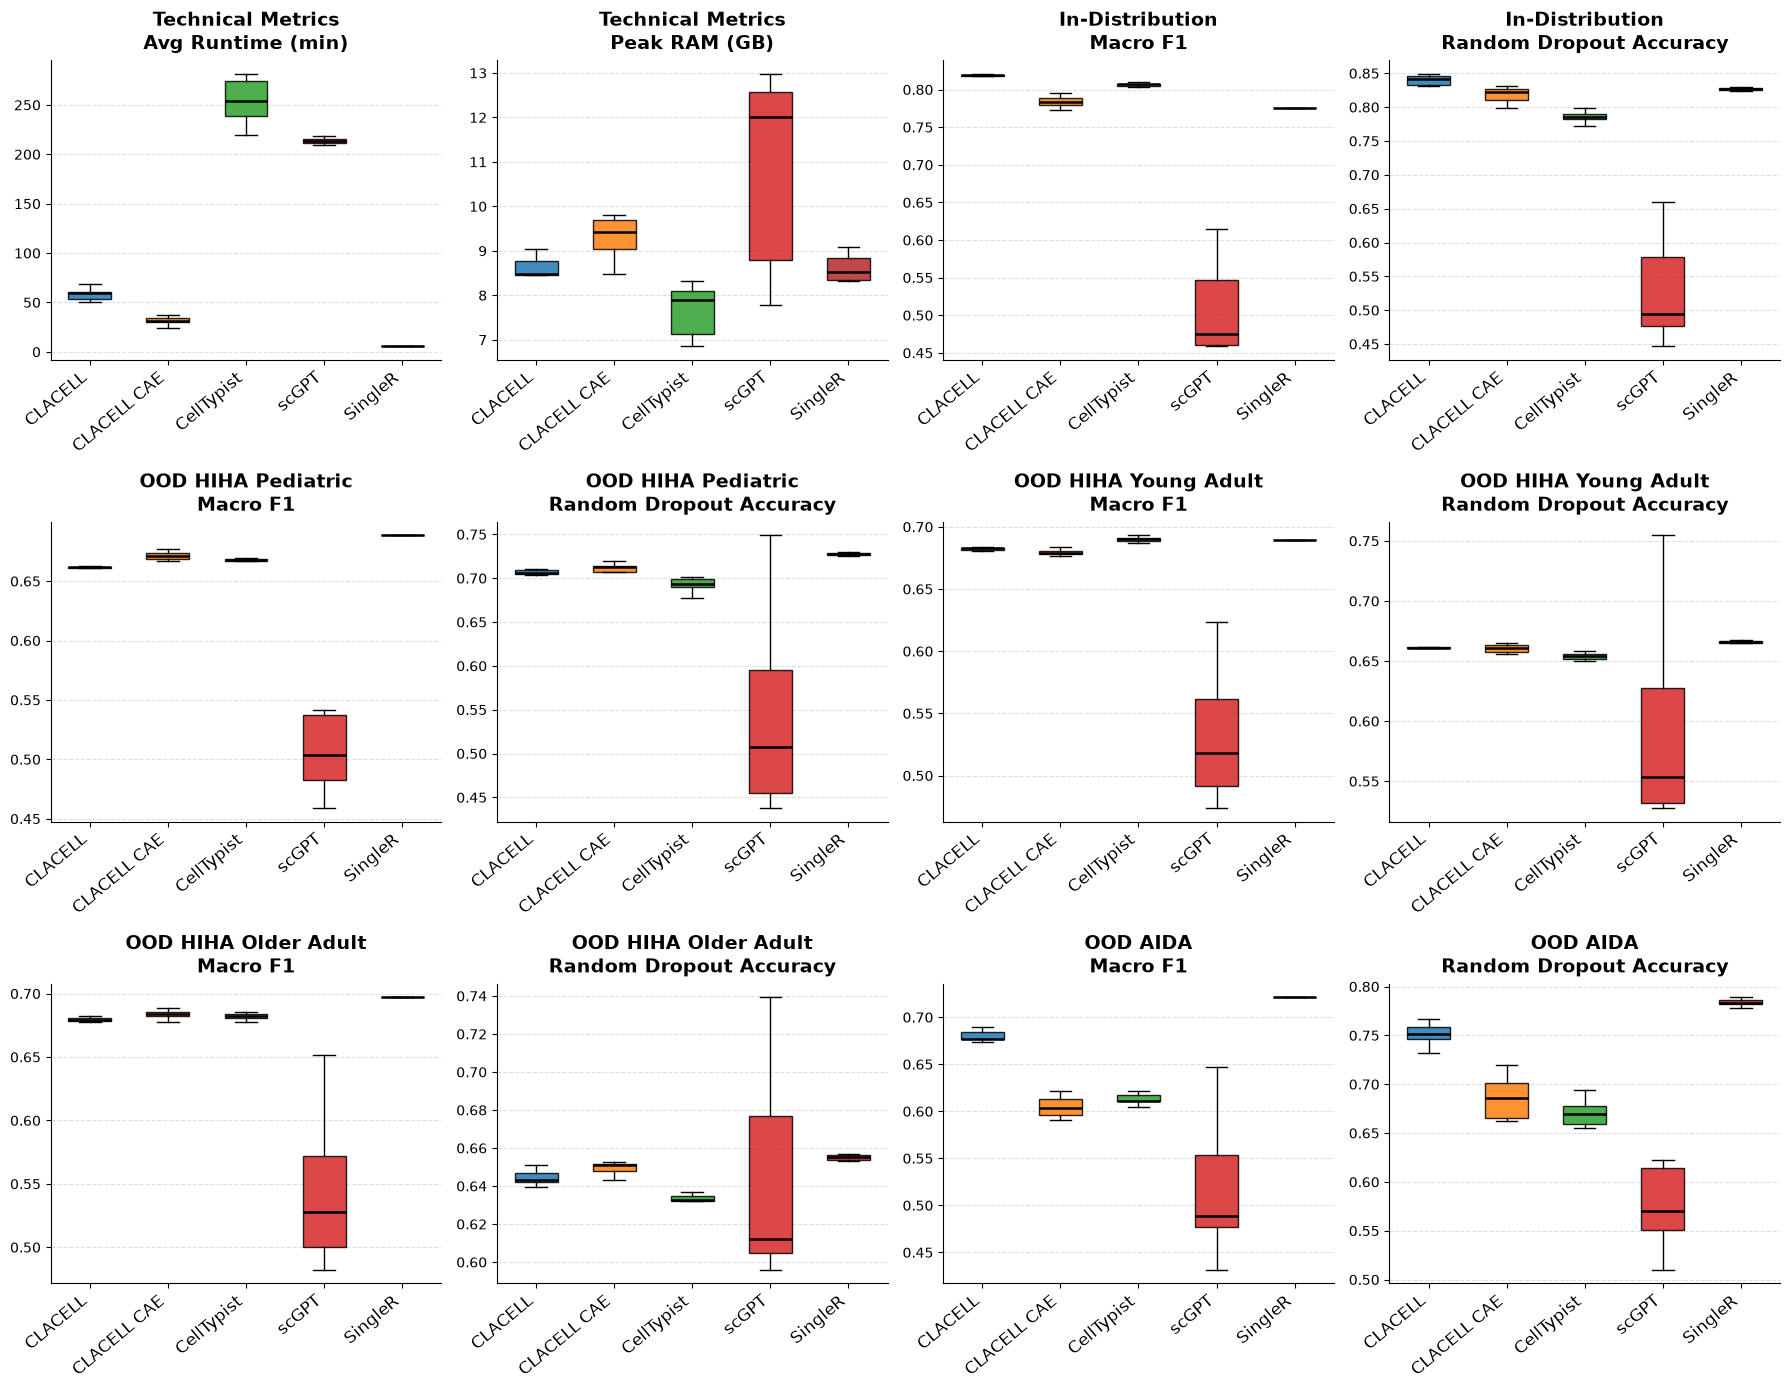

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp. Die Batch-Effekt-Metrik wird übersprungen.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9)
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    
    # Technical Metrics (2 Metriken)
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # Distribution Metrics (5 Datensätze * 2 Metriken = 10 Metriken)
    distributions = [
        'In-Distribution', 
        'OOD_HIHA_Pediatric', 
        'OOD_HIHA_Young_Adult', 
        'OOD_HIHA_Older_Adult', 
        'OOD_AIDA'
    ]
    
    for distribution in distributions:
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout
        values = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
celltypist_csv_file = '../training/results/mutlitple_ood_datasets/celltypist_current_python/combined_results.csv'
scgpt_csv_file = '../training/results/mutlitple_ood_datasets/scgpt/combined_results.csv'
singler_csv_file = '../training/results/mutlitple_ood_datasets/singler/combined_result.csv'

clacell_csv_file = '../training/results/mutlitple_ood_datasets/clacell_complete_pipeline/combined_result.csv'
clacell_conditional_csv_file = '../training/results/mutlitple_ood_datasets/clacell_conditional_bayes_higher_dropout_new_ood/combined_results.csv'

runs_model1 = extract_table_metrics_from_csv(clacell_csv_file)
runs_model2 = extract_table_metrics_from_csv(clacell_conditional_csv_file)
runs_model3 = extract_table_metrics_from_csv(celltypist_csv_file)
runs_model4 = extract_table_metrics_from_csv(scgpt_csv_file)
runs_model5 = extract_table_metrics_from_csv(singler_csv_file)

# Konfiguration der 12 Subplots für das 2x6 Grid
plot_configs = [
    {'dataset': 'Technical Metrics', 'title': 'Avg Runtime (min)'},
    {'dataset': 'Technical Metrics', 'title': 'Peak RAM (GB)'},
    {'dataset': 'In-Distribution', 'title': 'Macro F1'},
    {'dataset': 'In-Distribution', 'title': 'Random Dropout Accuracy'},
    {'dataset': 'OOD HIHA Pediatric', 'title': 'Macro F1'},
    {'dataset': 'OOD HIHA Pediatric', 'title': 'Random Dropout Accuracy'},
    {'dataset': 'OOD HIHA Young Adult', 'title': 'Macro F1'},
    {'dataset': 'OOD HIHA Young Adult', 'title': 'Random Dropout Accuracy'},
    {'dataset': 'OOD HIHA Older Adult', 'title': 'Macro F1'},
    {'dataset': 'OOD HIHA Older Adult', 'title': 'Random Dropout Accuracy'},
    {'dataset': 'OOD AIDA', 'title': 'Macro F1'},
    {'dataset': 'OOD AIDA', 'title': 'Random Dropout Accuracy'}
]

models = ['CLACELL', 'CLACELL CAE', 'CellTypist', 'scGPT', 'SingleR']
# Farbschema: Violett (#9467bd) für SingleR gewählt, damit es nicht mit scGPT (Rot) verwechselt wird
#colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#b62728']

# --- 2. BOXPLOT ZEICHNEN (2 ZEILEN x 6 SPALTEN) ---
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 14), sharey=False)

for idx, config in enumerate(plot_configs):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    # Daten für genau diesen Subplot zusammenstellen
    metric_data = [
        runs_model1[idx],
        runs_model2[idx],
        runs_model3[idx],
        runs_model4[idx],
        runs_model5[idx]
    ]
    
    # Boxplot zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.55)
    
    # Farben anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_linewidth(1.0)
        
    # Mediane markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.8)
        
    # Titel mit Datensatz & Metrik (Poster-optimiert)
    ax.set_title(f"{config['dataset']}\n{config['title']}", fontsize=14, weight='bold', pad=8)
    
    # X-Achse
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=12)
    
    # Y-Achse dynamisch anpassen (Untergrenze automatisch, Obergrenze maximal 1.05)
    if idx >= 2:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
        
    # Styling-Details für Poster-Optik
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# Hohe Auflösung für Posterdruck
plt.savefig('figures/poster_reference_comparison_table_metrics_box_plot.png', dpi=300, bbox_inches='tight')
plt.show()

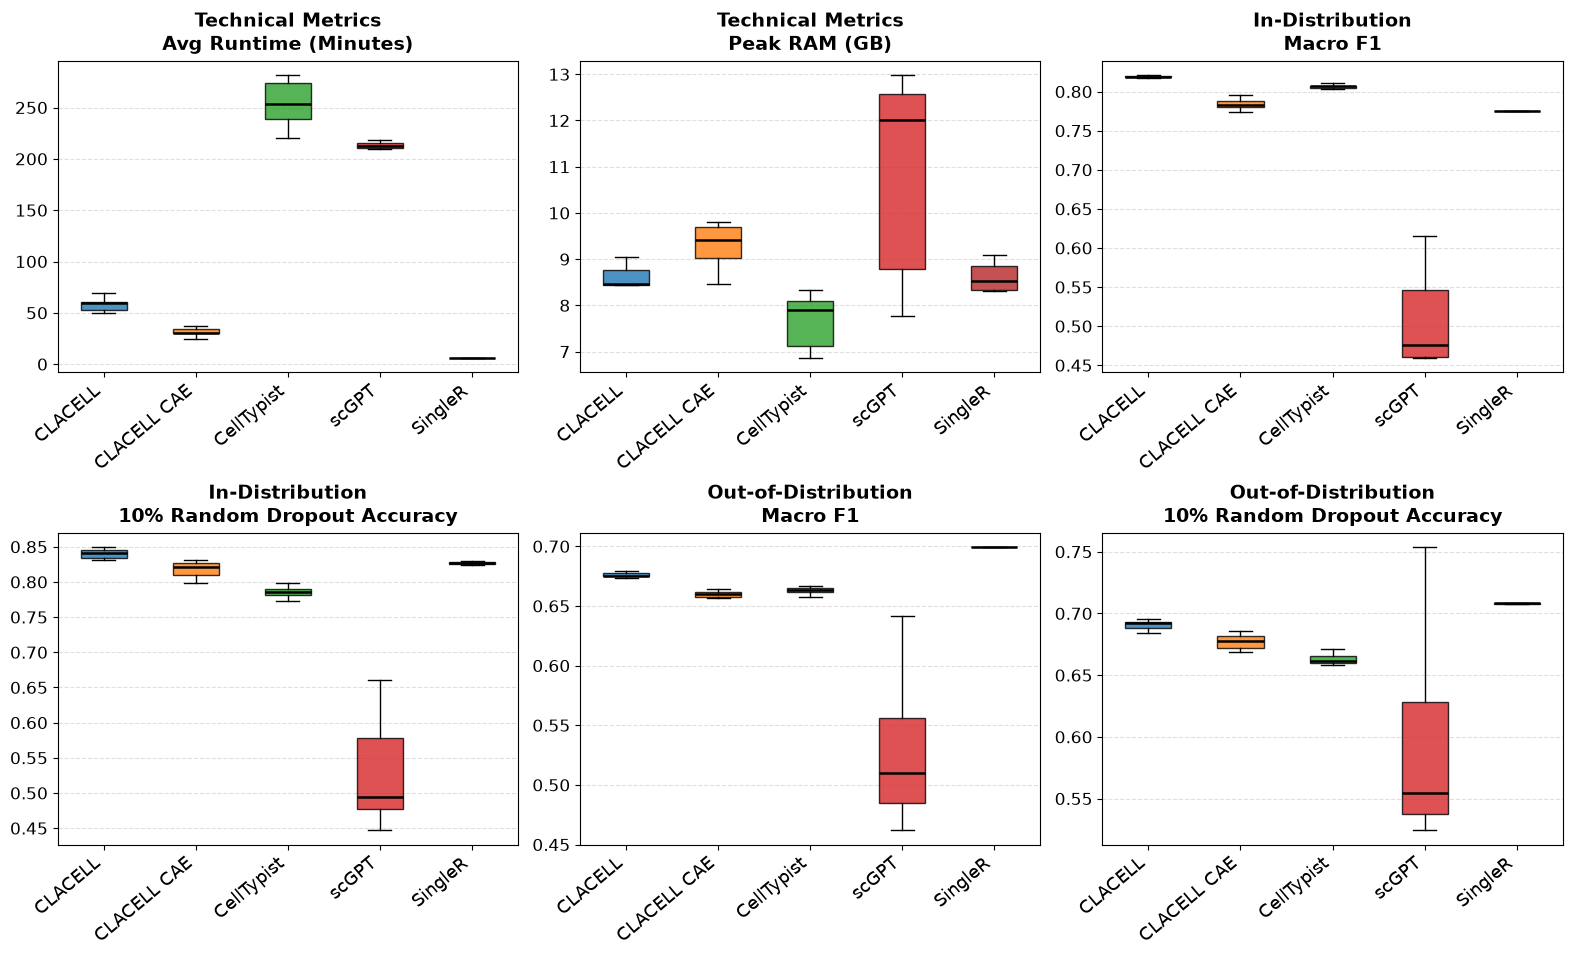

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs).
    Gemittelt werden die Werte der 4 OOD-Datensätze pro Run.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9)
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    
    # 1 & 2: Technical Metrics
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 3 & 4: In-Distribution Metrics
    values = df_runs[('In-Distribution', 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    values = df_runs[('In-Distribution', 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
    data_for_boxplot.append(values)
    
    # 5 & 6: OOD Metrics (Mittelwert über die 4 OOD-Datensätze pro Run)
    ood_distributions = [
        'OOD_HIHA_Pediatric', 
        'OOD_HIHA_Young_Adult', 
        'OOD_HIHA_Older_Adult', 
        'OOD_AIDA'
    ]
    
    ood_f1_list = []
    ood_dropout_list = []
    
    for distribution in ood_distributions:
        f1_vals = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).values
        dropout_vals = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).values
        ood_f1_list.append(f1_vals)
        ood_dropout_list.append(dropout_vals)
        
    # Mittelwert über die 4 OOD-Datensätze pro Run berechnen
    avg_ood_f1 = np.mean(ood_f1_list, axis=0).tolist()
    avg_ood_dropout = np.mean(ood_dropout_list, axis=0).tolist()
    
    data_for_boxplot.append(avg_ood_f1)
    data_for_boxplot.append(avg_ood_dropout)
    
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
celltypist_csv_file = '../training/results/mutlitple_ood_datasets/celltypist_current_python/combined_results.csv'
scgpt_csv_file = '../training/results/mutlitple_ood_datasets/scgpt/combined_results.csv'
singler_csv_file = '../training/results/mutlitple_ood_datasets/singler/combined_result.csv'

clacell_csv_file = '../training/results/mutlitple_ood_datasets/clacell_complete_pipeline/combined_result.csv'
clacell_conditional_csv_file = '../training/results/mutlitple_ood_datasets/clacell_conditional_bayes_higher_dropout_new_ood/combined_results.csv'

runs_model1 = extract_table_metrics_from_csv(clacell_csv_file)
runs_model2 = extract_table_metrics_from_csv(clacell_conditional_csv_file)
runs_model3 = extract_table_metrics_from_csv(celltypist_csv_file)
runs_model4 = extract_table_metrics_from_csv(scgpt_csv_file)
runs_model5 = extract_table_metrics_from_csv(singler_csv_file)

# Konfiguration der 6 Subplots (2 Zeilen x 3 Spalten)
plot_configs = [
    {'dataset': 'Technical Metrics', 'title': 'Avg Runtime (Minutes)'},
    {'dataset': 'Technical Metrics', 'title': 'Peak RAM (GB)'},
    {'dataset': 'In-Distribution', 'title': 'Macro F1'},
    {'dataset': 'In-Distribution', 'title': '10% Random Dropout Accuracy'},
    {'dataset': 'Out-of-Distribution', 'title': 'Macro F1'},
    {'dataset': 'Out-of-Distribution', 'title': '10% Random Dropout Accuracy'}
]

models = ['CLACELL', 'CLACELL CAE', 'CellTypist', 'scGPT', 'SingleR']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#b62728']

# --- 2. BOXPLOT ZEICHNEN (2 ZEILEN x 3 SPALTEN) ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharey=False)

for idx, config in enumerate(plot_configs):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Daten für genau diesen Subplot zusammenstellen
    metric_data = [
        runs_model1[idx],
        runs_model2[idx],
        runs_model3[idx],
        runs_model4[idx],
        runs_model5[idx]
    ]
    
    # Boxplot zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        #patch.set_linewidth(1.0)
        
    # Mediane markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.8)
        
    # Titel mit Datensatz & Metrik (Poster-optimiert)
    ax.set_title(f"{config['dataset']}\n{config['title']}", fontsize=14, weight='bold', pad=8)
    
    # X-Achse
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(models, rotation=40, ha='right', fontsize=13)
    
    # Y-Achse dynamisch anpassen (Untergrenze automatisch, Obergrenze maximal 1.05 für F1/Accuracy)
    if idx >= 2:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
        
    # Styling-Details für Poster-Optik
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='y', labelsize=12)
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

# Hohe Auflösung für Posterdruck
plt.savefig('figures/poster_reference_comparison_table_metrics_box_plot.png', dpi=600, bbox_inches='tight')
plt.show()

### Spatial Data

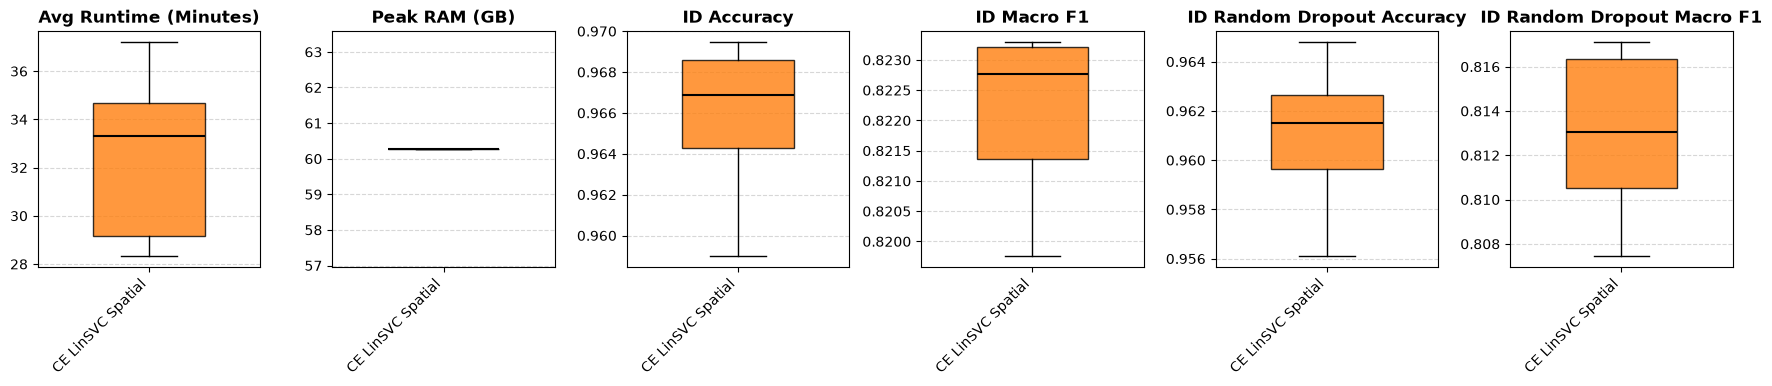

In [8]:
# temporary only with linsvc; comparison with scaled
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_table_metrics_from_csv(csv_path):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    # Avg Runtime
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Total_Pipeline_Time_Min')].astype(float).tolist()
    data_for_boxplot.append(values)
    # RAM Peak
    values = df_runs[('All', 'Technical_Metrics', 'Resource_Usage', 'Peak_RAM_GB')].astype(float).tolist()
    data_for_boxplot.append(values)
    for distribution in ['In-Distribution']:
        # Accuracy
        values = df_runs[(distribution, 'Baseline', 'Overall', 'Accuracy')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Macro F1
        values = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout Accuracy
        values = df_runs[(distribution, 'Dropout', 'Random', 'Accuracy')].astype(float).tolist()
        data_for_boxplot.append(values)
        # Random Dropout Macro F1
        values = df_runs[(distribution, 'Dropout', 'Random', 'Macro_F1')].astype(float).tolist()
        data_for_boxplot.append(values)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_linsvc_csv_file = '../training/results/new2/custom_ensemble_linsvc_spatial_ovary/combined_result.csv'

subplot_titles = ['Avg Runtime (Minutes)', 'Peak RAM (GB)', 'ID Accuracy', 'ID Macro F1', 'ID Random Dropout Accuracy', 'ID Random Dropout Macro F1']

runs_model1 = extract_table_metrics_from_csv(ce_linsvc_csv_file)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['CE LinSVC Spatial']
colors = ['#ff7f0e']

# Erstelle ein 2x4 Grid mit unabhängigen Y-Achsen (sharey=False)
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(18, 4), sharey=False)
axes = axes.flatten()  # Macht aus dem 2D-Array der Axes ein 1D-Array für leichteres Iterieren

for i, metric in enumerate(subplot_titles):
    ax = axes[i]
    
    # Die Daten der 4 Modelle für genau diesen einen Zelltyp zusammenstellen
    metric_data = [
        runs_model1[i],
    ]
    
    # Boxplot für diesen Zelltyp zeichnen
    bplot = ax.boxplot(metric_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben aus der Liste anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        
    # Mediane schwarz markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Subplot-Design
    ax.set_title(subplot_titles[i], fontsize=12, weight='bold')
    
    # Beschriftung der X-Achse (Modellnamen um 45 Grad gedreht für Platz)
    ax.set_xticks([1])
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    
    # Y-Achse intelligent limitieren (Maximal 1.05, Minimum passt sich den Daten an)
    if "F1" in metric or "Dropout" in metric:
        bottom, top = ax.get_ylim()
        ax.set_ylim(bottom, min(1.05, top))
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Globale Titel und Achsenbeschriftung
#fig.suptitle('Overview of Performance of Reference Models over 10 Runs', fontsize=18, weight='bold')
#fig.text(0.01, 0.5, 'F1-Score', va='center', rotation='vertical', fontsize=14, weight='bold')

# Layout bereinigen
plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

plt.savefig('figures/spatial_comparison_table_metrics_box_plot.png')
plt.show()

## Feature Importance Dropout

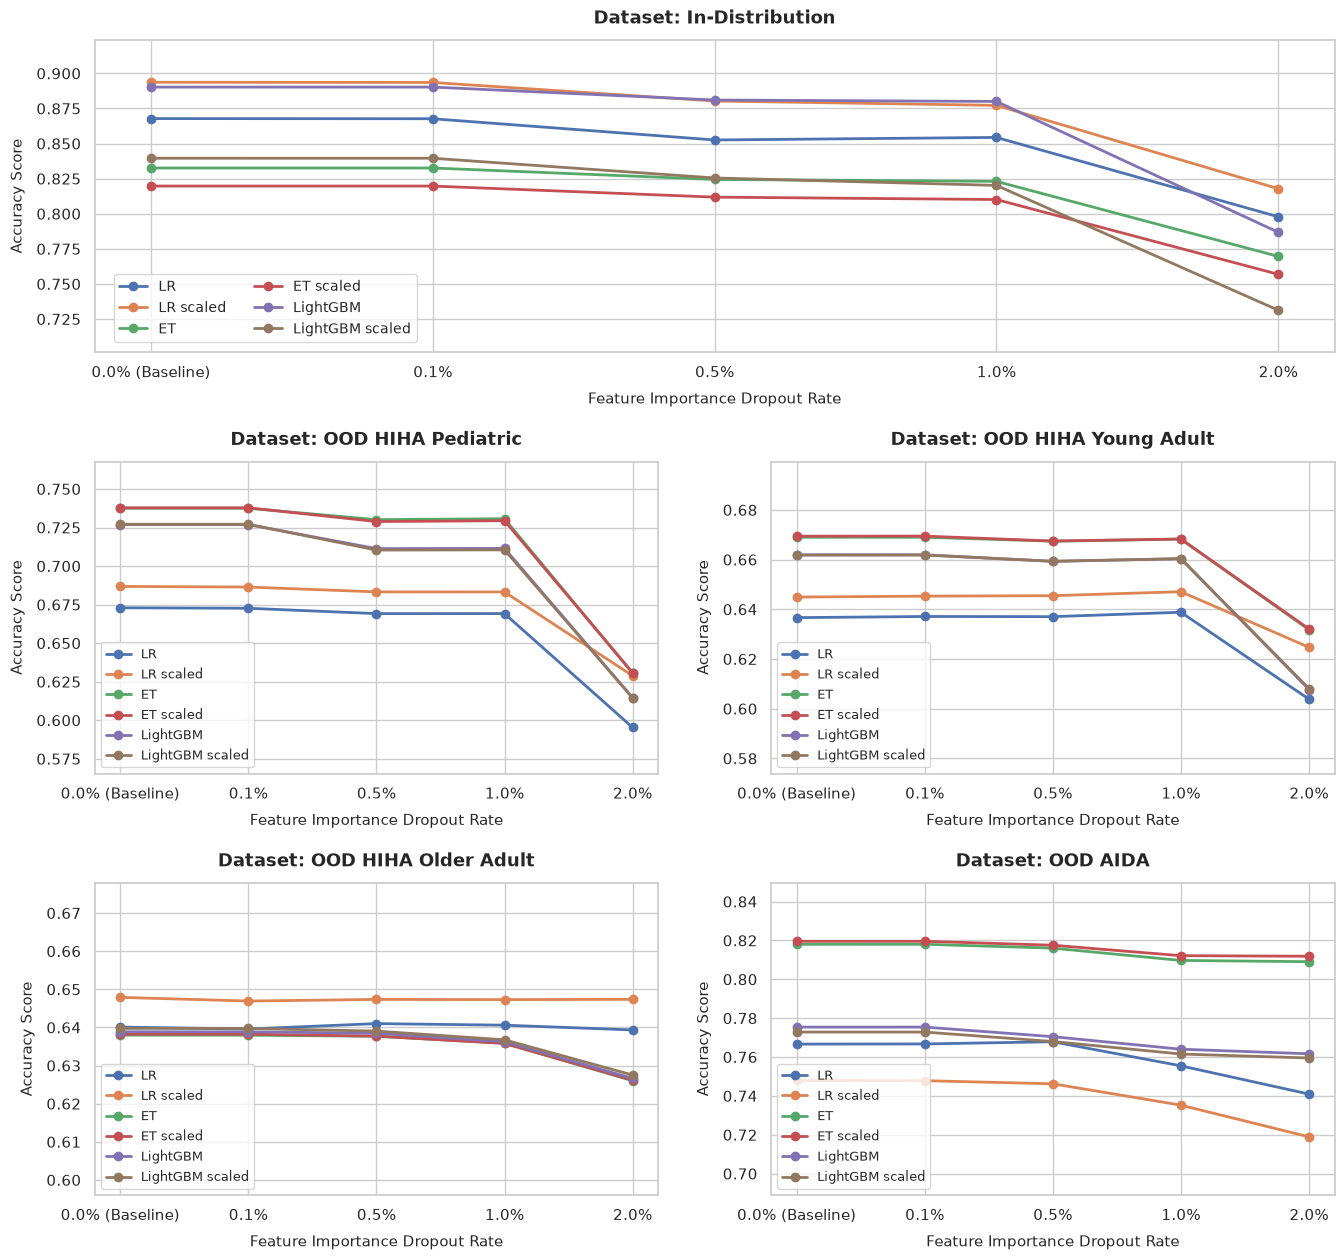

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Theme setzen
sns.set_theme(style="whitegrid")

# --- 1. FUNKTION ZUM AUSLESEN DER DROPOUT-METRIKEN ---
def extract_dropout_accuracies(csv_path, distribution, dropout_rates=['0.1%', '0.5%', '1.0%', '2.0%']):
    """
    Lädt die CSV und berechnet den Mittelwert der Accuracy über die ersten 10 Runs
    für die Baseline (0.0%) sowie für verschiedene Feature Importance Dropout-Raten.
    """
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    df_runs = df.iloc[:10]
    
    accuracies = []
    
    # 1. Baseline (0.0% Dropout) auslesen
    baseline_acc = df_runs[(distribution, 'Baseline', 'Overall', 'Accuracy')].astype(float).mean()
    accuracies.append(baseline_acc)
        
    # 2. Accuracy für die einzelnen Feature Importance Dropout-Raten auslesen
    for rate in dropout_rates:
        col_path = (distribution, 'Dropout', f'FI_{rate}', 'Accuracy')
        acc = df_runs[col_path].astype(float).mean()
        accuracies.append(acc)
        
    return accuracies


# --- 2. MODELL-PFADE & DATENSÄTZE DEFINIEREN ---
model_paths = {
    'LR': '../training/results/mutlitple_ood_datasets/logisticregression/combined_results.csv',
    'LR scaled': '../training/results/mutlitple_ood_datasets/logisticregression_scaled/combined_results.csv',
    #'LinearSVC': '../training/results/mutlitple_ood_datasets/linearsvc/combined_result.csv',
    #'LinearSVC scaled': '../training/results/mutlitple_ood_datasets/linearsvc_scaled/combined_result.csv',
    #'RF': '../training/results/mutlitple_ood_datasets/randomforest/combined_result.csv',
    #'RF scaled': '../training/results/mutlitple_ood_datasets/randomforest_scaled/combined_result.csv',
    'ET': '../training/results/mutlitple_ood_datasets/extratrees/combined_result.csv',
    'ET scaled': '../training/results/mutlitple_ood_datasets/extratrees_scaled/combined_result.csv',
    'LightGBM': '../training/results/mutlitple_ood_datasets/lightgbm/combined_results.csv',
    'LightGBM scaled': '../training/results/mutlitple_ood_datasets/lightgbm_scaled/combined_results.csv',
}

dropout_rates = ['0.0% (Baseline)', '0.1%', '0.5%', '1.0%', '2.0%']
dropout_keys = ['0.1%', '0.5%', '1.0%', '2.0%']

# Zu plottende Datensätze definieren (1x ID + 4x OOD)
distributions = {
    'In-Distribution': 'In-Distribution',
    'OOD_HIHA_Pediatric': 'OOD HIHA Pediatric',
    'OOD_HIHA_Young_Adult': 'OOD HIHA Young Adult',
    'OOD_HIHA_Older_Adult': 'OOD HIHA Older Adult',
    'OOD_AIDA': 'OOD AIDA'
}


# --- 3. DATEN DYNAMISCH AUS DEN CSVs EXTRAHIEREN ---
data = {dist_key: {} for dist_key in distributions.keys()}

for model_name, csv_path in model_paths.items():
    try:
        for dist_key in distributions.keys():
            data[dist_key][model_name] = extract_dropout_accuracies(csv_path, dist_key, dropout_keys)
    except FileNotFoundError:
        print(f"Datei nicht gefunden: {csv_path}. Überspringe Modell '{model_name}'.")


# --- 4. GRID LAYOUT ERSTELLEN (3 Zeilen, 2 Spalten) ---
fig = plt.figure(figsize=(16, 15), dpi=100)
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.2)

# Subplots zuweisen
ax_id = fig.add_subplot(gs[0, :])         # Zeile 1: Volle Breite über beide Spalten
ax_ood1 = fig.add_subplot(gs[1, 0])       # Zeile 2, links
ax_ood2 = fig.add_subplot(gs[1, 1])       # Zeile 2, rechts
ax_ood3 = fig.add_subplot(gs[2, 0])       # Zeile 3, links
ax_ood4 = fig.add_subplot(gs[2, 1])       # Zeile 3, rechts

subplot_mapping = [
    ('In-Distribution', ax_id),
    ('OOD_HIHA_Pediatric', ax_ood1),
    ('OOD_HIHA_Young_Adult', ax_ood2),
    ('OOD_HIHA_Older_Adult', ax_ood3),
    ('OOD_AIDA', ax_ood4)
]


# --- 5. SUBPLOTS BEFÜLLEN ---
for dist_key, ax in subplot_mapping:
    title_name = distributions[dist_key]
    dist_data = data[dist_key]
    
    for model_name, accuracies in dist_data.items():
        ax.plot(dropout_rates, accuracies, marker='o', linewidth=2.0, markersize=6, label=model_name)

    ax.set_xlabel('Feature Importance Dropout Rate', fontsize=11, labelpad=8)
    ax.set_ylabel('Accuracy Score', fontsize=11, labelpad=8)
    ax.set_title(f'Dataset: {title_name}', fontsize=13, fontweight='bold', pad=12)

    # Y-Limits dynamisch anpassen
    all_values = [val for accs in dist_data.values() for val in accs if not np.isnan(val)]
    if all_values:
        ax.set_ylim(min(all_values) - 0.03, max(all_values) + 0.03)

    # Legende nur beim ersten Subplot anzeigen (oder optional auslagern)
    if dist_key == 'In-Distribution':
        ax.legend(loc='lower left', bbox_to_anchor=(0.01, 0.01), fontsize=10, frameon=True, ncol=2)
    else:
        ax.legend(loc='lower left', fontsize=9, frameon=True)

#plt.savefig('figures/ml_fi_importance_5_subplots.png', bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Theme setzen
sns.set_theme(style="whitegrid")

# --- 1. FUNKTION ZUM AUSLESEN DER DROPOUT-METRIKEN ---
def extract_dropout_accuracies(csv_path, distribution, dropout_rates=['0.1%', '0.5%', '1.0%', '2.0%']):
    """
    Lädt die CSV und berechnet den Mittelwert der Accuracy über die ersten 10 Runs
    für die Baseline (0.0%) sowie für verschiedene Feature Importance Dropout-Raten.
    """
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    df_runs = df.iloc[:10]
    
    accuracies = []
    
    # 1. Baseline (0.0% Dropout) auslesen
    baseline_acc = df_runs[(distribution, 'Baseline', 'Overall', 'Accuracy')].astype(float).mean()
    accuracies.append(baseline_acc)
        
    # 2. Accuracy für die einzelnen Feature Importance Dropout-Raten auslesen
    for rate in dropout_rates:
        col_path = (distribution, 'Dropout', f'FI_{rate}', 'Accuracy')
        acc = df_runs[col_path].astype(float).mean()
        accuracies.append(acc)
        
    return accuracies


# --- 2. MODELL-PFADE DEFINIEREN ---
# Trage hier die Pfade zu deinen CSV-Dateien für die jeweiligen Modelle ein
model_paths = {
    'Autoencoder LR': '../training/results/new2/autoencoder_lr/combined_result.csv',
    'Autoencoder LinSVC': '../training/results/new2/autoencoder_linsvc/combined_result.csv',
    'Autoencoder RF': '../training/results/new2/autoencoder_rf/combined_result.csv',
    'Cond. Autoencoder LR': '../training/results/new2/cond_autoencoder_lr/combined_result.csv',
    'Cond. Autoencoder LinSVC': '../training/results/new2/cond_autoencoder_linsvc/combined_result.csv',
    'Cond. Autoencoder RF': '../training/results/new2/cond_autoencoder_rf/combined_result.csv',
    'Custom Ensemble LR': '../training/results/new2/custom_ensemble_lr/combined_result.csv',
    'Custom Ensemble LinSVC': '../training/results/new2/custom_ensemble_linsvc_spatial_ovary/combined_result.csv',
    'Custom Ensemble RF': '../training/results/new2/custom_ensemble_rf/combined_result.csv',
}

dropout_rates = ['0.0% (Baseline)', '0.1%', '0.5%', '1.0%', '2.0%']
dropout_keys = ['0.1%', '0.5%', '1.0%', '2.0%']


# --- 3. DATEN DYNAMISCH AUS DEN CSVs EXTRAHIEREN ---
data_in = {}
data_out = {}

for model_name, csv_path in model_paths.items():
    try:
        data_in[model_name] = extract_dropout_accuracies(csv_path, 'In-Distribution', dropout_keys)
        data_out[model_name] = extract_dropout_accuracies(csv_path, 'Out-of-Distribution', dropout_keys)
    except FileNotFoundError:
        print(f"Datei nicht gefunden: {csv_path}. Überspringe Modell '{model_name}'.")


# --- 4. PLOTTEN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# --- In-Distribution Plot (links) ---
ax1 = axes[0]
for model_name, accuracies in data_in.items():
    ax1.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)

ax1.set_xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
ax1.set_ylabel('Accuracy Score', fontsize=12, labelpad=10)
ax1.set_title('In-Distribution Robustness', fontsize=14, fontweight='bold', pad=15)

# Y-Limits dynamisch anpassen
all_in_values = [val for accs in data_in.values() for val in accs if not np.isnan(val)]
if all_in_values:
    ax1.set_ylim(min(all_in_values) - 0.04, max(all_in_values) + 0.04)
ax1.legend(loc='lower left', fontsize=11, frameon=True)


# --- Out-of-Distribution Plot (rechts) ---
ax2 = axes[1]
for model_name, accuracies in data_out.items():
    ax2.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)

ax2.set_xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
ax2.set_ylabel('Accuracy Score', fontsize=12, labelpad=10)
ax2.set_title('Out-of-Distribution Robustness', fontsize=14, fontweight='bold', pad=15)

# Y-Limits dynamisch anpassen
all_out_values = [val for accs in data_out.values() for val in accs if not np.isnan(val)]
if all_out_values:
    ax2.set_ylim(min(all_out_values) - 0.04, max(all_out_values) + 0.04)
ax2.legend(loc='lower left', fontsize=11, frameon=True)


plt.tight_layout()
plt.savefig('spatial_robustness_comparison_side_by_side.png', bbox_inches='tight')
plt.show()

### Spatial Data

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme setzen
sns.set_theme(style="whitegrid")

# X-Achsen-Werte
dropout_rates = ['0.0% (Baseline)', '0.1%', '0.5%', '1.0%', '2.0%']

# In-Distribution
data_in = {
    'Autoencoder LR': [0.885, 0.8819, 0.8603, 0.8413, 0.8088],
    'Autoencoder LinSVC': [0.89, 0.8868, 0.8609, 0.8343, 0.7969], 
    'Autoencoder RF': [0.8908, 0.8862, 0.8688, 0.8582, 0.8272], 
    'Cond. Autoencoder LR': [0.9089, 0.9064, 0.8881, 0.8635, 0.8295],
    'Cond. Autoencoder LinSVC': [0.8978, 0.8942, 0.8723, 0.8474, 0.8083],
    'Cond. Autoencoder RF': [0.9146, 0.9108, 0.8944, 0.8742, 0.835],
    'Custom Ensemble LR': [0.9042, 0.902, 0.8455, 0.8224, 0.7926],
    'Custom Ensemble LinSVC': [0.9331, 0.9334, 0.8827, 0.8604, 0.8233],
    #'Custom Ensemble LinSVC hard': [0.9249, 0.9251, 0.8747, 0.8589, 0.8155],
    #'Custom Ensemble LinSVC sampled': [0.915, 0.9139, 0.8555, 0.8379, 0.8081],
    'Custom Ensemble RF': [0.8671, 0.8562, 0.8257, 0.8126, 0.7898],
}

# Out-of-Distribution
data_out = {
    'Autoencoder LR': [0.8504, 0.8495, 0.8292, 0.8087, 0.7331],
    'Autoencoder LinSVC': [0.8524, 0.8512, 0.8328, 0.8106, 0.7509], 
    'Autoencoder RF': [0.8716, 0.8696, 0.8491, 0.8278, 0.7506], 
    'Cond. Autoencoder LR': [0.849, 0.8432, 0.8123, 0.7692, 0.7001],
    'Cond. Autoencoder LinSVC': [0.8441, 0.8382, 0.8106, 0.7681, 0.6956],
    'Cond. Autoencoder RF': [0.8663, 0.8592, 0.825, 0.7598, 0.6929],
    'Custom Ensemble LR': [0.8684, 0.8674, 0.8392, 0.817, 0.7233],
    'Custom Ensemble LinSVC': [0.8689, 0.8684, 0.8485, 0.8378, 0.7674],
    #'Custom Ensemble LinSVC hard': [0.8627, 0.8619, 0.8432, 0.8315, 0.7586],
    #'Custom Ensemble LinSVC sampled': [0.869, 0.8688, 0.8465, 0.8343, 0.7554],
    'Custom Ensemble RF': [0.8825, 0.8785, 0.8511, 0.8064, 0.6486],
}

# Erstelle eine Figur mit 1 Zeile und 2 Spalten
# figsize=(16, 6) sorgt für ein breites Layout, damit beide Grafiken genug Platz haben
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# --- In-Distribution Plot (left) ---
ax1 = axes[0]
for model_name, accuracies in data_in.items():
    ax1.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)
    
    """
    for i, acc in enumerate(accuracies):
        ax1.annotate(
            f"{acc:.4f}", 
            (dropout_rates[i], acc), 
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center', 
            fontsize=8,
            fontweight='semibold'
        )
    """

ax1.set_xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
ax1.set_ylabel('Accuracy Score', fontsize=12, labelpad=10)
ax1.set_title('In-Distribution Robustness', fontsize=14, fontweight='bold', pad=15)

all_in_values = [val for accs in data_in.values() for val in accs]
ax1.set_ylim(min(all_in_values) - 0.04, max(all_in_values) + 0.04)
ax1.legend(loc='lower left', fontsize=11, frameon=True)


# --- Out-of-Distribution Plot (left) ---
ax2 = axes[1]
for model_name, accuracies in data_out.items():
    ax2.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)
    
    """
    for i, acc in enumerate(accuracies):
        ax2.annotate(
            f"{acc:.4f}", 
            (dropout_rates[i], acc), 
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center', 
            fontsize=8,
            fontweight='semibold'
        )
    """

ax2.set_xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
ax2.set_ylabel('Accuracy Score', fontsize=12, labelpad=10)
ax2.set_title('Out-of-Distribution Robustness', fontsize=14, fontweight='bold', pad=15)

all_out_values = [val for accs in data_out.values() for val in accs]
ax2.set_ylim(min(all_out_values) - 0.04, max(all_out_values) + 0.04)
ax2.legend(loc='lower left', fontsize=11, frameon=True)


#plt.suptitle('AE and Ensemble Robustness: Feature Importance Dropout', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()

plt.savefig('spatial_robustness_comparison_side_by_side.png', bbox_inches='tight')
plt.show()

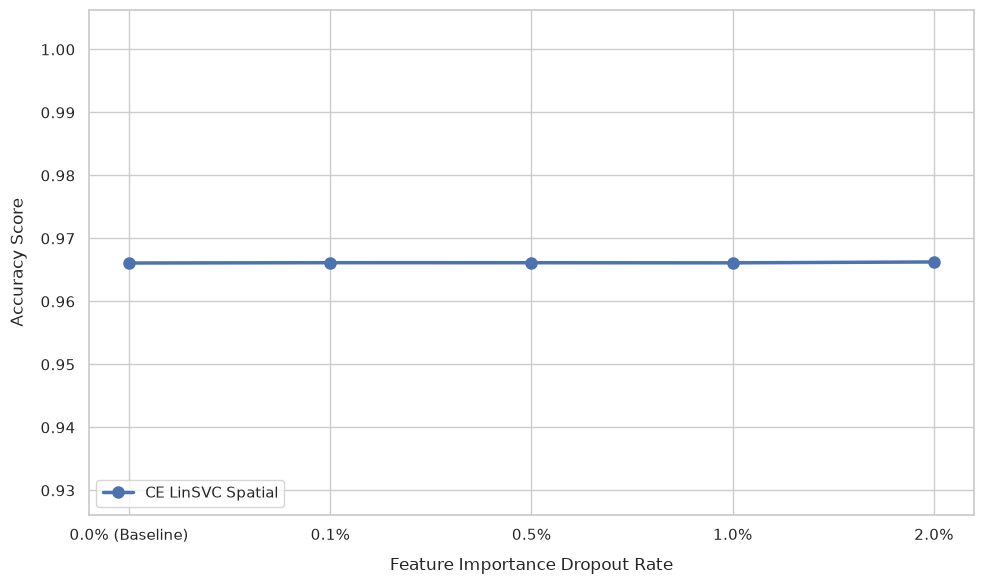

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Theme setzen
sns.set_theme(style="whitegrid")

# --- 1. FUNKTION ZUM AUSLESEN DER DROPOUT-METRIKEN ---
def extract_dropout_accuracies(csv_path, distribution, dropout_rates=['0.1%', '0.5%', '1.0%', '2.0%']):
    """
    Lädt die CSV und berechnet den Mittelwert der Accuracy über die ersten 10 Runs
    für die Baseline (0.0%) sowie für verschiedene Feature Importance Dropout-Raten.
    """
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    df_runs = df.iloc[:10]
    
    accuracies = []
    
    # 1. Baseline (0.0% Dropout) auslesen
    baseline_acc = df_runs[(distribution, 'Baseline', 'Overall', 'Accuracy')].astype(float).mean()
    accuracies.append(baseline_acc)
        
    # 2. Accuracy für die einzelnen Feature Importance Dropout-Raten auslesen
    for rate in dropout_rates:
        col_path = (distribution, 'Dropout', f'FI_{rate}', 'Accuracy')
        acc = df_runs[col_path].astype(float).mean()
        accuracies.append(acc)
        
    return accuracies


# --- 2. MODELL-PFADE DEFINIEREN ---
# Trage hier die Pfade zu deinen CSV-Dateien für die jeweiligen Modelle ein
model_paths = {
    'CE LinSVC Spatial': '../training/results/new2/custom_ensemble_linsvc_spatial_ovary/combined_result.csv',
}

dropout_rates = ['0.0% (Baseline)', '0.1%', '0.5%', '1.0%', '2.0%']
dropout_keys = ['0.1%', '0.5%', '1.0%', '2.0%']


# --- 3. DATEN DYNAMISCH AUS DEN CSVs EXTRAHIEREN ---
data_in = {}

for model_name, csv_path in model_paths.items():
    try:
        data_in[model_name] = extract_dropout_accuracies(csv_path, 'In-Distribution', dropout_keys)
    except FileNotFoundError:
        print(f"Datei nicht gefunden: {csv_path}. Überspringe Modell '{model_name}'.")


# --- 4. PLOTTEN ---
plt.figure(figsize=(10, 6), dpi=100)

for model_name, accuracies in data_in.items():
    line = plt.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)

plt.xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, labelpad=10)

all_values = [val for accs in data_in.values() for val in accs]
plt.ylim(min(all_values) - 0.04, max(all_values) + 0.04)

plt.legend(loc='lower left', fontsize=11, frameon=True)

plt.tight_layout()

plt.savefig('figures/spatial_id_robustness_comparison.png')

plt.show()

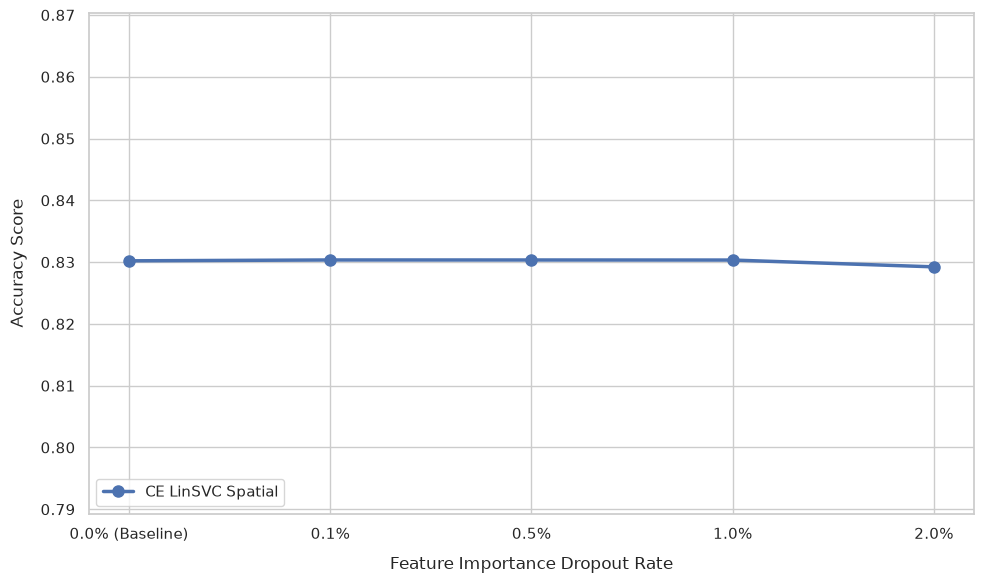

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Theme setzen
sns.set_theme(style="whitegrid")

# --- 1. FUNKTION ZUM AUSLESEN DER DROPOUT-METRIKEN ---
def extract_dropout_accuracies(csv_path, distribution, dropout_rates=['0.1%', '0.5%', '1.0%', '2.0%']):
    """
    Lädt die CSV und berechnet den Mittelwert der Accuracy über die ersten 10 Runs
    für die Baseline (0.0%) sowie für verschiedene Feature Importance Dropout-Raten.
    """
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    df_runs = df.iloc[:10]
    
    accuracies = []
    
    # 1. Baseline (0.0% Dropout) auslesen
    baseline_acc = df_runs[(distribution, 'Classification Report', 'macro avg', 'f1-score')].astype(float).mean()
    accuracies.append(baseline_acc)
        
    # 2. Accuracy für die einzelnen Feature Importance Dropout-Raten auslesen
    for rate in dropout_rates:
        col_path = (distribution, 'Dropout', f'FI_{rate}', 'Macro_F1')
        acc = df_runs[col_path].astype(float).mean()
        accuracies.append(acc)
        
    return accuracies


# --- 2. MODELL-PFADE DEFINIEREN ---
# Trage hier die Pfade zu deinen CSV-Dateien für die jeweiligen Modelle ein
model_paths = {
    'CE LinSVC Spatial': '../training/results/new2/custom_ensemble_linsvc_spatial_ovary/combined_result.csv',
}

dropout_rates = ['0.0% (Baseline)', '0.1%', '0.5%', '1.0%', '2.0%']
dropout_keys = ['0.1%', '0.5%', '1.0%', '2.0%']


# --- 3. DATEN DYNAMISCH AUS DEN CSVs EXTRAHIEREN ---
data_in = {}

for model_name, csv_path in model_paths.items():
    try:
        data_in[model_name] = extract_dropout_accuracies(csv_path, 'In-Distribution', dropout_keys)
    except FileNotFoundError:
        print(f"Datei nicht gefunden: {csv_path}. Überspringe Modell '{model_name}'.")


# --- 4. PLOTTEN ---
plt.figure(figsize=(10, 6), dpi=100)

for model_name, accuracies in data_in.items():
    line = plt.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)

plt.xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, labelpad=10)

all_values = [val for accs in data_in.values() for val in accs]
plt.ylim(min(all_values) - 0.04, max(all_values) + 0.04)

plt.legend(loc='lower left', fontsize=11, frameon=True)

plt.tight_layout()

plt.savefig('figures/spatial_id_macro_f1_robustness_comparison.png')

plt.show()

## Box Plot with Classes

### Spatial Data

In [ ]:
T.cell                 250334
Ovarian.cancer.cell    250281
Monocyte               201217
Fibroblast             161198
Plasma.cell             20944
B.cell                  18673
Endothelial.cell        18483
Dendritic.cell           4814
Mast.cell                1257

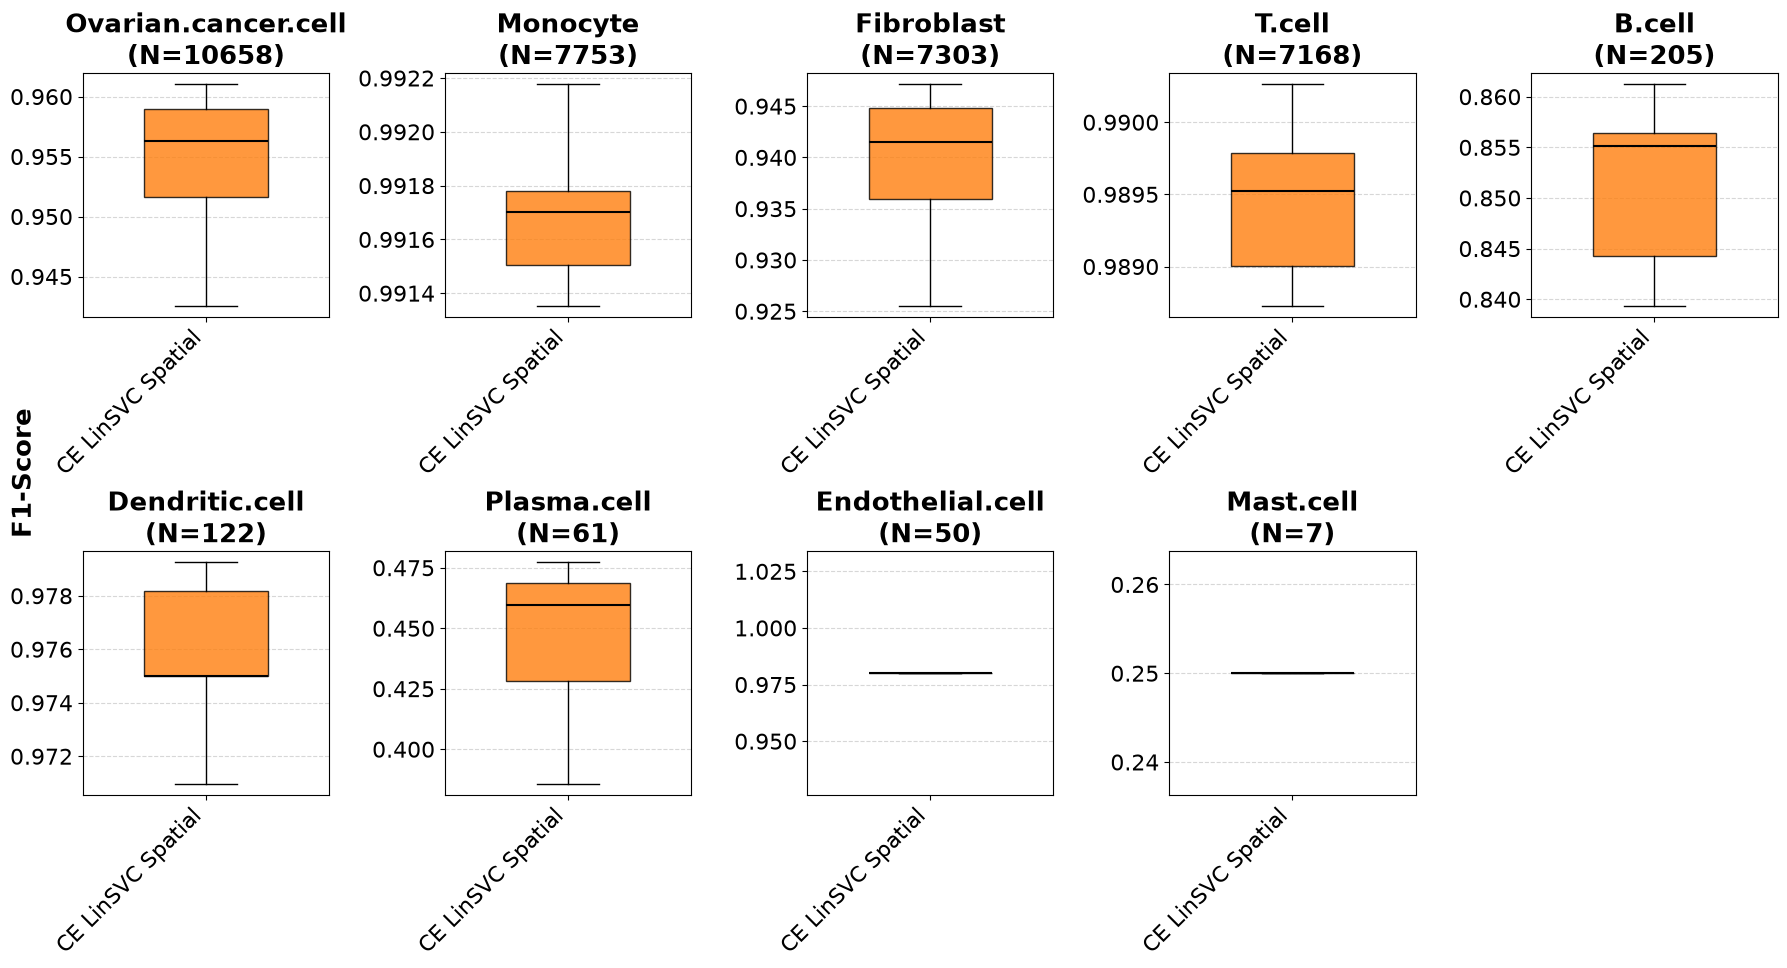

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_runs_from_csv(csv_path, distribution, category, metric, cell_types):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    # CSV mit 4 Header-Zeilen laden
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    
    # Filtere nur die ersten 10 Zeilen (Index 0 bis 9), da dies die Einzelruns sind
    df_runs = df.iloc[:10]
    
    data_for_boxplot = []
    for cell in cell_types:
        # MultiIndex-Pfad zusammensetzen
        col_path = (distribution, category, cell, metric)
        try:
            # Spalte extrahieren, in Float umwandeln und als Liste anfügen
            values = df_runs[col_path].astype(float).tolist()
            data_for_boxplot.append(values)
        except KeyError:
            print(f"Warnung: Pfad {col_path} nicht gefunden. Fülle mit Nullen.")
            data_for_boxplot.append([0.0] * 10)
            
    return data_for_boxplot


# --- 1. DATEN VORBEREITEN ---
ce_linsvc_csv_file = '../training/results/new2/custom_ensemble_linsvc_spatial_ovary/combined_result.csv'

cell_types = ['Ovarian.cancer.cell', 'Monocyte', 'Fibroblast', 'T.cell', 'B.cell', 'Dendritic.cell', 'Plasma.cell', 'Endothelial.cell', 'Mast.cell']
support_test = [10658, 7753, 7303, 7168, 205, 122, 61, 50, 7] # Support in the test split Dataset

# Diese nutzen wir nun als Titel für die einzelnen Subplots
#subplot_titles = [f"{cell}\n(N={sup})" for cell, sup in zip(cell_types, support_train)]
subplot_titles = [f"{cell}\n(N={sup})" for cell, sup in zip(cell_types, support_test)]
#subplot_titles = [f"{cell}" for cell in cell_types]

runs_model1 = extract_runs_from_csv(ce_linsvc_csv_file, 'In-Distribution', 'Classification Report', 'f1-score', cell_types)

# --- 2. BOXPLOT ZEICHNEN (SUBPLOTS) ---
models = ['CE LinSVC Spatial']
colors = ['#ff7f0e']

# Erstelle ein 2x4 Grid mit unabhängigen Y-Achsen (sharey=False)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 10), sharey=False)
axes = axes.flatten()  # Macht aus dem 2D-Array der Axes ein 1D-Array für leichteres Iterieren

for i, cell in enumerate(cell_types):
    ax = axes[i]
    
    # Die Daten der 4 Modelle für genau diesen einen Zelltyp zusammenstellen
    cell_data = [
        runs_model1[i],
    ]
    
    # Boxplot für diesen Zelltyp zeichnen
    bplot = ax.boxplot(cell_data, patch_artist=True, showfliers=False, widths=0.5)
    
    # Farben aus der Liste anwenden
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        
    # Mediane schwarz markieren
    for median in bplot['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Subplot-Design
    ax.set_title(subplot_titles[i], fontsize=19, weight='bold')
    
    # Beschriftung der X-Achse (Modellnamen um 45 Grad gedreht für Platz)
    ax.set_xticks([1])
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=16)

    ax.tick_params(axis='y', labelsize=16)
    
    # Y-Achse intelligent limitieren (Maximal 1.05, Minimum passt sich den Daten an)
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom, min(1.05, top))
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Nicht benötigte (leere) Subplots entfernen
for j in range(len(cell_types), len(axes)):
    fig.delaxes(axes[j])

# Globale Titel und Achsenbeschriftung
#fig.suptitle('OOD Class Performance over 10 Runs', fontsize=18, weight='bold')
fig.text(0.01, 0.5, 'F1-Score', va='center', rotation='vertical', fontsize=19, weight='bold')

# Layout bereinigen
plt.tight_layout()
# Etwas Platz nach oben für den Suptitle lassen
fig.subplots_adjust(top=0.90, left=0.05)

plt.savefig('figures/spatial_cell_types_box_plot_subplots.png')
plt.show()

## Experimental Plots

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model-CSV Mapping
MODEL_FILES = {
    'CE LinSVC': '../training/results/mutlitple_ood_datasets/custom_ensemble_linsvc/combined_result.csv',
    'CE LinSVC scaled': '../training/results/mutlitple_ood_datasets/custom_ensemble_linsvc_scaled/combined_result.csv',
    'AE LinSVC': '../training/results/mutlitple_ood_datasets/autoencoder_linsvc/combined_results.csv',
    'CAE LinSVC': '../training/results/mutlitple_ood_datasets/conditional_autoencoder_linsvc/combined_results.csv',
    'CAE RF': '../training/results/mutlitple_ood_datasets/conditional_autoencoder_rf/combined_results.csv',
    'CellTypist': '../training/results/mutlitple_ood_datasets/celltypist_current_python/combined_results.csv',
    'SingleR': '../training/results/mutlitple_ood_datasets/singler/combined_result.csv',
    'scGPT': '../training/results/mutlitple_ood_datasets/scgpt/combined_results.csv'
}

DISTRIBUTIONS = [
    'In-Distribution', 
    'OOD_HIHA_Pediatric', 
    'OOD_HIHA_Young_Adult', 
    'OOD_HIHA_Older_Adult', 
    'OOD_AIDA'
]

OOD_DISTRIBUTIONS = DISTRIBUTIONS[1:]

def load_mean_runs(csv_path):
    """Lädt die CSV und berechnet den Mittelwert über die ersten 10 Runs."""
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    df_runs = df.iloc[:10].astype(float)
    return df_runs.mean(axis=0)

/tmp/ipykernel_22767/2011237545.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


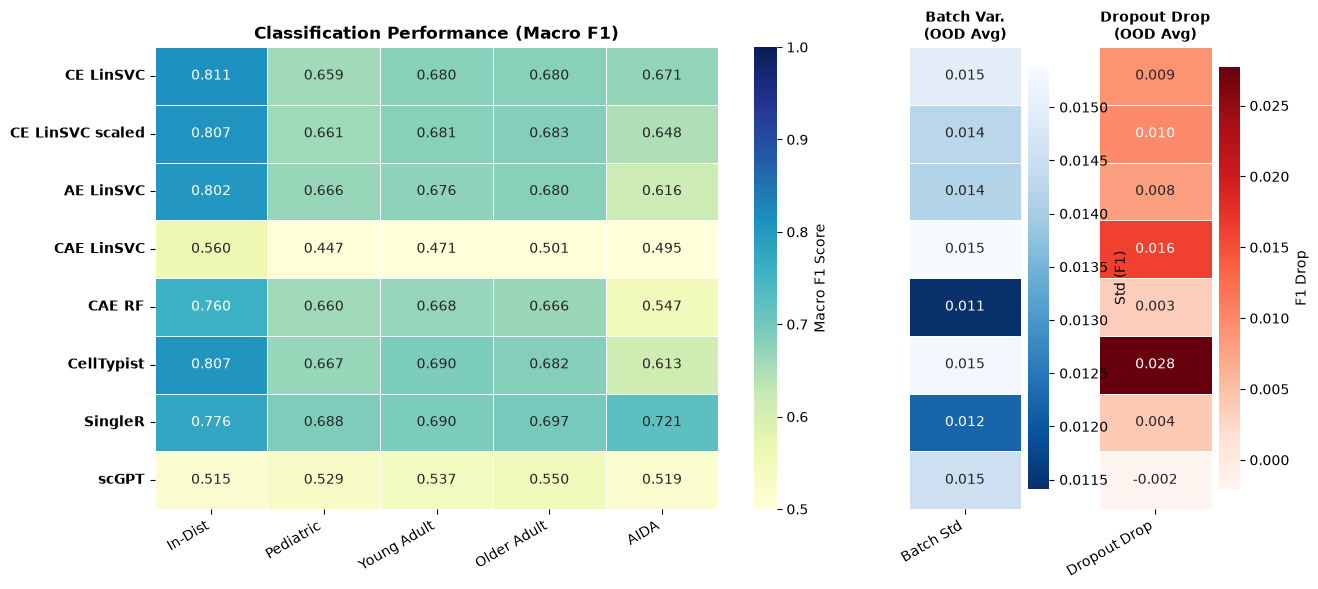

In [4]:
def generate_plot_1_heatmap(model_files, save_path='figures/plot1_performance_heatmap.png'):
    dataset_names = ['In-Dist', 'Pediatric', 'Young Adult', 'Older Adult', 'AIDA']
    
    heatmap_f1 = []
    batch_stds = []
    dropout_drops = []
    model_names = list(model_files.keys())

    for model_name, csv_path in model_files.items():
        means = load_mean_runs(csv_path)
        
        # 1. Macro F1 pro Datensatz
        f1_row = [means[(dist, 'Classification Report', 'macro avg', 'f1-score')] for dist in DISTRIBUTIONS]
        heatmap_f1.append(f1_row)
        
        # 2. Durchschn. Batch-Effekt Standardabweichung über OOD Datensätze
        b_std = np.mean([means[(dist, 'Baseline', 'Batch Effect', 'Macro_F1_Std')] for dist in OOD_DISTRIBUTIONS])
        batch_stds.append([b_std])
        
        # 3. Durchschn. F1-Drop bei Random Dropout (ID F1 - OOD Dropout F1)
        drop_val = np.mean([
            means[(dist, 'Classification Report', 'macro avg', 'f1-score')] - 
            means[(dist, 'Dropout', 'Random', 'Macro_F1')] 
            for dist in OOD_DISTRIBUTIONS
        ])
        dropout_drops.append([drop_val])

    df_f1 = pd.DataFrame(heatmap_f1, index=model_names, columns=dataset_names)
    df_batch = pd.DataFrame(batch_stds, index=model_names, columns=['Batch Std'])
    df_drop = pd.DataFrame(dropout_drops, index=model_names, columns=['Dropout Drop'])

    # Plot Setup mit 3 nebeneinanderliegenden Subplots
    fig, (ax1, ax2, ax3) = plt.subplots(
        1, 3, figsize=(14, 6), 
        gridspec_kw={'width_ratios': [5, 1, 1], 'wspace': 0.15}
    )

    # Main F1 Heatmap
    sns.heatmap(
        df_f1, ax=ax1, cmap='YlGnBu', annot=True, fmt='.3f', 
        cbar_kws={'label': 'Macro F1 Score'}, vmin=0.5, vmax=1.0, linewidths=0.5
    )
    ax1.set_title('Classification Performance (Macro F1)', fontsize=12, fontweight='bold')
    ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontweight='bold')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')

    # Batch Stability Heatmap (Niedriger = Besser)
    sns.heatmap(
        df_batch, ax=ax2, cmap='Blues_r', annot=True, fmt='.3f', 
        cbar_kws={'label': 'Std (F1)'}, yticklabels=False, linewidths=0.5
    )
    ax2.set_title('Batch Var.\n(OOD Avg)', fontsize=10, fontweight='bold')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')

    # Dropout Vulnerability Heatmap (Niedriger = Besser)
    sns.heatmap(
        df_drop, ax=ax3, cmap='Reds', annot=True, fmt='.3f', 
        cbar_kws={'label': 'F1 Drop'}, yticklabels=False, linewidths=0.5
    )
    ax3.set_title('Dropout Drop\n(OOD Avg)', fontsize=10, fontweight='bold')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Aufruf
generate_plot_1_heatmap(MODEL_FILES)

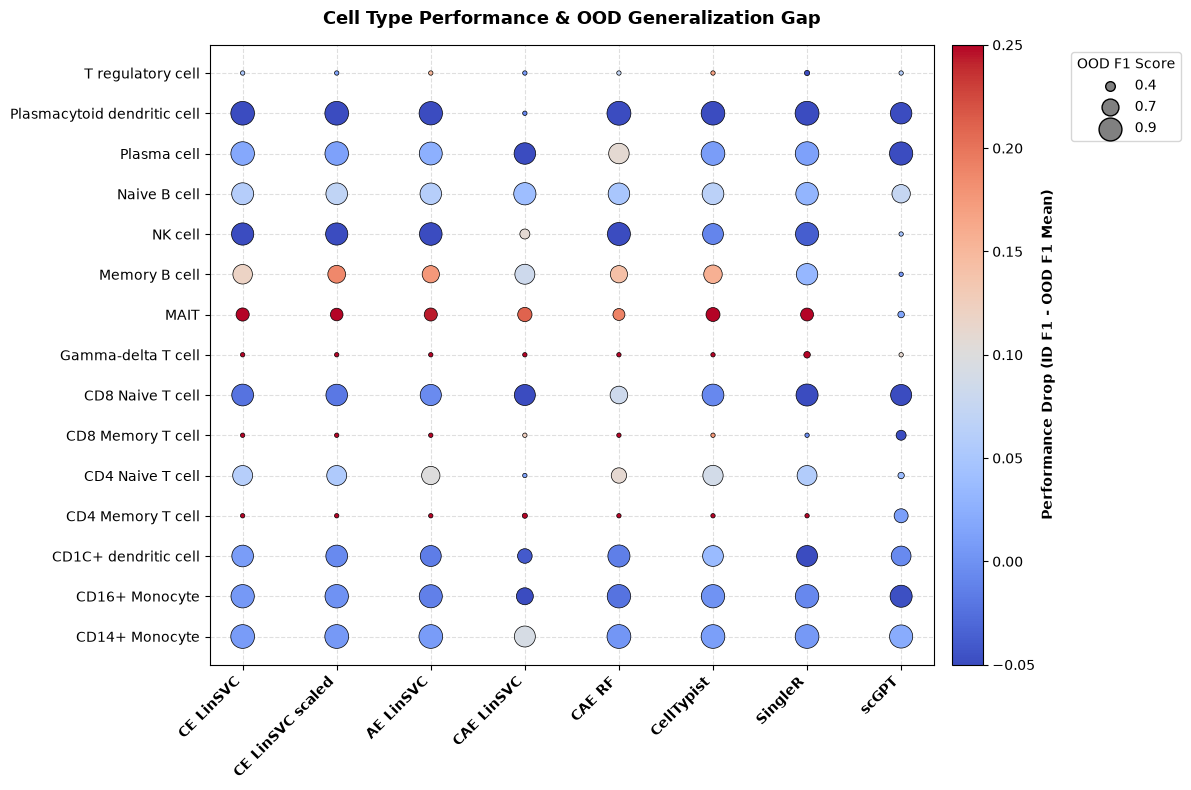

In [5]:
def generate_plot_2_dotplot(model_files, save_path='figures/plot2_celltype_dotplot.png'):
    # Zelltypen dynamisch aus der ersten CSV ermitteln (Ausschluss von Aggregaten)
    first_csv = list(model_files.values())[0]
    df_sample = pd.read_csv(first_csv, header=[0, 1, 2, 3], index_col=0)
    
    exclude_keys = {'macro avg', 'weighted avg', 'accuracy', 'Total_Accuracy'}
    cell_types = [
        col[2] for col in df_sample.columns 
        if col[0] == 'In-Distribution' and col[1] == 'Classification Report' and col[3] == 'f1-score' and col[2] not in exclude_keys
    ]
    cell_types = sorted(list(set(cell_types)))

    models = list(model_files.keys())
    
    x_coords, y_coords, sizes, deltas = [], [], [], []

    for m_idx, (model_name, csv_path) in enumerate(model_files.items()):
        means = load_mean_runs(csv_path)
        
        for c_idx, cell_type in enumerate(cell_types):
            # ID F1
            f1_id = means.get(('In-Distribution', 'Classification Report', cell_type, 'f1-score'), 0.0)
            
            # OOD F1 Mean
            ood_f1s = [
                means.get((dist, 'Classification Report', cell_type, 'f1-score'), 0.0)
                for dist in OOD_DISTRIBUTIONS
            ]
            f1_ood_mean = np.mean(ood_f1s)
            
            # Delta F1 (ID vs OOD)
            delta = f1_id - f1_ood_mean
            
            x_coords.append(m_idx)
            y_coords.append(c_idx)
            sizes.append(max(10, (f1_ood_mean ** 2) * 300))  # Skalierung für visuelle Klarheit
            deltas.append(delta)

    fig, ax = plt.subplots(figsize=(12, 8))

    # Scatter-Plot als Dot-Plot
    scatter = ax.scatter(
        x_coords, y_coords, s=sizes, c=deltas, 
        cmap='coolwarm', vmin=-0.05, vmax=0.25, edgecolors='black', linewidth=0.5
    )

    # Achsen-Design
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10, fontweight='bold')
    ax.set_yticks(range(len(cell_types)))
    ax.set_yticklabels(cell_types, fontsize=10)
    ax.set_title('Cell Type Performance & OOD Generalization Gap', fontsize=13, fontweight='bold', pad=15)
    
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    # Colorbar für Delta F1
    cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
    cbar.set_label('Performance Drop (ID F1 - OOD F1 Mean)', fontsize=10, fontweight='bold')

    # Size-Legende für den F1-Score
    legend_f1_values = [0.4, 0.7, 0.95]
    legend_handles = [
        ax.scatter([], [], s=(val**2)*300, c='gray', edgecolors='black', label=f'{val:.1f}')
        for val in legend_f1_values
    ]
    ax.legend(
        handles=legend_handles, title="OOD F1 Score", 
        loc="upper left", bbox_to_anchor=(1.18, 1.0), frameon=True
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Aufruf
generate_plot_2_dotplot(MODEL_FILES)

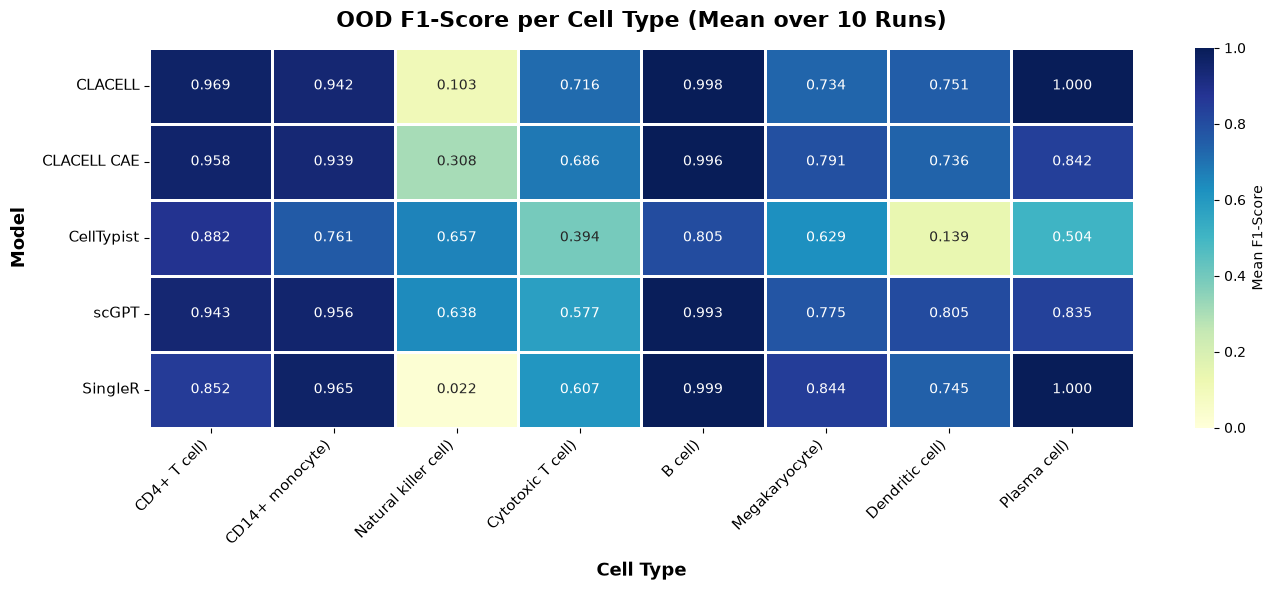

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def extract_runs_from_csv(csv_path, distribution, category, metric, cell_types):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp anhand des MultiIndex-Pfades.
    """
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    df_runs = df.iloc[:10]
    
    data = []
    for cell in cell_types:
        col_path = (distribution, category, cell, metric)
        try:
            values = df_runs[col_path].astype(float).tolist()
            data.append(values)
        except KeyError:
            print(f"Warnung: Pfad {col_path} nicht gefunden. Fülle mit Nullen.")
            data.append([0.0] * 10)
            
    return data


# --- 1. DATEN VORBEREITEN ---
clacell_csv_file = '../training/results/clacell_complete_pipeline/combined_result.csv'
clacell2_csv_file = '../training/results/clacell_conditional_bayes/combined_result.csv'
celltypist_csv_file = '../training/results/celltypist/combined_results.csv'
scGPT_csv_file = '../training/results/scgpt/combined_results.csv'
singler_csv_file = '../training/results/singler/combined_result.csv'

cell_types = ['CD4+ T cell', 'CD14+ monocyte', 'Natural killer cell', 'Cytotoxic T cell', 'B cell', 'Megakaryocyte', 'Dendritic cell', 'Plasma cell']

# Spaltenbeschriftungen mit Support-Anzahl
column_labels = [f"{cell})" for cell in cell_types]
models = ['CLACELL', 'CLACELL CAE', 'CellTypist', 'scGPT', 'SingleR']

# Daten laden (alle auf Out-of-Distribution gesetzt)
runs_model1 = extract_runs_from_csv(clacell_csv_file, 'Out-of-Distribution', 'Classification Report', 'f1-score', cell_types)
runs_model2 = extract_runs_from_csv(clacell2_csv_file, 'Out-of-Distribution', 'Classification Report', 'f1-score', cell_types)
runs_model3 = extract_runs_from_csv(celltypist_csv_file, 'Out-of-Distribution', 'Classification Report', 'f1-score', cell_types)
runs_model4 = extract_runs_from_csv(scGPT_csv_file, 'Out-of-Distribution', 'Classification Report', 'f1-score', cell_types)
runs_model5 = extract_runs_from_csv(singler_csv_file, 'Out-of-Distribution', 'Classification Report', 'f1-score', cell_types)

# --- 2. MATRIX ERSTELLEN (MITTELWERT ÜBER DIE 10 RUNS BERECHNEN) ---
# Berechnet den Mittelwert pro Zelltyp für jedes Modell (Zeile = Modell, Spalte = Zelltyp)
heatmap_matrix = np.array([
    [np.mean(runs) for runs in runs_model1],  # CLACELL
    [np.mean(runs) for runs in runs_model2],  # CLACELL CAE
    [np.mean(runs) for runs in runs_model3],  # CellTypist
    [np.mean(runs) for runs in runs_model4],  # scGPT
    [np.mean(runs) for runs in runs_model5]   # SingleR
])

# DataFrame für Seaborn
df_heatmap = pd.DataFrame(heatmap_matrix, index=models, columns=column_labels)

# --- 3. HEATMAP ZEICHNEN ---
plt.figure(figsize=(14, 6))

# Heatmap mit Werten (annot=True) und Colorbar
ax = sns.heatmap(
    df_heatmap, 
    annot=True, 
    fmt=".3f",           # 3 Nachkommastellen anzeigen
    cmap="YlGnBu",       # Gelb-Grün-Blau Farbschema (ideal für Poster)
    vmin=0.0, 
    vmax=1.0, 
    linewidths=1, 
    linecolor='white',
    cbar_kws={'label': 'Mean F1-Score'}
)

# Design anpassen
plt.title('OOD F1-Score per Cell Type (Mean over 10 Runs)', fontsize=16, weight='bold', pad=15)
plt.xlabel('Cell Type', fontsize=13, weight='bold', labelpad=10)
plt.ylabel('Model', fontsize=13, weight='bold', labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

# Speichern als SVG und PNG für hohe Auflösung
#plt.savefig('reference_cell_types_heatmap_ood.svg', format='svg', bbox_inches='tight')
plt.savefig('figures/poster_reference_cell_types_heatmap_ood.png', dpi=600, bbox_inches='tight')
plt.show()

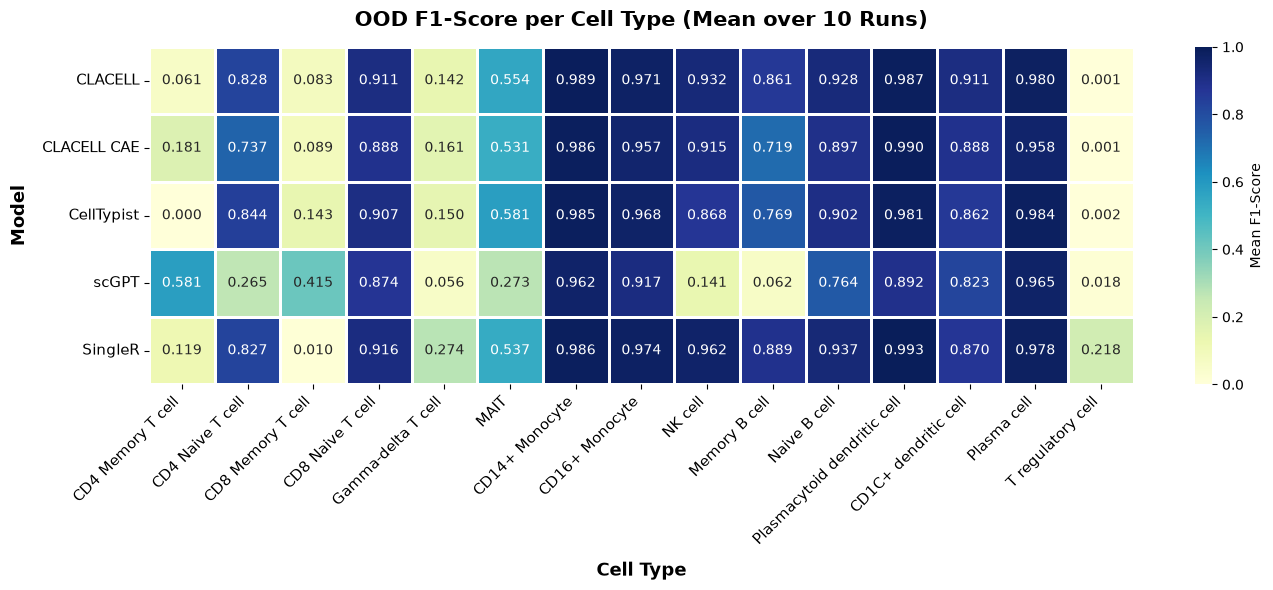

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def extract_runs_from_csv(csv_path, distributions, category, metric, cell_types):
    """
    Lädt die CSV und extrahiert die ersten 10 Zeilen (die 10 Runs) 
    für jeden Zelltyp über alle angegebenen Distributions/OOD-Datensätze.
    """
    df = pd.read_csv(csv_path, header=[0, 1, 2, 3], index_col=0)
    df_runs = df.iloc[:10]
    
    data = []
    for cell in cell_types:
        cell_all_values = []
        for dist in distributions:
            col_path = (dist, category, cell, metric)
            try:
                values = df_runs[col_path].astype(float).tolist()
                cell_all_values.extend(values)
            except KeyError:
                print(f"Warnung: Pfad {col_path} nicht gefunden. Fülle mit Nullen.")
                cell_all_values.extend([0.0] * 10)
        data.append(cell_all_values)
            
    return data


# --- 1. DATEN VORBEREITEN ---
celltypist_csv_file = '../training/results/mutlitple_ood_datasets/celltypist_current_python/combined_results.csv'
scGPT_csv_file = '../training/results/mutlitple_ood_datasets/scgpt/combined_results.csv'
singler_csv_file = '../training/results/mutlitple_ood_datasets/singler/combined_result.csv'

clacell_csv_file = '../training/results/mutlitple_ood_datasets/clacell_complete_pipeline/combined_result.csv'
clacell2_csv_file = '../training/results/mutlitple_ood_datasets/clacell_conditional_bayes_higher_dropout_new_ood/combined_results.csv'


cell_types = ['CD4 Memory T cell', 'CD4 Naive T cell', 'CD8 Memory T cell', 'CD8 Naive T cell', 
              'Gamma-delta T cell', 'MAIT', 'CD14+ Monocyte', 'CD16+ Monocyte', 'NK cell', 
              'Memory B cell', 'Naive B cell', 'Plasmacytoid dendritic cell', 'CD1C+ dendritic cell', 'Plasma cell',
              'T regulatory cell'
             ]

# Liste aller OOD-Datensätze
distributions = [
    'OOD_HIHA_Pediatric', 
    'OOD_HIHA_Young_Adult', 
    'OOD_HIHA_Older_Adult', 
    'OOD_AIDA'
]

column_labels = cell_types
models = ['CLACELL', 'CLACELL CAE', 'CellTypist', 'scGPT', 'SingleR']

# Daten über alle OOD-Datensätze hinweg extrahieren
runs_model1 = extract_runs_from_csv(clacell_csv_file, distributions, 'Classification Report', 'f1-score', cell_types)
runs_model2 = extract_runs_from_csv(clacell2_csv_file, distributions, 'Classification Report', 'f1-score', cell_types)
runs_model3 = extract_runs_from_csv(celltypist_csv_file, distributions, 'Classification Report', 'f1-score', cell_types)
runs_model4 = extract_runs_from_csv(scGPT_csv_file, distributions, 'Classification Report', 'f1-score', cell_types)
runs_model5 = extract_runs_from_csv(singler_csv_file, distributions, 'Classification Report', 'f1-score', cell_types)

# --- 2. MATRIX ERSTELLEN (MITTELWERT ÜBER ALLE OOD-DATENSÄTZE UND RUNS) ---
heatmap_matrix = np.array([
    [np.mean(runs) for runs in runs_model1],  # CLACELL
    [np.mean(runs) for runs in runs_model2],  # CLACELL CAE
    [np.mean(runs) for runs in runs_model3],  # CellTypist
    [np.mean(runs) for runs in runs_model4],  # scGPT
    [np.mean(runs) for runs in runs_model5]   # SingleR
])

# DataFrame für Seaborn
df_heatmap = pd.DataFrame(heatmap_matrix, index=models, columns=column_labels)

# --- 3. HEATMAP ZEICHNEN ---
plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    df_heatmap, 
    annot=True, 
    fmt=".3f",           # 3 Nachkommastellen
    cmap="YlGnBu",       
    vmin=0.0, 
    vmax=1.0, 
    linewidths=1, 
    linecolor='white',
    cbar_kws={'label': 'Mean F1-Score'}
)

# Design anpassen
plt.title('OOD F1-Score per Cell Type (Mean over 10 Runs)', fontsize=15, weight='bold', pad=15)
plt.xlabel('Cell Type', fontsize=13, weight='bold', labelpad=10)
plt.ylabel('Model', fontsize=13, weight='bold', labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

# Speichern
plt.savefig('figures/poster_reference_fine_grained_cell_types_heatmap_ood.png', dpi=600, bbox_inches='tight')
plt.show()